# 07 — Familia F3: modelos ocultos de Markov (HMM)

**Qué detecta.** Un *Hidden Markov Model* supone que el mercado atraviesa una sucesión de
**regímenes latentes** (calma, corrección, crisis…) que no se observan directamente, pero que
dejan huella en la distribución conjunta de las features causales del día. A diferencia del
clustering estático de F2, el régimen de hoy se decide **condicionado al de ayer** mediante una
matriz de transición cuya diagonal premia la persistencia. La salida es doble: una etiqueta de
régimen y una **probabilidad filtrada de crisis** `P(s_t = crisis | y_{1:t})`.

**Supuestos.** (i) cadena de Markov de primer orden, que implica permanencias **geométricas**;
(ii) independencia condicional de las emisiones dado el estado; (iii) parámetros estacionarios
dentro de cada ventana de entrenamiento; (iv) una forma paramétrica para la emisión
(gaussiana o t-Student multivariante).

**Detectores de la familia.**

| id | módulo | papel en el TFM |
|---|---|---|
| D04 | `regimenes.detectores.f3_hmm.hmm_gaussian_2s` | *baseline puente* con la tarea previa: HMM gaussiano de covarianza completa |
| D08 | `regimenes.detectores.f3_hmm.hmm_tstudent` | HMM con emisiones t-Student multivariantes (colas pesadas) y más estados |
| D13 | `regimenes.detectores.f3_hmm.hsmm_tstudent` | **ablación** de D08 con duraciones explícitas (HSMM); fuera de la matriz oficial D01–D12 |

**Cómo usar este notebook.** Por defecto **no ajusta nada del benchmark**: lee los resultados
cacheados en `results/benchmark` (métricas + paneles OOS) verificando su huella. Si la caché no
está vigente, la celda de §3 falla con el comando exacto a ejecutar. Los diagnósticos marcados
como *ilustrativos (NO causales)* ajustan cada modelo una sola vez sobre la muestra completa de
la pista para enseñar su mecánica interna; nunca sustituyen a las cifras OOS. Todas las figuras
se guardan en `results/detectores/f3_hmm/`. **Toda cifra citada sale de una celda.**

**Índice**

1. [Teoría de la familia F3](#s1)
2. [Configuración (desde el registro)](#s2)
3. [Ejecución y carga de resultados](#s3)
4. [Detector a detector](#s4)
   - 4.1–4.2 D04 en las pistas A y B · 4.3 diagnóstico ilustrativo de D04
   - 4.4–4.5 D08 en las pistas A y B · 4.6 diagnóstico ilustrativo de D08
   - 4.7 Ablación D08 → D13 (HSMM): resultado histórico v1, re-ejecución v2 opcional y diagnóstico
5. [Comparación intra-familia](#s5)
6. [Hallazgos de la Capa 1 (v1) y qué se mantiene / cambia en v2](#s6)
   - [6.1 Hipótesis del CHECKPOINT 2 y veredicto (v1 → v2)](#s6-cp2)
7. [Fortalezas, limitaciones y conclusión](#s7)

<a id="s1"></a>
## 1. Teoría de la familia F3

> Fuentes: `docs/teoria/F3_hmm.md` (+ `F3_hmm.bib`), `docs/teoria/00_estado_del_arte.md` (§2–§5),
> `docs/detectores/D04_hmm_gaussian_2s.md`, `docs/detectores/D08_hmm_tstudent.md`,
> `docs/historia/capa1/resultados/ablation_hsmm/README.md` y el markdown de los notebooks v1
> `capa1-final:capa1_exploracion/notebooks/04_hmm_gaussian_2s.ipynb`, `08_hmm_tstudent.ipynb` y
> `A1_hsmm_ablation.ipynb` (conservados en el tag git `capa1-final`; p. ej.
> `git show capa1-final:capa1_exploracion/notebooks/08_hmm_tstudent.ipynb`).

### 1.1 El HMM como modelo de espacio de estados

Se observa una serie `y_1, …, y_T` (aquí, el vector de features causales de cada sesión) generada
por una **cadena de Markov latente** `s_t ∈ {1, …, K}` [hmm_rabiner1989; hmm_zucchini2016]. La
verosimilitud conjunta factoriza como

$$
p(y_{1:T}, s_{1:T}) \;=\; \pi_{s_1}\, b_{s_1}(y_1) \prod_{t=2}^{T} A_{s_{t-1} s_t}\; b_{s_t}(y_t),
$$

con tres bloques de parámetros: probabilidades iniciales `π_k = P(s_1 = k)`, **matriz de
transición** `A_ij = P(s_t = j | s_{t-1} = i)` (homogénea en el tiempo) y **emisiones**
`b_k(y) = p(y | s = k)`.

**Intuición.** Un HMM es el GMM de F2 (D03) al que se le añade memoria: la mezcla de densidades
por estado es la misma idea, pero el peso de cada componente hoy depende del régimen de ayer. La
diagonal alta de `A` es lo que convierte una clasificación día a día —que parpadea— en regímenes
con inercia.

**Supuestos y sus grietas en finanzas.**

- *Markov de primer orden*: la permanencia en cada estado es geométrica y sin memoria; si las
  duraciones reales no lo son, el modelo las sesga (lo relaja el HSMM, §1.4) [hmm_bullabulla2006].
- *Independencia condicional*: dado `s_t`, `y_t` no depende del pasado. El *clustering* de
  volatilidad solo se captura a través de cambios de estado, no dentro del estado.
- *Estacionariedad*: `A` y `b_k` fijos dentro de cada ventana de ajuste; el re-ajuste
  walk-forward la relaja por tramos; los HMM de parámetros variables la relajan de forma
  continua [hmm_nystrup2017; hmm_nystrup2015].
- *Forma de la emisión*: la normal condicional subestima las colas de los retornos diarios, cuya
  curtosis en exceso es muy elevada (ver EDA, `docs/datos/EDA_v2.md`) — motivación de D08.

**Estimación.** Máxima verosimilitud por **Baum-Welch** (un EM) [hmm_baumpetrie1966;
hmm_baumwelch1970]: el paso E calcula las posteriores `γ_t(k)` y `ξ_t(i, j)` con
*forward-backward*; el paso M reestima `π, A, b_k`. El problema es no convexo, así que cada
detector prueba `n_init` semillas consecutivas desde la semilla del registro y conserva la de
mayor log-verosimilitud.

**Relación con F4.** El HMM de emisiones y el Markov-Switching econométrico de Hamilton
[hamilton1989] son el mismo motor de estado latente; F3 enfatiza emisiones multivariantes y F4
la dinámica autorregresiva univariante del retorno [hmm_angtimmermann2012]. Aplicaciones
financieras de referencia: regímenes multivariantes en asignación de activos
[guidolintimmermann2007], correlaciones que suben en el régimen bajista [angbekaert2002],
colas y heterocedasticidad por régimen [hmm_hardy2001] y asignación dinámica basada en
regímenes [hmm_nystrup2018].

### 1.2 Filtrado, suavizado y Viterbi: el corazón causal de la familia

Hay tres maneras de leer el estado de un día `t` con un HMM ya ajustado, y solo una es causal:

- **Filtrado (forward).** Usa únicamente el pasado:

$$
\alpha_t(j) \;=\; P(s_t = j \mid y_{1:t}) \;\propto\; b_j(y_t) \sum_{i=1}^{K} \alpha_{t-1}(i)\, A_{ij}.
$$

- **Suavizado (forward-backward).** `γ_t(j) = P(s_t = j | y_{1:T}) ∝ α_t(j) β_t(j)`, donde
  `β_t(j) = p(y_{t+1:T} | s_t = j)` incorpora **observaciones futuras**: tiene *look-ahead*.
- **Viterbi** [hmm_viterbi1967]. `ŝ_{1:T} = argmax P(s_{1:T} | y_{1:T})`: la secuencia globalmente
  más probable dada **toda** la muestra; también anti-causal.

`hmmlearn` devuelve por defecto el suavizado (`predict_proba`) y Viterbi (`predict`)
[hmm_hmmlearn]. Por eso los tres detectores **sobrescriben** `predict_online` y `predict_proba`
con el filtrado forward (`_hmm_utils.filtered_posterior`, `_hmm_t_utils.filtered_posterior_t` y
el filtro semi-Markov de D13), anteponiendo como *burn-in* las filas del train: la etiqueta y la
probabilidad de `t` usan solo `y_{≤t}`. En walk-forward cada fold reajusta con una ventana
*expanding* y el filtro continúa hacia delante durante `step` sesiones. El Viterbi global queda
confinado a los diagnósticos **in-sample, marcados como NO causales**.

**Etiquetado económico.** Entre re-ajustes los índices de los estados pueden permutarse
(*label switching*). `label_states_economically` reordena los estados por severidad —la
volatilidad del S&P 500 como eje primario— a `0 = calma … K−1 = crisis`, usando solo el train de
cada fold.

> **Hilo conductor heredado de D4 (v1).** Todo gira en torno a *filtrado* frente a *suavizado*.
> La tarea previa vivía en el mundo suavizado; el banco exige el filtrado. La distancia entre
> ambos es, literalmente, la cantidad de acierto que dependía de ver el futuro (§4.3). La v1
> descubrió además que el filtro continuo es **más estable** que decodificar cada bloque con
> Viterbi por separado, porque no rearranca desde `π` en cada costura de bloque.

### 1.3 Emisiones: gaussiana frente a t-Student

**Gaussiana (D04).** `b_k(y) = N(y; μ_k, Σ_k)` con covarianza **completa**: capta
co-movimientos condicionales por régimen, como el cambio de signo de la correlación
acción-bono [gulko2002], a costa de `K·d(d+1)/2` parámetros de covarianza.

**t-Student multivariante (D08).** Por estado, localización `m_k`, matriz de escala `S_k` y
grados de libertad `ν_k`:

$$
b_k(y) = \frac{\Gamma\!\left(\tfrac{\nu_k + d}{2}\right)}{\Gamma\!\left(\tfrac{\nu_k}{2}\right)(\nu_k \pi)^{d/2} |S_k|^{1/2}}
\left(1 + \frac{\delta_k(y)}{\nu_k}\right)^{-\frac{\nu_k + d}{2}},
\qquad \delta_k(y) = (y - m_k)^\top S_k^{-1} (y - m_k).
$$

Se estima con la representación de **mezcla de escala gaussiana**: `y | s = k, u ~ N(m_k, S_k / u)`
con `u ~ Gamma(ν_k/2, ν_k/2)`. En el paso E, cada día recibe el peso

$$
\mathbb{E}[u_t \mid y_t, s_t = k] = \frac{\nu_k + d}{\nu_k + \delta_k(y_t)},
$$

de modo que un día extremo (δ grande) **pesa menos** en la estimación de `m_k, S_k`: el estado
absorbe el salto sin inflar su escala ni robar observaciones a otros estados. `ν_k → ∞` recupera
la gaussiana y la varianza marginal es `S_k · ν_k / (ν_k − 2)`. Bulla (2011) muestra que las
componentes t reproducen mejor los hechos estilizados, son robustas a *outliers* y **aumentan la
persistencia** [hmm_bulla2011].

**Por qué t y no GMM-HMM.** La t añade solo `K` parámetros (un `ν` por estado) sobre el HMM
gaussiano equivalente, así que el BIC es comparable; un GMM-HMM multiplica medias y covarianzas
por el número de componentes y dispara el BIC. D08 se inicializa desde el mejor `GaussianHMM`
de `n_init` semillas y se refina con `t_n_iter` iteraciones de EM-t.

**Estados intermedios.** Con `K > 2` el estado de **crisis** es, por construcción, el último del
orden económico (el de mayor volatilidad del S&P 500 en el train de cada fold); cuánto abarca
fuera de muestra no está fijado por el modelo. En la Capa 1 (v1: features puente, OOS 2012–2026)
resultó ser la cola más extrema y estrecha, con el estrés más amplio en **corrección** (`K−2`), y
por eso la v1 recomendaba leer también *corrección + crisis*. **En v2 ese hallazgo no se
generaliza; depende de la pista** (§4.6 imprime tamaño, retorno y volatilidad OOS de cada estado y
contrasta la lectura v1): en la pista A el estado de crisis OOS de D08 es la cola de mayor
volatilidad, pero también el estado más poblado y con retorno medio positivo, no una cola estrecha;
en la pista B sí es estrecho y de mayor volatilidad, aunque su retorno medio OOS tampoco es el
peor. La columna *corrección + crisis* de §4.4–4.5 se mantiene como lectura complementaria; el
juez ADR-003 puntúa solo el estado de crisis.

### 1.4 Persistencia y duración: del HMM al HSMM (D13)

En un HMM la duración de un episodio del estado `k` es **geométrica**:

$$
P(D_k = d) = A_{kk}^{\,d-1}\,(1 - A_{kk}), \qquad \mathbb{E}[D_k] = \frac{1}{1 - A_{kk}}, \qquad h_k(d) = 1 - A_{kk},
$$

es decir, el *hazard* de salida `h_k(d) = P(D_k = d | D_k ≥ d)` es constante: el régimen «no
recuerda» cuánto lleva activo. Un **HSMM** [hmm_bullabulla2006] sustituye la geometría por una
PMF explícita `p_k(d)` y un hazard dependiente de la edad

$$
h_k(d) = \frac{p_k(d)}{\sum_{u \ge d} p_k(u)},
$$

y la permanencia deja de estar en la diagonal: la **cadena embebida** entre episodios tiene
diagonal nula.

**D13 en este repositorio.** Conserva las emisiones t de D08 y cambia solo la dinámica temporal:
duración **Gamma desplazada** por estado, truncada en `max_duration` (la última celda acumula la
cola) y contraída hacia la geometría del HMM de arranque con un prior de `duration_prior_strength`
episodios equivalentes. La estimación es **en dos etapas** (emisiones y HMM de D08 → duraciones y
saltos a partir de los episodios del train), no un EM conjunto; por eso su BIC es **aproximado**.
En walk-forward se filtra el estado ampliado `P(s_t, a_t | y_{1:t})` (estado y edad del episodio)
y `p_crisis` marginaliza la edad: `P(s_t = crisis | y_{1:t}) = Σ_a P(s_t = crisis, a_t = a | y_{1:t})`.

### 1.5 Selección de K y bondad de ajuste

No existe un test de razón de verosimilitudes estándar válido para `K` (parámetros en la frontera)
[hmm_zucchini2016]; se usan criterios de información

$$
\mathrm{AIC} = -2\log L + 2p, \qquad \mathrm{BIC} = -2\log L + p \log N,
$$

con el mismo convenio de conteo en los tres detectores: D04 `p = K²−1 + K·d + K·d(d+1)/2`; D08
añade `K` grados de libertad; D13 añade otros `K` netos de la duración explícita. En v2 el `K` de
cada detector está **fijado a priori en el registro** (no se elige mirando métricas v2): D04
conserva el puente de la tarea previa y D08 hereda el `K` que el BIC eligió en la v1. La
exploración de `K` por BIC se conserva como celda opcional (`EXPLORAR_K`, §4.6).

### 1.6 Referencias

Claves de `docs/teoria/F3_hmm.bib`: `hmm_rabiner1989`, `hmm_baumpetrie1966`, `hmm_baumwelch1970`,
`hmm_viterbi1967`, `hmm_zucchini2016`, `hmm_bulla2011`, `hmm_bullabulla2006`, `hmm_hardy2001`,
`hmm_nystrup2015`, `hmm_nystrup2017`, `hmm_nystrup2018`, `hmm_nystrup2020`,
`hmm_angtimmermann2012`, `hmm_schreiber2018`, `hmm_hmmlearn`. Claves de `docs/references.bib`:
`hamilton1989`, `guidolintimmermann2007`, `angbekaert2002`, `gulko2002`, `kritzman2012`.
Vecinos: los *jump models* con penalización de saltos [hmm_nystrup2020] están en F2 (D09).

<a id="s2"></a>
## 2. Configuración (desde el registro)

La tabla se genera desde `regimenes.detectores.registry` (la misma fuente que usa el benchmark),
de modo que lo que se lee aquí es exactamente lo que se ejecutó. Para cada pista: features de
entrada (el núcleo multivariante `CORE_A` / `CORE_B`), parámetros del constructor, semilla,
frecuencia de re-ajuste (`step`), tipo de ventana y tamaño del train inicial. D13 se construye
como **copia de D08** que solo cambia la clase y añade los hiperparámetros de duración de la
ablación v1 (`A1_hsmm_ablation.ipynb`), sin retocarlos: así la comparación aísla el efecto de la
duración explícita.

In [1]:
%matplotlib inline
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from regimenes import informes as inf
from regimenes import rutas, viz
from regimenes.benchmark import DEFAULT_TRAIN_DAYS, configure_evaluation
from regimenes.detectores.registry import SEED
from regimenes.evaluacion import ranking as rk
from regimenes.evaluacion.walk_forward import CONTEXT_YEARS
import logging
from dataclasses import replace

from scipy import stats

from regimenes import evaluacion as ev
from regimenes.benchmark import cache as bm_cache
from regimenes.benchmark.ejecucion import run_one

# --- Configuración común a los notebooks de familia 05–11 ---------------------------------
FAMILIA = 'f3_hmm'                  # figuras en results/detectores/<FAMILIA>/
NOMBRE_FAMILIA = 'F3 — Modelos ocultos de Markov (HMM)'
DETECTORES = ['D04', 'D08']
PISTAS = ['A', 'B']
OUTPUT_DIR = rutas.RESULTS_BENCHMARK        # caché del benchmark (aquí solo se lee)
FIG_DIR = inf.carpeta_figuras(FAMILIA)
SPECS = inf.specs_familia(DETECTORES, PISTAS)   # {(pista, id): DetectorSpec} del registro
MIN_RUN = int(rk.DETECTION_DEFAULTS['min_run'])
BETA = float(rk.DETECTION_DEFAULTS['beta'])
rel = inf.ruta_relativa

viz.use_house_style()
inf.opciones_pandas()
warnings.filterwarnings('ignore', category=FutureWarning)


def guardar(fig, nombre):
    """Guarda en results/detectores/<FAMILIA>/<nombre>.png con el estilo de casa (convención 05–11)."""
    return inf.guardar_figura(fig, FIG_DIR, nombre)


# --- Constantes propias de la familia -----------------------------------------------------
ETIQUETAS = inf.ETIQUETAS_ESTADOS   # {K: nombres de los estados canónicos 0..K-1}
logging.getLogger('hmmlearn').setLevel(logging.CRITICAL)
warnings.filterwarnings('ignore')

print(f'Familia {NOMBRE_FAMILIA}: {", ".join(DETECTORES)} | pistas {", ".join(PISTAS)}')
print('Resultados benchmark :', rel(OUTPUT_DIR))
print('Figuras de la familia:', rel(FIG_DIR))

Familia F3 — Modelos ocultos de Markov (HMM): D04, D08 | pistas A, B
Resultados benchmark : results/benchmark
Figuras de la familia: results/detectores/f3_hmm


In [2]:
# Hiperparámetros de la ablación D13: los de A1_hsmm_ablation (v1), sin retocar.
D_MAX = 126                # duración máxima representada; la última celda acumula la cola
DURATION_PRIOR = 12.0      # episodios equivalentes del prior geométrico
TRANSITION_PRIOR = 2.0     # fuerza del prior sobre la cadena de saltos


def spec_de(pista, det_id):
    return SPECS[(pista, det_id)]


def spec_d13(pista):
    """D13 = D08 con duraciones explícitas: mismas features, K, semilla, step y ventana."""
    base = spec_de(pista, 'D08')
    return replace(
        base,
        detector_id='D13',
        label='HSMM t-Student (ablación de D08)',
        module='hsmm_tstudent',
        class_name='HSMMTStudent',
        params={**base.params, 'max_duration': D_MAX,
                'duration_prior_strength': DURATION_PRIOR,
                'transition_prior_strength': TRANSITION_PRIOR},
        variant='ablación F3: fuera de la matriz oficial D01-D12',
    )


CONFIG = inf.tabla_configuracion({**SPECS, **{(p, 'D13'): spec_d13(p) for p in PISTAS}})
CONFIG['matriz_oficial'] = CONFIG.index.get_level_values('id').isin(DETECTORES)
display(CONFIG.T)
print(f'Semilla global del registro: SEED = {SEED}; train inicial por pista (sesiones): {DEFAULT_TRAIN_DAYS}; '
      f'contexto de propagación de estado entre bloques (ADR-003): {CONTEXT_YEARS:g} año(s).')

id                                                                D04                                                                                                   D08  \
pista                                                               A                                                  B                                                  A   
detector                                          HMM gaussiano (K=2)                                HMM gaussiano (K=2)                                HMM t-Student (K=4)   
familia_registro                                                  HMM                                                HMM                                                HMM   
clase                                   hmm_gaussian_2s.HMMGaussian2S                      hmm_gaussian_2s.HMMGaussian2S                           hmm_tstudent.HMMTStudent   
n_features                                                          9                                                 14                                                  9   
features            SP500_ret_z, SP500_vol_z, SP500_momentum, SP50...  SP500_ret_z, SP500_vol_z, SP500_momentum, SP50...  SP500_ret_z, SP500_vol_z, SP500_momentum, SP50...   
params_declarados                                n_states=2, n_init=5                               n_states=2, n_init=5                  n_states=4, n_init=3, t_n_iter=25   
params_por_defecto                                         n_iter=200                                         n_iter=200                                   gauss_n_iter=100   
params_efectivos                                           n_states=2                                         n_states=2                                         n_states=4   
semilla                                                            42                                                 42                                                 42   
step                                                               21                                                 21                                                126   
train_inicial                                     2016 ses. (~8 años)                                 756 ses. (~3 años)                                2016 ses. (~8 años)   
ventana                                                     expanding                                          expanding                                          expanding   
lento                                                           False                                              False                                               True   
variante_v2                                                         —                                                  —                                                  —   
matriz_oficial                                                   True                                               True                                               True   

id                                                                                                                   D13                                                     
pista                                                               B                                                  A                                                  B  
detector                                          HMM t-Student (K=4)                   HSMM t-Student (ablación de D08)                   HSMM t-Student (ablación de D08)  
familia_registro                                                  HMM                                                HMM                                                HMM  
clase                                        hmm_tstudent.HMMTStudent                         hsmm_tstudent.HSMMTStudent                         hsmm_tstudent.HSMMTStudent  
n_features                                                         14                                                  9                                  

Semilla global del registro: SEED = 42; train inicial por pista (sesiones): {'A': 2016, 'B': 756}; contexto de propagación de estado entre bloques (ADR-003): 1 año(s).


<a id="s3"></a>
## 3. Ejecución y carga de resultados

`EJECUTAR = False` (por defecto) **no ajusta nada**: `inf.cargar_resultados_familia` lee la caché
del benchmark con `run_benchmark(cache_only=True)`, que solo acepta una combinación pista/detector si
su huella (código del paquete + datos procesados + especificación + entorno) coincide con la
registrada y el panel OOS existe. Si alguna combinación no está vigente, la celda se detiene con el
comando exacto a lanzar desde la raíz del repositorio (`python -m regimenes.benchmark --track A B
--detector …`). `EJECUTAR = True` pasa el gate previo y reajusta los detectores de esta familia en las
dos pistas con `run_job` (mismo camino que la CLI por detector: escribe `metrics/`, `panels/` y
`status/` de esas combinaciones y no toca `manifest.json` ni `run_status.csv`).

El puesto en el **ranking de detección ADR-003** se lee del `ranking*.csv` que genera
`12_comparativa.ipynb`, comprobando que sus columnas `det_*` coinciden con las métricas verificadas
(si el benchmark se re-ejecutó y 12 no, la celda pide regenerarlo). La segunda celda carga los datos
de apoyo (paneles procesados de cada pista, rejilla común, precio del S&P 500 y ventanas del juez),
que no dependen de `results/`.

In [3]:
EJECUTAR = False   # True = reajusta los detectores de la familia con el protocolo del benchmark (ver 'lento' en §2)
FORZAR = False     # True = ignora la caché vigente al reajustar (solo con EJECUTAR = True)
COMANDO = inf.comando_benchmark(PISTAS, DETECTORES)

if EJECUTAR:
    estados_run = inf.ejecutar_familia(DETECTORES, PISTAS, output_dir=OUTPUT_DIR, forzar=FORZAR)
    display(estados_run[['pista', 'id', 'estado', 'segundos', 'detalle']])
    print('Consolida después manifest.json/run_status.csv con:\n'
          '    python -m regimenes.benchmark --consolidate --track A B')

# Solo lectura de la caché verificada por huella + paneles OOS + ranking ADR-003.
# Si alguna combinación no está vigente, falla con el comando exacto (COMANDO).
RES = inf.cargar_resultados_familia(DETECTORES, PISTAS, output_dir=OUTPUT_DIR)
display(RES.estado_cache[['pista', 'id', 'estado', 'detalle']])
METRICAS = RES.metricas        # métricas verificadas, índice (pista, id)
PANELES = RES.paneles          # {(pista, id): panel OOS con state, p_crisis, fold}
RANKING = RES.ranking          # ranking de detección ADR-003 completo (todas las familias)
RANK = RES.rank                # el mismo ranking indexado por (pista, id)
N_PISTA = RES.n_por_pista      # detectores por pista en el ranking
print(f'Métricas verificadas: {len(METRICAS)} combinaciones pista/detector.')
print(f'Ranking: {rel(RES.ruta_ranking)} (coherente con la caché) · detectores por pista: {N_PISTA}')
print('Parámetros del criterio ADR-003:', rk.DETECTION_DEFAULTS)

,pista,id,estado,detalle
0,A,D04,cache,caché verificada: results\benchmark\metrics\A_...
1,A,D08,cache,caché verificada: results\benchmark\metrics\A_...
2,B,D04,cache,caché verificada: results\benchmark\metrics\B_...
3,B,D08,cache,caché verificada: results\benchmark\metrics\B_...


Métricas verificadas: 4 combinaciones pista/detector.
Ranking: results/benchmark/ranking_v2.csv (coherente con la caché) · detectores por pista: {'A': 12, 'B': 12}
Parámetros del criterio ADR-003: {'min_run': 3, 'beta': 1.0, 'lift_min': 1.0, 'min_mean_duration': 5.0, 'min_crisis_run': 3.0, 'score_decimals': 3}


In [4]:
CTX = inf.cargar_contexto_pistas(PISTAS)   # data/processed + S&P 500 crudo (no depende de results/)
DATOS, INDICE, SP500 = CTX.datos, CTX.indice, CTX.sp500
CRISIS, TRAMPAS = CTX.crisis, CTX.trampas  # ventanas [pico, suelo] del juez por pista y trampas

for t in PISTAS:
    indices = [PANELES[(t, d)].index for d in DETECTORES]
    if not all(ix.equals(indices[0]) for ix in indices):
        raise RuntimeError(f'Pista {t}: los paneles OOS de la familia no comparten índice (gate de 12).')
    oos = indices[0]
    evaluables = [c for c, (a, b) in CRISIS[t].items() if pd.Timestamp(b) >= oos[0]]
    print(f'Pista {t}: OOS {oos[0].date()} -> {oos[-1].date()} ({len(oos)} sesiones); '
          f'{len(evaluables)} de {len(CRISIS[t])} crisis del catálogo con suelo dentro del OOS.')
print('Ventanas trampa (no-crisis):', ', '.join(f'{k} {a}->{b}' for k, (a, b) in TRAMPAS.items()))


def fila(pista, det_id):
    """Fila de métricas verificadas (CSV del benchmark) de una combinación."""
    return METRICAS.loc[(pista, det_id)]


def fila_ranking(pista, det_id):
    """Fila del ranking de detección ADR-003 de una combinación."""
    return RANKING.set_index(['pista', 'id'], drop=False).loc[(pista, det_id)]


leer_panel = inf.leer_panel   # paneles propios de la ablación D13 (§4.7.2)

Pista A: OOS 1970-05-12 -> 2026-05-29 (14133 sesiones); 17 de 18 crisis del catálogo con suelo dentro del OOS.
Pista B: OOS 2010-04-12 -> 2026-05-29 (4059 sesiones); 9 de 10 crisis del catálogo con suelo dentro del OOS.
Ventanas trampa (no-crisis): taper_2013 2013-05-01->2013-09-13, debtceiling_2013 2013-09-26->2013-10-16


<a id="s4"></a>
## 4. Detector a detector

Para cada detector y pista se muestra, siempre sobre las etiquetas **OOS causales** del
benchmark:

1. el S&P 500 coloreado por estado canónico (0 = calma … K−1 = crisis) con **franjas** para las
   crisis del juez de esa pista `[pico, suelo]` (azul) y las trampas de falso positivo (gris), y la
   probabilidad filtrada de crisis;
2. la **cobertura por crisis** (fracción de días de la ventana marcados como crisis, con su IC
   bootstrap por bloques), si el evento se **detecta** según ADR-003 y el *lead/lag*; para `K > 2`
   se añade *corrección + crisis*;
3. la activación en las **trampas** (bajo = bueno);
4. las métricas de detección y el **puesto en el ranking ADR-003** de la pista.

Las utilidades siguientes encapsulan ese recorrido para no repetir código por detector (las figuras
y tablas comunes a los notebooks 05–11 viven en `regimenes.informes`).

In [5]:
def franjas_eventos(ax, pista):
    """Franjas: crisis del juez de la pista [pico, suelo] (azul) y trampas (gris)."""
    inf.franjas_eventos(ax, CRISIS[pista], TRAMPAS, etiquetas=False)


def tabla_cobertura(pista, m, panel):
    """Cobertura por crisis (CSV) + corrección+crisis (panel) + detección y lead/lag."""
    configure_evaluation(pista)
    K = int(m['n_states'])
    estados = panel['state'].astype(int)
    tabla = inf.tabla_cobertura(m, CRISIS[pista])
    amplio = ev.crisis_coverage((estados >= K - 2).astype(int), 1) if K > 2 else {}
    tabla['corr+crisis'] = pd.Series(amplio, dtype=float).reindex(tabla.index)
    # Control: la cobertura recomputada desde el panel OOS debe coincidir con la del CSV.
    recomputada = pd.Series(ev.crisis_coverage(estados, K - 1)).reindex(tabla.index)
    diferencia = (recomputada - tabla['cobertura']).abs().max()
    if diferencia > 1e-9:
        raise RuntimeError(f'Cobertura del panel distinta de la del CSV (máx {diferencia}).')
    return tabla


def tabla_trampas(pista, m, panel):
    configure_evaluation(pista)
    K = int(m['n_states'])
    estados = panel['state'].astype(int)
    amplio = ev.false_alarm_in_windows((estados >= K - 2).astype(int), 1) if K > 2 else {}
    return pd.DataFrame({
        'activación crisis': inf.tabla_trampas(m, TRAMPAS),
        'corr+crisis': pd.Series(amplio, dtype=float).reindex(list(TRAMPAS)),
    })


def severidad_oos(pista, m, panel):
    """Retorno y volatilidad anualizados del S&P 500 por estado canónico OOS (causal)."""
    K = int(m['n_states'])
    estados = panel['state'].astype(int)
    ret = DATOS[pista]['SP500_ret'].reindex(estados.index)
    filas = []
    for s in range(K):
        r = ret[estados == s]
        filas.append({'estado': s, 'etiqueta': ETIQUETAS[K][s], 'n_dias': int(len(r)),
                      'ret_anual': float(r.mean() * 252), 'vol_anual': float(r.std() * np.sqrt(252))})
    tabla = pd.DataFrame(filas).set_index('estado')
    vols = tabla['vol_anual'].to_numpy()
    monotona = bool(np.all(np.diff(vols[np.isfinite(vols)]) > 0))
    return tabla, monotona


def ficha(det_id, pista, m=None, panel=None, r=None):
    """Recorrido completo de una combinación detector x pista (figuras + tablas + ranking)."""
    configure_evaluation(pista)
    m = fila(pista, det_id) if m is None else m
    panel = PANELES[(pista, det_id)] if panel is None else panel
    if r is None and det_id in DETECTORES:
        r = fila_ranking(pista, det_id)
    K = int(m['n_states'])

    fig, _ = inf.figura_estados_oos(
        SP500, panel, K, crisis=CRISIS[pista], trampas=TRAMPAS, todos_los_estados=True,
        etiquetas=ETIQUETAS[K], figsize=(15, 8),
        titulo=f'{det_id} · pista {pista} — estados OOS causales ({m["ventana_eval"]})',
        titulo_diagnostico=f'{det_id} · pista {pista} — P(crisis) filtrada (causal, OOS)')
    guardar(fig, f'{det_id}_{pista}_estados_oos')
    plt.show()

    cob = tabla_cobertura(pista, m, panel)
    display(cob.round(3))
    trampas = tabla_trampas(pista, m, panel)
    fig, _ = inf.figura_cobertura(
        cob, trampas['activación crisis'], min_run=MIN_RUN,
        extra=cob['corr+crisis'] if K > 2 else None, etiqueta_extra='corrección + crisis' if K > 2 else '',
        titulo=f'{det_id} · pista {pista} — cobertura OOS por crisis (rojo = detectada, ≥{MIN_RUN} sesiones '
               'seguidas; ◆ = corrección + crisis; gris = trampas)')
    guardar(fig, f'{det_id}_{pista}_cobertura_crisis')
    plt.show()
    display(trampas.round(3))

    n_det, n_ev = int(m['det_n_detectados']), int(m['det_n_eventos'])
    if r is not None:
        n_pista = int((RANKING['pista'] == pista).sum())
        print(f'{det_id} · pista {pista}: puesto de detección ADR-003 = {int(r["puesto_deteccion"])}/{n_pista} '
              f'({r["nivel_etiqueta"]}) | score F1 = {r["score_deteccion"]:.3f}')
    print(f'  eventos detectados = {n_det}/{n_ev} (recall {m["det_event_recall"]:.2f}) | precisión = '
          f'{m["det_precision"]:.3f}, lift {m["det_lift_precision"]:.2f}x sobre la tasa base {m["det_base_rate"]:.3f}')
    print(f'  días marcados = {m["det_marked_rate"]:.1%} | falsa alarma = {m["false_alarm_rate"]:.3f} | '
          f'switching = {m["switching_rate"]:.4f} | duración media = {m["mean_regime_duration"]:.1f} d | '
          f'estabilidad de etiqueta = {m["label_stability"]:.3f} | coste = {m["elapsed_seconds"] / 60:.1f} min')
    return cob


COBERTURAS = {}

### 4.1 D04 `hmm_gaussian_2s` — pista A

HMM gaussiano de covarianza completa y dos estados sobre el núcleo `CORE_A`, re-ajustado cada
`step` sesiones con ventana *expanding* y leído con filtrado forward. Es el **baseline puente**:
reproduce el modelo de la tarea previa, ahora sin *look-ahead*. En la pista A la historia larga
permite evaluar OOS muchas crisis anteriores a 2007, que la v1 no podía ver.

figura -> results/detectores/f3_hmm/D04_A_estados_oos.png


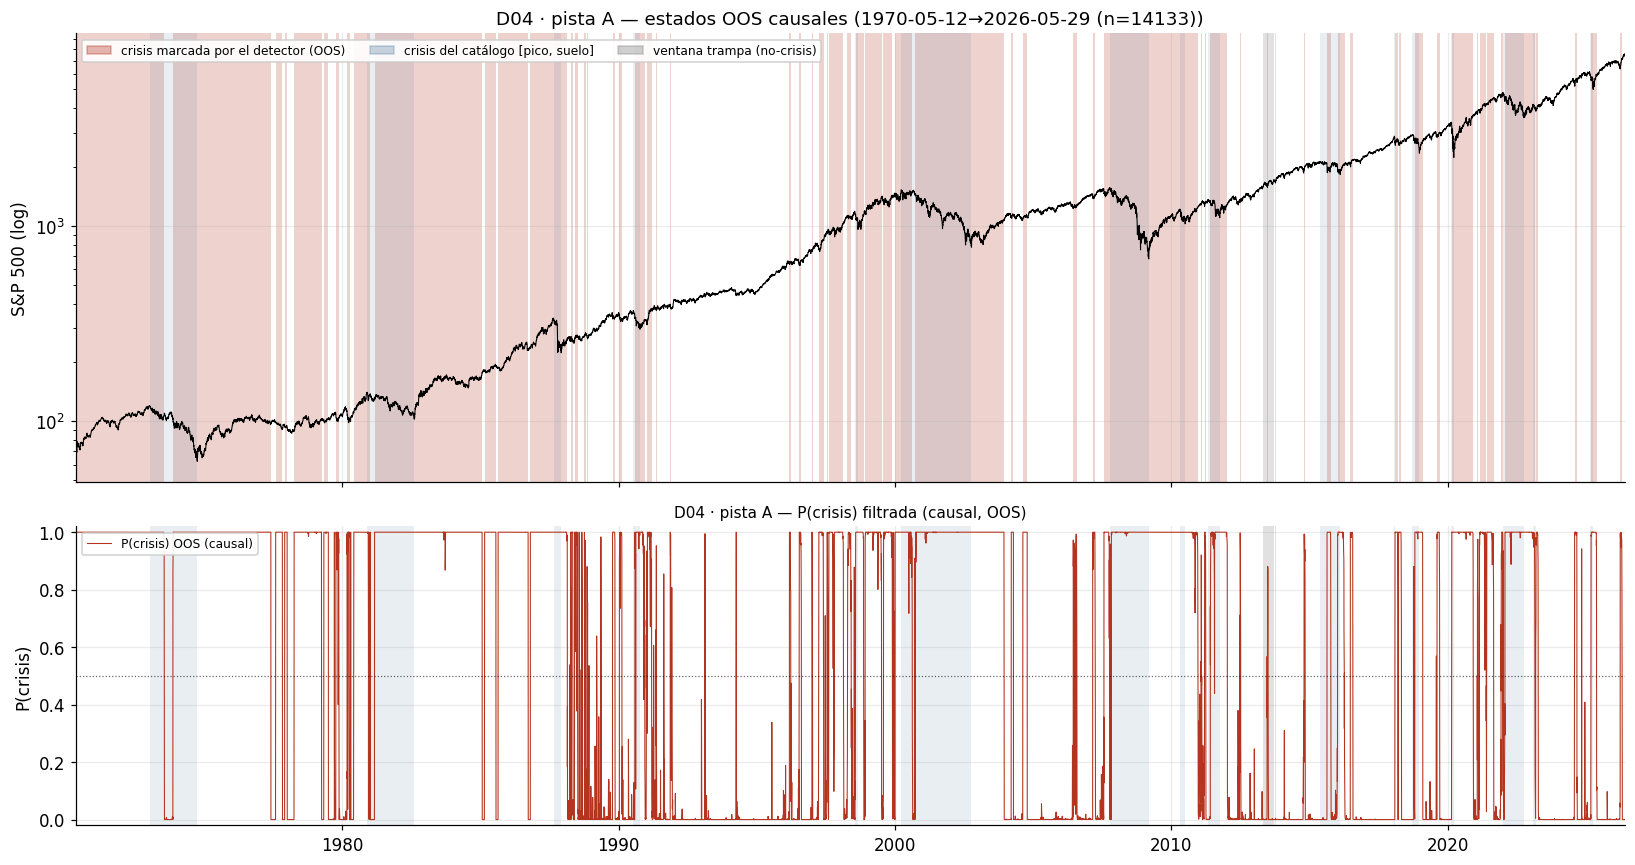

,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias,corr+crisis
crisis,,,,,,,,
bear_1969_70,1968-11-29,1970-05-26,1.000,1.000,1.000,1.0,-10.0,NaN
oil_stagflation_1973,1973-01-11,1974-10-03,0.815,0.730,0.895,1.0,-221.0,NaN
volcker_1980_82,1980-11-28,1982-08-12,0.898,0.829,0.951,1.0,-252.0,NaN
black_monday_1987,1987-08-25,1987-12-04,1.000,1.000,1.000,1.0,-252.0,NaN
gulf_war_sl_1990,1990-07-16,1990-10-11,0.746,0.524,0.952,1.0,-251.0,NaN
ltcm_russia_1998,1998-07-17,1998-08-31,0.719,0.406,1.000,1.0,-252.0,NaN
dotcom_2000_02,2000-03-24,2002-10-09,0.961,0.926,0.991,1.0,-252.0,NaN
gfc_2007_09,2007-10-09,2009-03-09,0.955,0.907,0.997,1.0,-252.0,NaN
flash_crash_euro1_2010,2010-04-23,2010-07-02,1.000,1.000,1.000,1.0,-252.0,NaN


figura -> results/detectores/f3_hmm/D04_A_cobertura_crisis.png


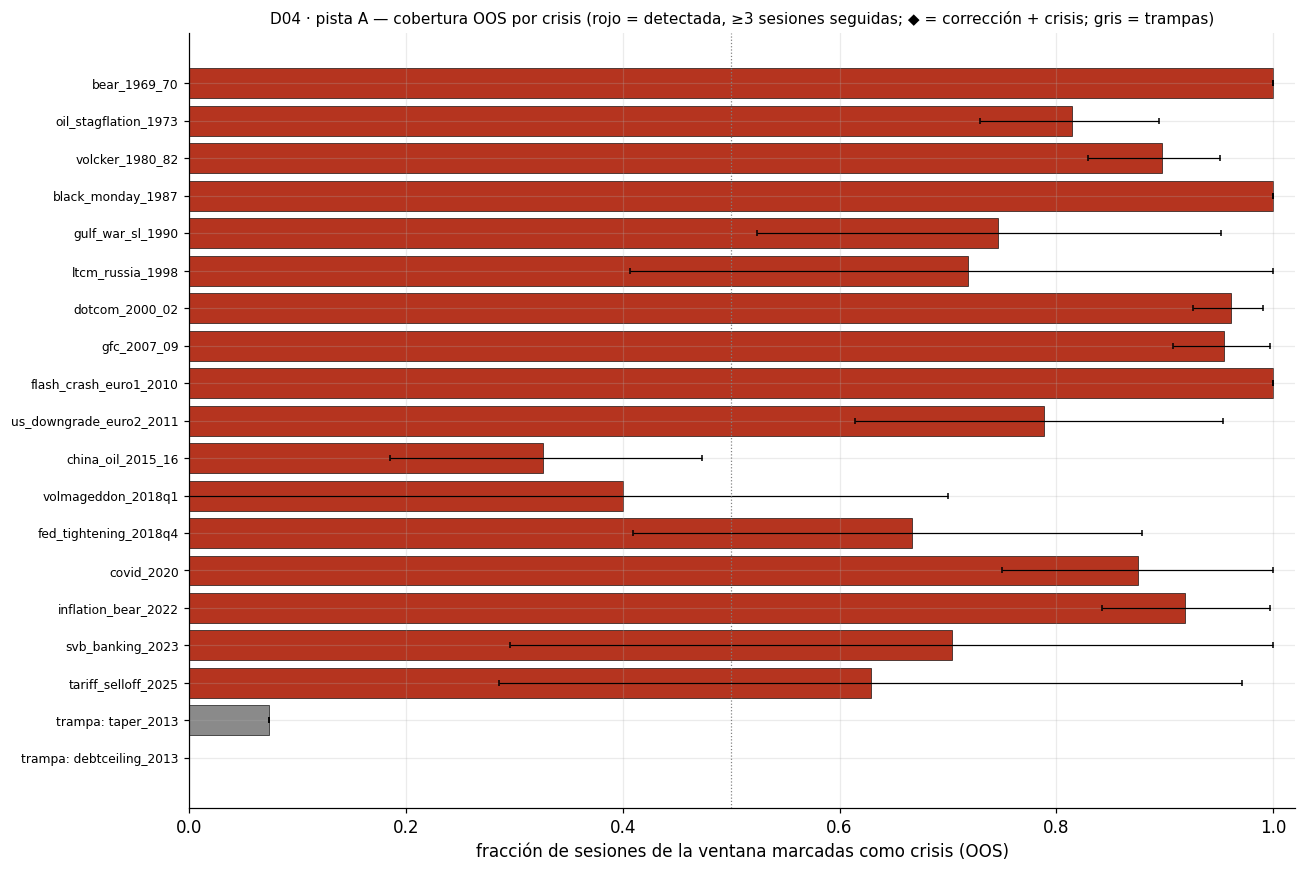

,activación crisis,corr+crisis
taper_2013,0.074,NaN
debtceiling_2013,0.000,NaN


D04 · pista A: puesto de detección ADR-003 = 10/12 (elegible) | score F1 = 0.455
  eventos detectados = 17/17 (recall 1.00) | precisión = 0.294, lift 1.52x sobre la tasa base 0.194
  días marcados = 56.1% | falsa alarma = 0.706 | switching = 0.0162 | duración media = 61.4 d | estabilidad de etiqueta = 0.979 | coste = 109.4 min


In [6]:
COBERTURAS[('A', 'D04')] = ficha('D04', 'A')

### 4.2 D04 `hmm_gaussian_2s` — pista B

Mismo detector sobre `CORE_B` (incluye VIX, MOVE, crédito BAA-10Y, tipos reales y correlación
acción-bono) y un train inicial más corto; la GFC queda en el train y su cobertura sale `NaN`
(no se premia ni se penaliza lo que no es OOS).

figura -> results/detectores/f3_hmm/D04_B_estados_oos.png


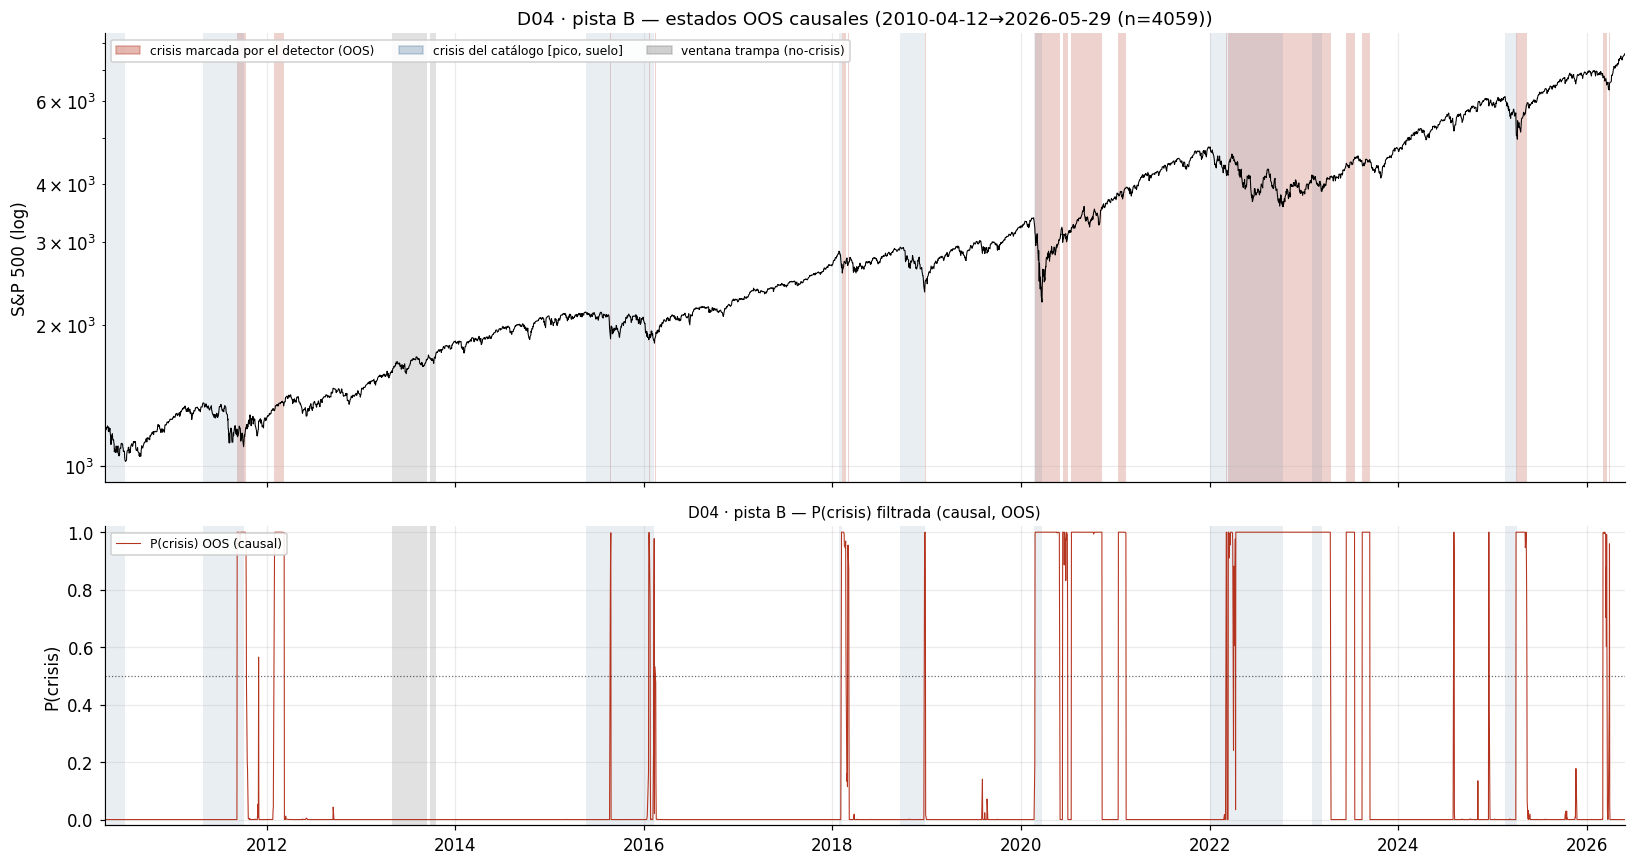

,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias,corr+crisis
crisis,,,,,,,,
flash_crash_euro1_2010,2010-04-23,2010-07-02,0.000,0.000,0.000,0.0,NaN,NaN
us_downgrade_euro2_2011,2011-04-29,2011-10-03,0.165,0.023,0.308,1.0,-17.0,NaN
china_oil_2015_16,2015-05-21,2016-02-11,0.049,0.005,0.098,1.0,-118.0,NaN
volmageddon_2018q1,2018-01-26,2018-02-08,0.400,0.000,0.800,1.0,-3.0,NaN
fed_tightening_2018q4,2018-09-20,2018-12-24,0.015,0.000,0.015,0.0,-223.0,NaN
covid_2020,2020-02-19,2020-03-23,0.833,0.667,1.000,1.0,-19.0,NaN
inflation_bear_2022,2022-01-03,2022-10-12,0.755,0.628,0.885,1.0,-152.0,NaN
svb_banking_2023,2023-02-02,2023-03-13,1.000,1.000,1.000,1.0,-249.0,NaN
tariff_selloff_2025,2025-02-19,2025-04-08,0.114,0.000,0.229,1.0,-3.0,NaN


figura -> results/detectores/f3_hmm/D04_B_cobertura_crisis.png


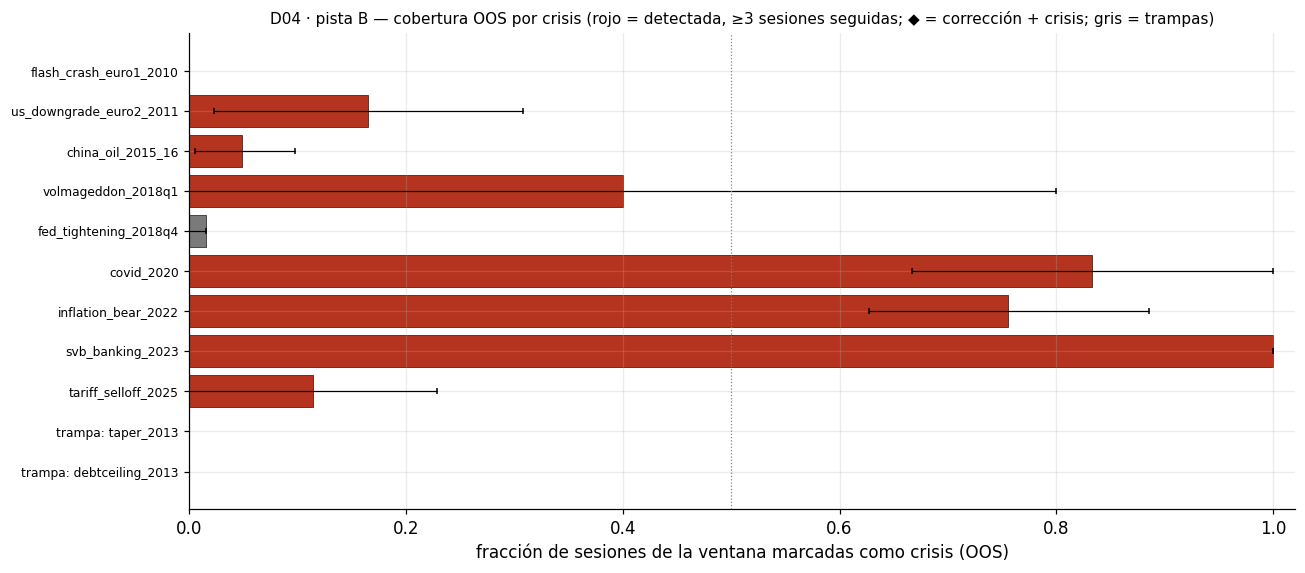

,activación crisis,corr+crisis
taper_2013,0.0,NaN
debtceiling_2013,0.0,NaN


D04 · pista B: puesto de detección ADR-003 = 5/12 (elegible) | score F1 = 0.497
  eventos detectados = 7/9 (recall 0.78) | precisión = 0.366, lift 2.12x sobre la tasa base 0.173
  días marcados = 15.6% | falsa alarma = 0.634 | switching = 0.0123 | duración media = 79.6 d | estabilidad de etiqueta = 0.966 | coste = 13.0 min


In [7]:
COBERTURAS[('B', 'D04')] = ficha('D04', 'B')

### 4.3 D04 — diagnóstico ilustrativo (NO causal): filtrado vs suavizado e in-sample vs causal

Rescata el **experimento central de la v1** (`04_hmm_gaussian_2s.ipynb` §2, §4, §7–§9) sobre los
datos v2. Se ajusta D04 **una sola vez sobre toda la muestra de cada pista** (misma
configuración del registro) y se comparan:

- **In-sample (Viterbi global, con look-ahead)** frente a las etiquetas **causales OOS** del
  benchmark, ventana a ventana. La diferencia `delta = causal − in-sample` mide cuánto del acierto
  histórico dependía de ver el futuro; `NaN` en la columna causal significa que la crisis cayó en
  el train inicial.
- **Suavizado (forward-backward)** frente a **filtrado forward** con los **mismos parámetros**: la
  brecha entre curvas es, en estado puro, el *look-ahead* intra-bloque al que renuncia el banco.
- Emisiones por estado (violines de volatilidad y retorno z del S&P 500), matriz de transición
  con la duración esperada `1/(1 − A_ii)` y el histograma de duraciones de los episodios **OOS**
  (colas cortas = *flickering*).

Todo lo de esta sección es **ilustrativo**: no entra en ninguna métrica ni en el ranking.

In [8]:
DIAGNOSTICO_ILUSTRATIVO = True   # ajusta cada modelo UNA vez sobre toda la muestra (NO causal)


def ajuste_muestra_completa(spec, pista):
    """Ajuste ilustrativo sobre la rejilla completa de la pista (con look-ahead)."""
    X = DATOS[pista].loc[INDICE[pista], list(spec.features)]
    ret = DATOS[pista]['SP500_ret'].reindex(X.index)
    det = spec.factory()
    det.fit(X)
    det.label_states_economically(X, market_returns=ret)
    return det, X, ret


DIAG = {}
if DIAGNOSTICO_ILUSTRATIVO:
    for pista in PISTAS:
        det, X, ret = ajuste_muestra_completa(spec_de(pista, 'D04'), pista)
        cs = det.crisis_state
        cols = det._used_features
        DIAG[('D04', pista)] = dict(
            det=det, X=X, ret=ret,
            est_is=pd.Series(det.predict(X), index=X.index),                    # Viterbi global
            p_filt=pd.Series(det.predict_proba(X)[:, cs], index=X.index),       # filtrado forward
            p_suav=pd.Series(det._model.predict_proba(X[cols].to_numpy())[:, det._canonical_order[cs]],
                             index=X.index),                                     # forward-backward
        )
        print(f'D04 · pista {pista}: ajuste ilustrativo con {len(X)} sesiones | logL = {det.score(X):,.1f} '
              f'| parámetros = {det.n_parameters()}')
else:
    print('Diagnóstico ilustrativo desactivado (DIAGNOSTICO_ILUSTRATIVO = False).')

D04 · pista A: ajuste ilustrativo con 16149 sesiones | logL = -46,023.1 | parámetros = 111


D04 · pista B: ajuste ilustrativo con 4815 sesiones | logL = -19,107.5 | parámetros = 241


figura -> results/detectores/f3_hmm/D04_A_insample_vs_causal_tabla.png


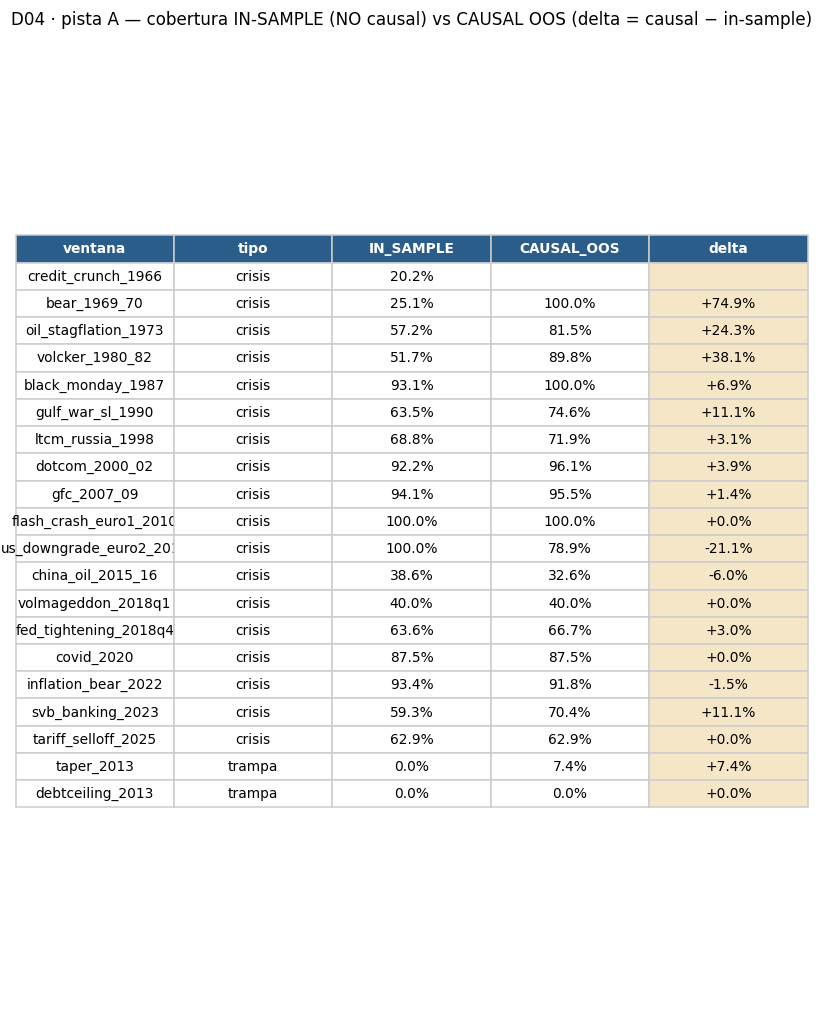

Pista A: crisis evaluables en ambas versiones = 17; delta medio = +0.088; delta mínimo = -0.211 (us_downgrade_euro2_2011)
  switching in-sample = 0.0078 vs causal = 0.0162 | duración media in-sample = 127.2 d vs causal = 61.4 d


figura -> results/detectores/f3_hmm/D04_B_insample_vs_causal_tabla.png


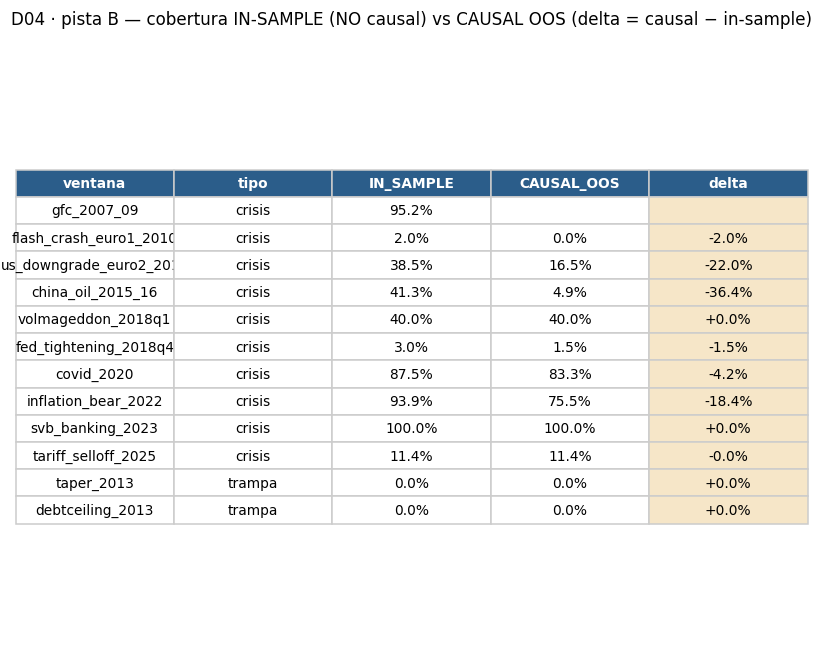

Pista B: crisis evaluables en ambas versiones = 9; delta medio = -0.094; delta mínimo = -0.364 (china_oil_2015_16)
  switching in-sample = 0.0058 vs causal = 0.0123 | duración media in-sample = 166.0 d vs causal = 79.6 d


In [9]:
# In-sample (Viterbi global, NO causal) frente a causal OOS, ventana a ventana.
PUENTE_D04 = {}   # resumen por pista para el veredicto de §6.1
for pista in PISTAS:
    if ('D04', pista) not in DIAG:
        continue
    configure_evaluation(pista)
    d, m = DIAG[('D04', pista)], fila(pista, 'D04')
    cs = d['det'].crisis_state
    cov_is = ev.crisis_coverage(d['est_is'], cs)
    fa_is = ev.false_alarm_in_windows(d['est_is'], cs)
    filas = [{'ventana': k, 'tipo': 'crisis', 'IN_SAMPLE': cov_is[k], 'CAUSAL_OOS': m.get(f'cov_{k}', np.nan)}
             for k in ev.CRISIS_WINDOWS]
    filas += [{'ventana': k, 'tipo': 'trampa', 'IN_SAMPLE': fa_is[k], 'CAUSAL_OOS': m.get(f'fa_{k}', np.nan)}
              for k in ev.FALSE_POSITIVE_WINDOWS]
    cmp_is = pd.DataFrame(filas).set_index('ventana')
    cmp_is[['IN_SAMPLE', 'CAUSAL_OOS']] = cmp_is[['IN_SAMPLE', 'CAUSAL_OOS']].apply(pd.to_numeric, errors='coerce')
    cmp_is['delta'] = cmp_is['CAUSAL_OOS'] - cmp_is['IN_SAMPLE']
    fig = viz.render_table_figure(
        cmp_is, title=f'D04 · pista {pista} — cobertura IN-SAMPLE (NO causal) vs CAUSAL OOS (delta = causal − in-sample)',
        highlight_cols=['delta'], fmt={'IN_SAMPLE': '{:.1%}', 'CAUSAL_OOS': '{:.1%}', 'delta': '{:+.1%}'})
    guardar(fig, f'D04_{pista}_insample_vs_causal_tabla')
    plt.show()
    crisis_ambas = cmp_is[(cmp_is['tipo'] == 'crisis') & cmp_is['delta'].notna()]
    PUENTE_D04[pista] = {'crisis': crisis_ambas, 'sw_is': ev.switching_rate(d['est_is']),
                         'sw_causal': float(m['switching_rate'])}
    print(f'Pista {pista}: crisis evaluables en ambas versiones = {len(crisis_ambas)}; '
          f'delta medio = {crisis_ambas["delta"].mean():+.3f}; delta mínimo = {crisis_ambas["delta"].min():+.3f} '
          f'({crisis_ambas["delta"].idxmin() if len(crisis_ambas) else "-"})')
    print(f'  switching in-sample = {ev.switching_rate(d["est_is"]):.4f} vs causal = {m["switching_rate"]:.4f} | '
          f'duración media in-sample = {ev.mean_regime_duration(d["est_is"]):.1f} d vs causal = '
          f'{m["mean_regime_duration"]:.1f} d')

figura -> results/detectores/f3_hmm/D04_A_filtrado_vs_suavizado.png


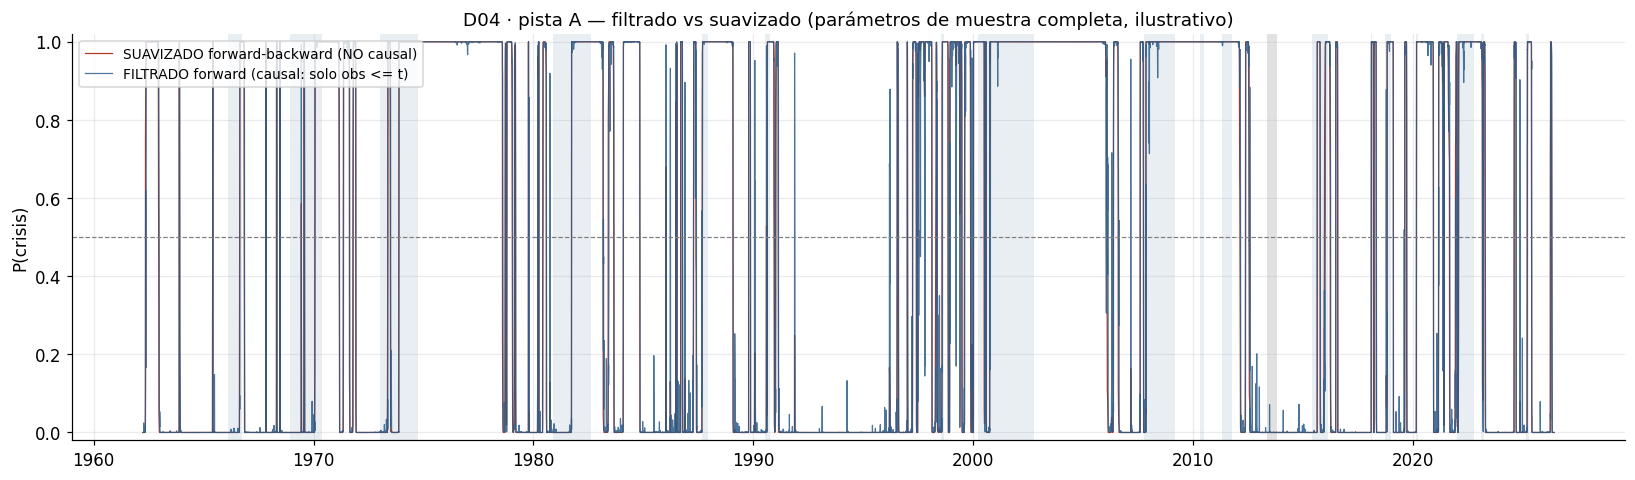

Pista A: |suavizado − filtrado| media = 0.022 | p95 = 0.075 | máx = 0.841


figura -> results/detectores/f3_hmm/D04_B_filtrado_vs_suavizado.png


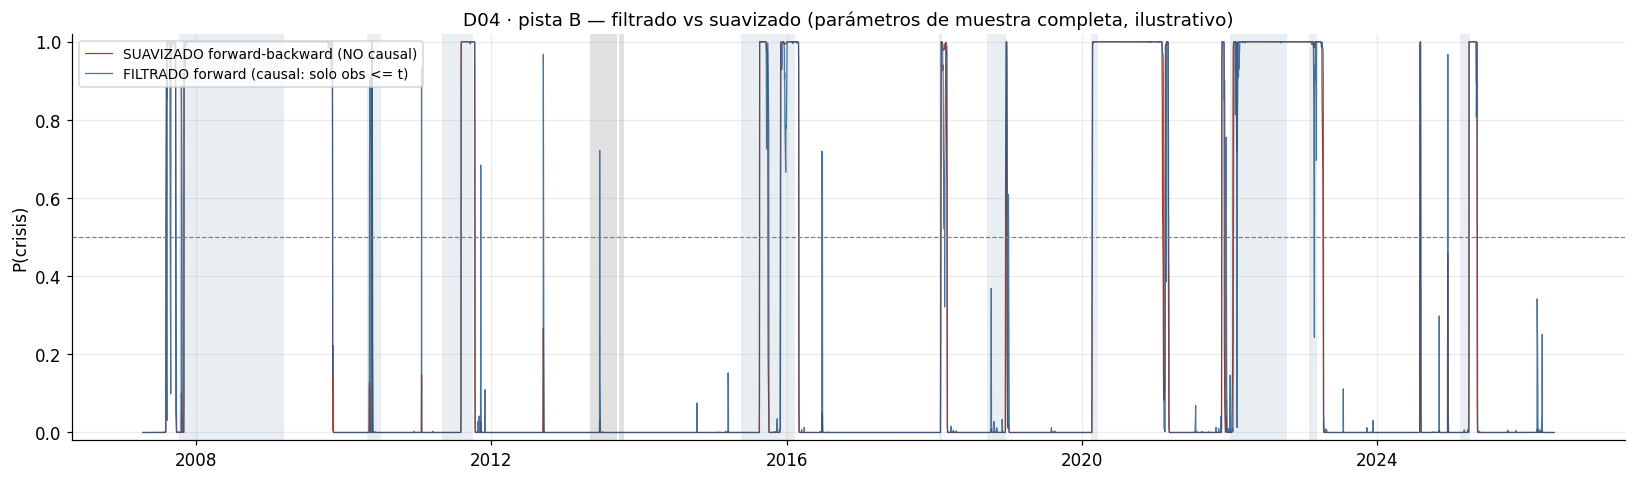

Pista B: |suavizado − filtrado| media = 0.011 | p95 = 0.006 | máx = 0.861


In [10]:
# Filtrado vs suavizado con los MISMOS parámetros: la brecha es el look-ahead intra-bloque.
for pista in PISTAS:
    if ('D04', pista) not in DIAG:
        continue
    configure_evaluation(pista)
    d = DIAG[('D04', pista)]
    fig, ax = plt.subplots(figsize=(15, 4.5))
    ax.plot(d['p_suav'].index, d['p_suav'], color=viz.C_CRISIS, lw=0.8,
            label='SUAVIZADO forward-backward (NO causal)')
    ax.plot(d['p_filt'].index, d['p_filt'], color=viz.C_LONG, lw=0.8, alpha=0.85,
            label='FILTRADO forward (causal: solo obs <= t)')
    ax.axhline(0.5, color='grey', ls='--', lw=0.8)
    franjas_eventos(ax, pista)
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel('P(crisis)')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_title(f'D04 · pista {pista} — filtrado vs suavizado (parámetros de muestra completa, ilustrativo)')
    fig.tight_layout()
    guardar(fig, f'D04_{pista}_filtrado_vs_suavizado')
    plt.show()
    brecha = (d['p_suav'] - d['p_filt']).abs()
    print(f'Pista {pista}: |suavizado − filtrado| media = {brecha.mean():.3f} | p95 = {brecha.quantile(0.95):.3f} '
          f'| máx = {brecha.max():.3f}')

figura -> results/detectores/f3_hmm/D04_A_emisiones_transicion.png


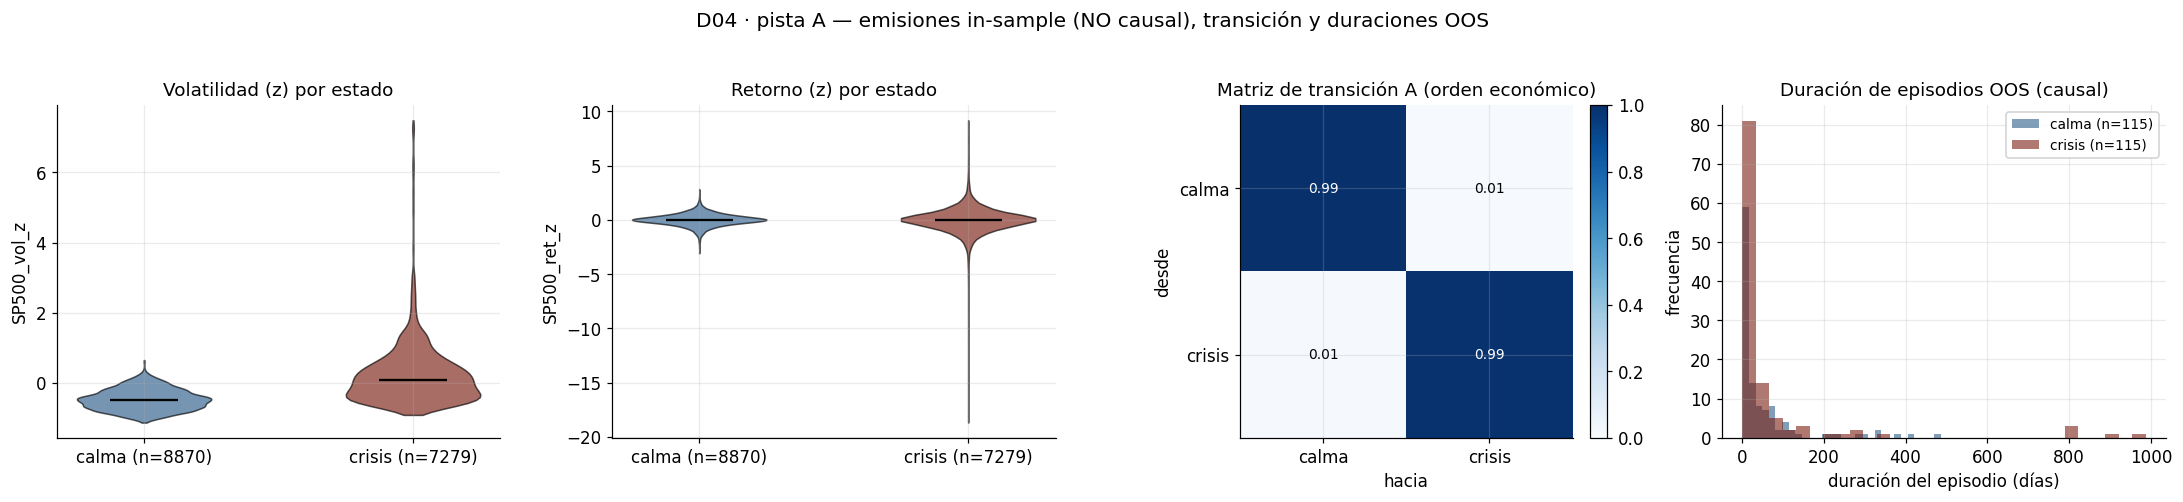

Pista A: duración esperada 1/(1−A_ii) = {'calma': 135.2, 'crisis': 111.2} días


figura -> results/detectores/f3_hmm/D04_B_emisiones_transicion.png


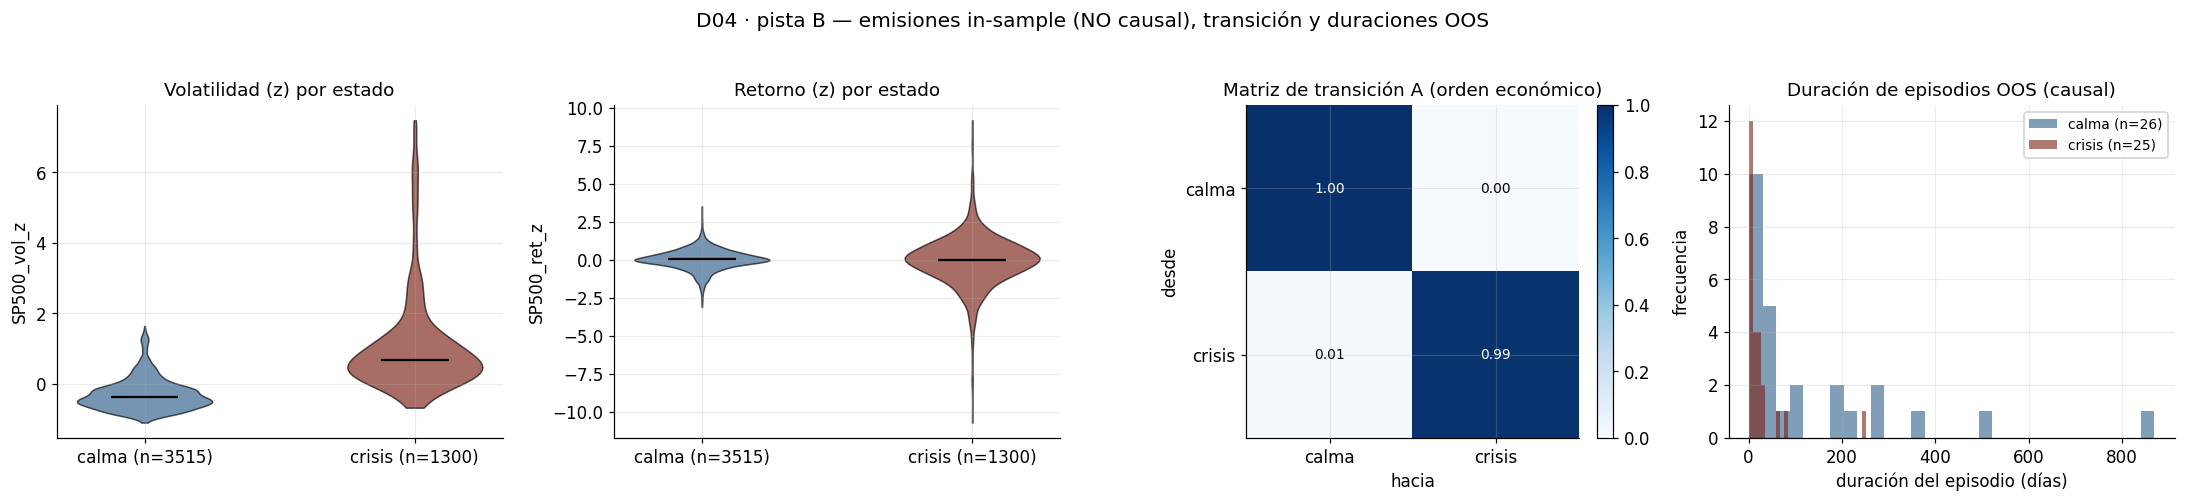

Pista B: duración esperada 1/(1−A_ii) = {'calma': 224.2, 'crisis': 83.1} días


In [11]:
# Emisiones por estado (in-sample), matriz de transición y duraciones OOS.
for pista in PISTAS:
    if ('D04', pista) not in DIAG:
        continue
    d = DIAG[('D04', pista)]
    det, X, cs = d['det'], d['X'], d['det'].crisis_state
    order = det._canonical_order
    A = det._model.transmat_[np.ix_(order, order)]
    etiquetas = {i: e for i, e in enumerate(ETIQUETAS[det.n_states])}
    fig, axes = plt.subplots(1, 4, figsize=(20, 4.4))
    viz.plot_distribution_by_regime(X['SP500_vol_z'], d['est_is'], crisis_state=cs, labels=etiquetas,
                                    kind='violin', ax=axes[0], xlabel='SP500_vol_z', title='Volatilidad (z) por estado')
    viz.plot_distribution_by_regime(X['SP500_ret_z'], d['est_is'], crisis_state=cs, labels=etiquetas,
                                    kind='violin', ax=axes[1], xlabel='SP500_ret_z', title='Retorno (z) por estado')
    viz.plot_transition_matrix(A, labels=ETIQUETAS[det.n_states], ax=axes[2],
                               title='Matriz de transición A (orden económico)')
    viz.plot_duration_histogram(PANELES[(pista, 'D04')]['state'].astype(int), n_states=det.n_states,
                                ax=axes[3], title='Duración de episodios OOS (causal)')
    fig.suptitle(f'D04 · pista {pista} — emisiones in-sample (NO causal), transición y duraciones OOS', y=1.03)
    fig.tight_layout()
    guardar(fig, f'D04_{pista}_emisiones_transicion')
    plt.show()
    dur = {ETIQUETAS[det.n_states][i]: float(1.0 / (1.0 - A[i, i])) for i in range(det.n_states)}
    print(f'Pista {pista}: duración esperada 1/(1−A_ii) =', {k: round(v, 1) for k, v in dur.items()}, 'días')

### 4.4 D08 `hmm_tstudent` — pista A

HMM con emisiones t-Student multivariantes y más estados (el número está en §2), re-ajustado
cada `step` sesiones (el EM-t es caro) y leído con el filtrado forward t. Recuérdese la lectura
multi-estado de §1.3: la columna `cobertura` mide solo el estado de crisis (el último del orden
económico), que es el que usa el juez ADR-003; la barra *corrección + crisis* es una lectura
complementaria heredada de la v1. Que el estado de crisis sea una cola estrecha o un estado amplio
depende de la pista (§4.6).

figura -> results/detectores/f3_hmm/D08_A_estados_oos.png


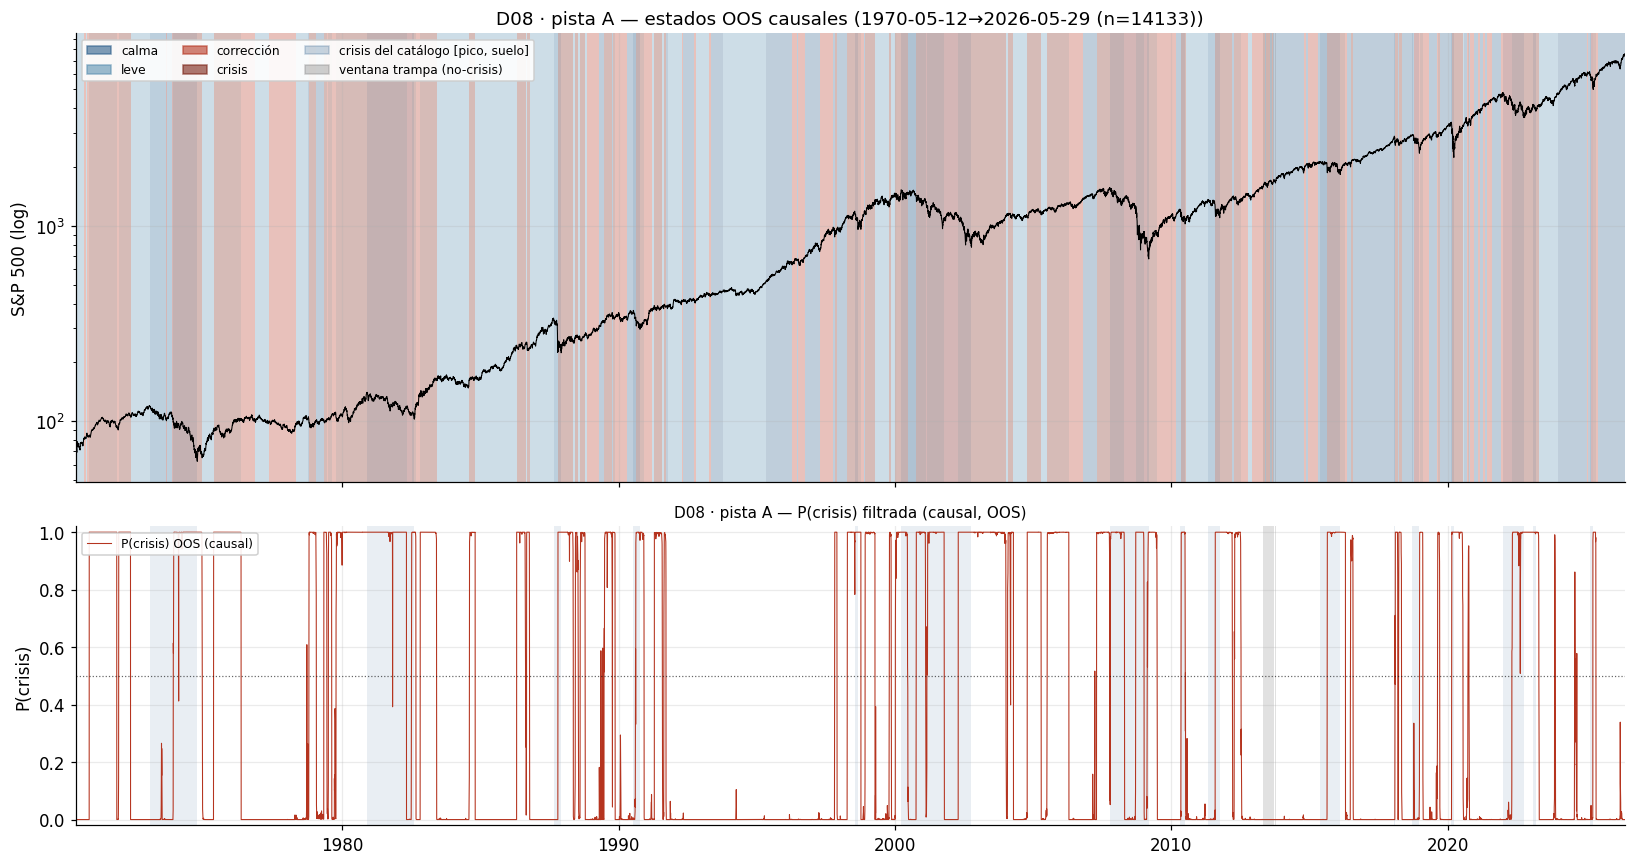

,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias,corr+crisis
crisis,,,,,,,,
bear_1969_70,1968-11-29,1970-05-26,0.000,0.000,0.000,0.0,NaN,0.000
oil_stagflation_1973,1973-01-11,1974-10-03,0.499,0.389,0.610,1.0,-218.0,0.545
volcker_1980_82,1980-11-28,1982-08-12,0.893,0.821,0.956,1.0,-252.0,0.998
black_monday_1987,1987-08-25,1987-12-04,0.431,0.167,0.674,1.0,-30.0,0.472
gulf_war_sl_1990,1990-07-16,1990-10-11,0.651,0.413,0.921,1.0,-251.0,0.651
ltcm_russia_1998,1998-07-17,1998-08-31,1.000,1.000,1.000,1.0,-212.0,1.000
dotcom_2000_02,2000-03-24,2002-10-09,0.665,0.579,0.737,1.0,-252.0,0.868
gfc_2007_09,2007-10-09,2009-03-09,0.615,0.499,0.730,1.0,-252.0,0.983
flash_crash_euro1_2010,2010-04-23,2010-07-02,0.780,0.540,1.000,1.0,-38.0,0.780


figura -> results/detectores/f3_hmm/D08_A_cobertura_crisis.png


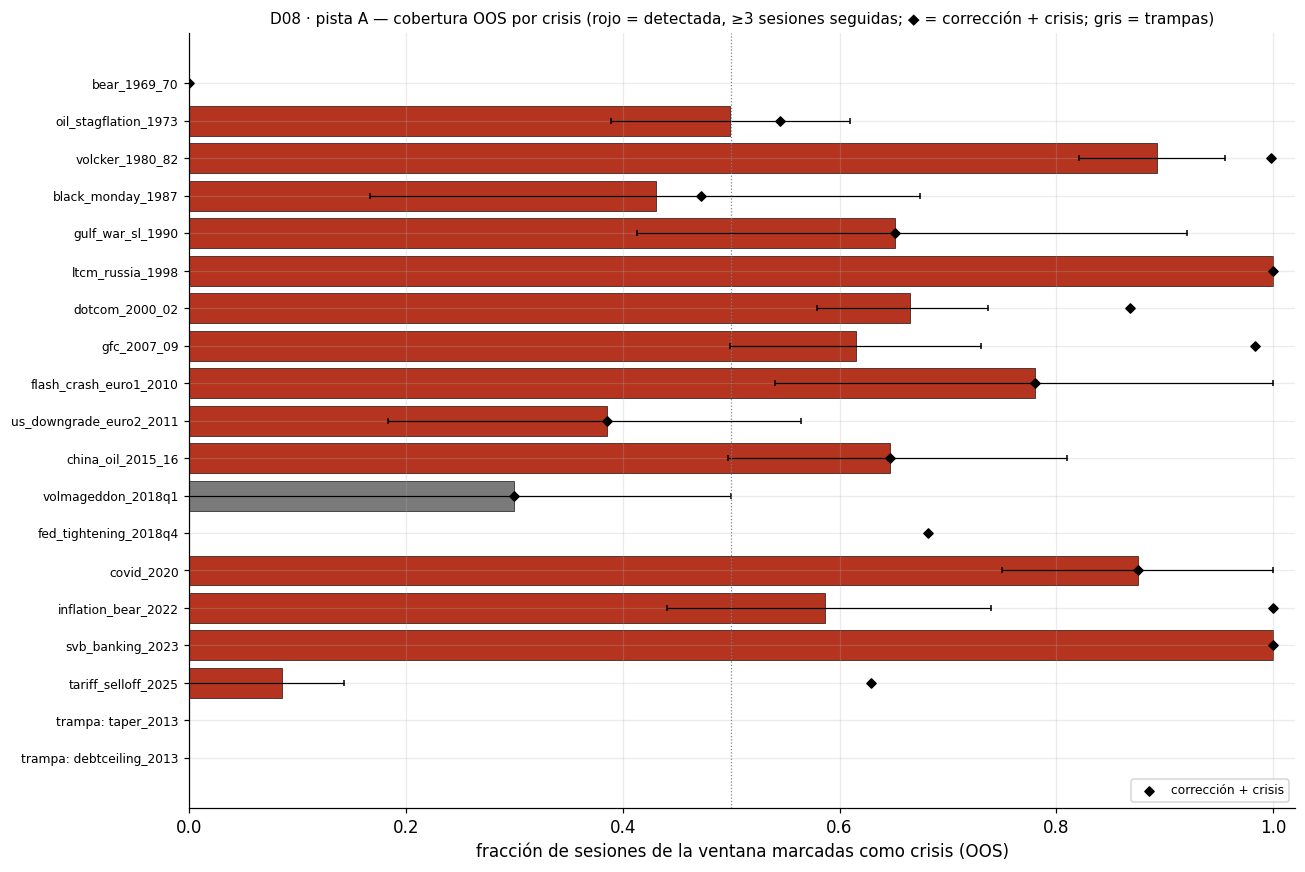

,activación crisis,corr+crisis
taper_2013,0.0,0.589
debtceiling_2013,0.0,0.000


D08 · pista A: puesto de detección ADR-003 = 9/12 (elegible) | score F1 = 0.467
  eventos detectados = 14/17 (recall 0.82) | precisión = 0.326, lift 1.68x sobre la tasa base 0.194
  días marcados = 37.3% | falsa alarma = 0.674 | switching = 0.0157 | duración media = 63.4 d | estabilidad de etiqueta = 0.773 | coste = 29.6 min


In [12]:
COBERTURAS[('A', 'D08')] = ficha('D08', 'A')

### 4.5 D08 `hmm_tstudent` — pista B

figura -> results/detectores/f3_hmm/D08_B_estados_oos.png


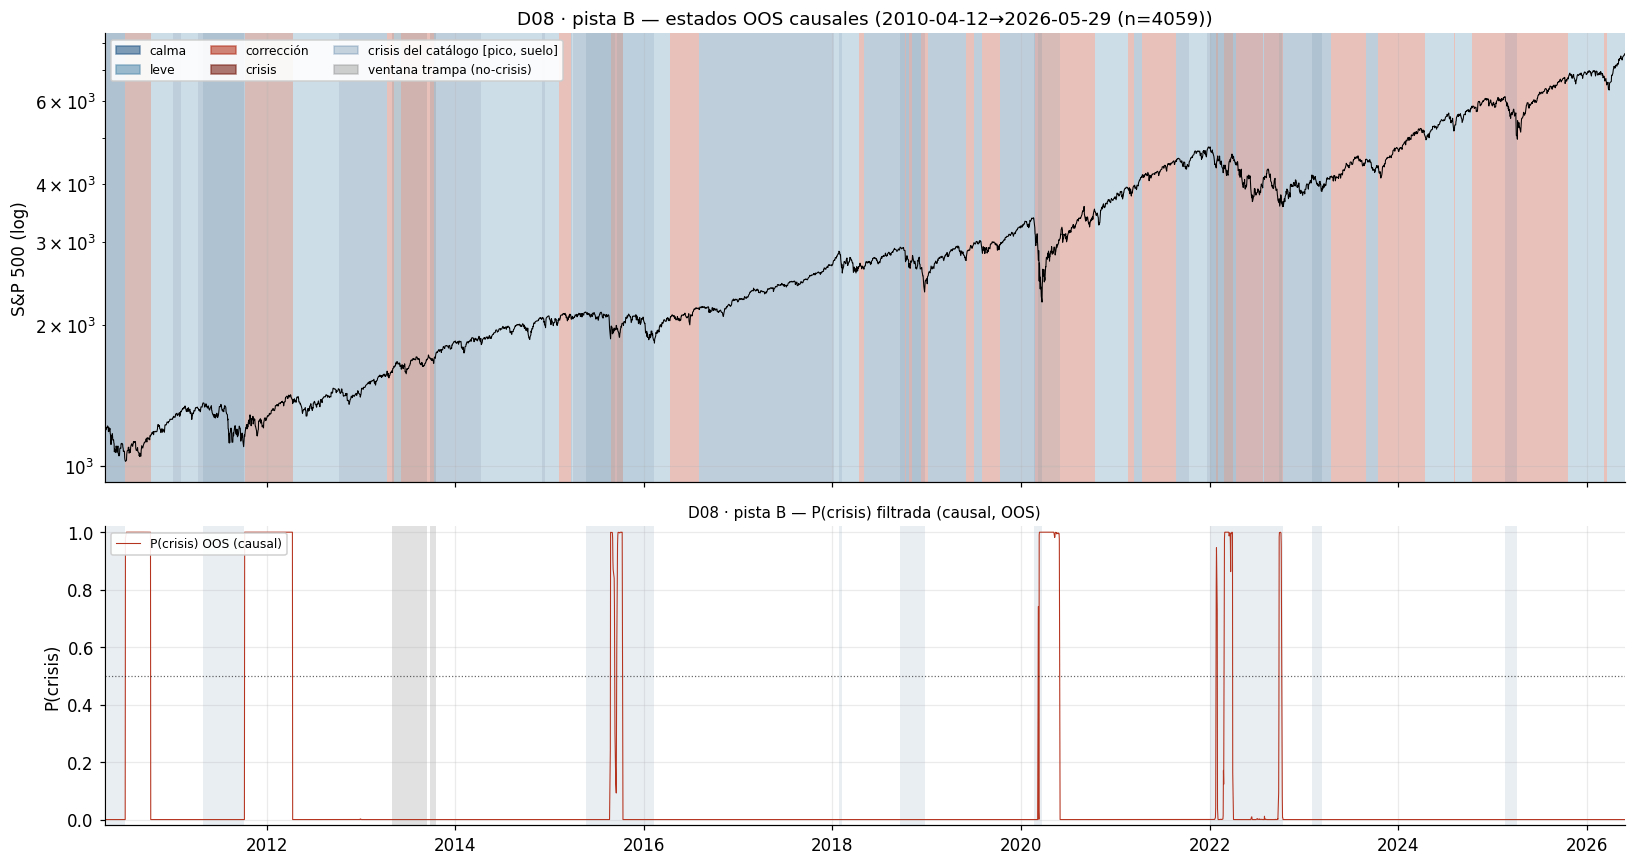

,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias,corr+crisis
crisis,,,,,,,,
flash_crash_euro1_2010,2010-04-23,2010-07-02,0.020,0.000,0.020,0.0,NaN,0.020
us_downgrade_euro2_2011,2011-04-29,2011-10-03,0.000,0.000,0.000,0.0,-252.0,0.000
china_oil_2015_16,2015-05-21,2016-02-11,0.152,0.054,0.266,1.0,-117.0,0.179
volmageddon_2018q1,2018-01-26,2018-02-08,0.000,0.000,0.000,0.0,NaN,0.000
fed_tightening_2018q4,2018-09-20,2018-12-24,0.000,0.000,0.000,0.0,NaN,0.273
covid_2020,2020-02-19,2020-03-23,0.375,0.042,0.750,1.0,-7.0,0.833
inflation_bear_2022,2022-01-03,2022-10-12,0.179,0.079,0.309,1.0,-178.0,0.765
svb_banking_2023,2023-02-02,2023-03-13,0.000,0.000,0.000,0.0,-252.0,0.000
tariff_selloff_2025,2025-02-19,2025-04-08,0.000,0.000,0.000,0.0,NaN,1.000


figura -> results/detectores/f3_hmm/D08_B_cobertura_crisis.png


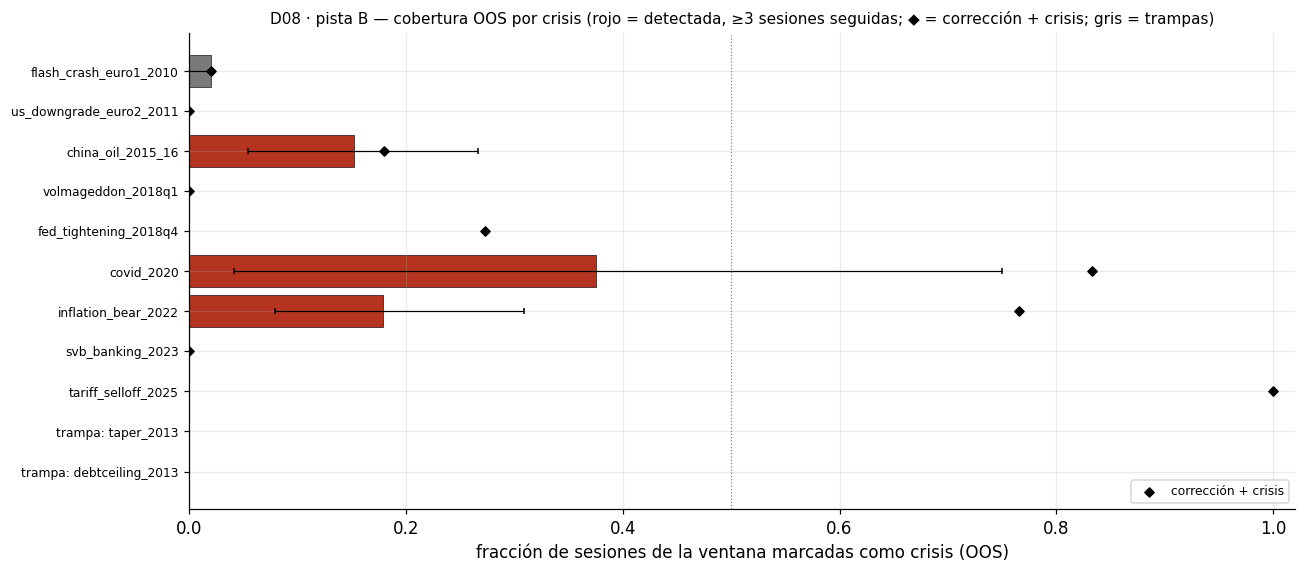

,activación crisis,corr+crisis
taper_2013,0.0,0.800
debtceiling_2013,0.0,0.667


D08 · pista B: puesto de detección ADR-003 = 9/12 (elegible) | score F1 = 0.274
  eventos detectados = 3/9 (recall 0.33) | precisión = 0.233, lift 1.35x sobre la tasa base 0.173
  días marcados = 7.7% | falsa alarma = 0.767 | switching = 0.0177 | duración media = 55.6 d | estabilidad de etiqueta = 0.664 | coste = 2.9 min


In [13]:
COBERTURAS[('B', 'D08')] = ficha('D08', 'B')

### 4.6 D08 — diagnóstico ilustrativo: colas, severidad y persistencia

Rescata las secciones §2–§4, §7–§8 y §11 de `08_hmm_tstudent.ipynb` (v1) sobre los datos v2:

- **Parámetros por estado** y **monotonía de severidad**: la volatilidad anual del S&P 500 debe
  crecer de calma a crisis, tanto con el Viterbi in-sample (ilustrativo) como con las etiquetas
  **OOS causales** del benchmark (esta segunda parte sí es causal). El retorno medio **no** tiene
  por qué ser monótono: la t es simétrica y el estado de crisis recoge saltos extremos en ambos
  sentidos (incluidos los rebotes de *bear-market rally*). La v1 detenía el notebook con `assert`
  si fallaba; aquí se informa sin ocultarlo.
- **Espacio de features (PCA 2D)** coloreado por estado: separabilidad y gradiente de severidad.
- **Anatomía de las colas**: en el estado de crisis, la feature más leptocúrtica con la densidad
  t marginal ajustada frente a una gaussiana de **la misma varianza** (eje log); y `ν` por estado
  (se espera `ν` menor = colas más pesadas en la crisis).
- **Matriz de transición** y persistencia esperada por estado.

Opcional (`EXPLORAR_K = False`): la selección de `K` por BIC sobre {3, 4} que hizo la v1, para
D08 y D13, sobre la muestra completa de cada pista.

In [14]:
if DIAGNOSTICO_ILUSTRATIVO:
    for pista in PISTAS:
        det, X, ret = ajuste_muestra_completa(spec_de(pista, 'D08'), pista)
        DIAG[('D08', pista)] = dict(det=det, X=X, ret=ret, est_is=pd.Series(det.predict(X), index=X.index))
        print(f'D08 · pista {pista}: K = {det.n_states} | logL = {det.score(X):,.1f} | parámetros = '
              f'{det.n_parameters()} | ν por estado (canónico) = {np.round(det.dofs_canonical(), 2)}')
else:
    print('Diagnóstico ilustrativo desactivado (DIAGNOSTICO_ILUSTRATIVO = False).')

D08 · pista A: K = 4 | logL = -20,611.3 | parámetros = 235 | ν por estado (canónico) = [14.52 14.63  9.3   5.23]


D08 · pista B: K = 4 | logL = -5,932.7 | parámetros = 495 | ν por estado (canónico) = [21.25 19.6  19.57  4.55]


In [15]:
# Parámetros por estado: in-sample (Viterbi t, NO causal) y OOS causal (panel del benchmark).
SEVERIDAD = {}
COLA_V1 = {}   # contraste del hallazgo v1 «con K > 2 la crisis es la cola más extrema y estrecha» (§1.3)
for pista in PISTAS:
    m, panel = fila(pista, 'D08'), PANELES[(pista, 'D08')]
    oos, mono_oos = severidad_oos(pista, m, panel)
    SEVERIDAD[('D08', pista)] = (oos, mono_oos)
    tabla = oos.add_suffix('_oos')
    if ('D08', pista) in DIAG:
        d = DIAG[('D08', pista)]
        K = d['det'].n_states
        tabla['nu'] = d['det'].dofs_canonical()
        tabla['vol_anual_is'] = [float(d['ret'][d['est_is'] == s].std() * np.sqrt(252)) for s in range(K)]
        tabla['ret_anual_is'] = [float(d['ret'][d['est_is'] == s].mean() * 252) for s in range(K)]
        tabla['n_dias_is'] = [int((d['est_is'] == s).sum()) for s in range(K)]
        mono_is = bool(np.all(np.diff(tabla['vol_anual_is'].to_numpy()) > 0))
        print(f'Pista {pista}: monotonía de volatilidad in-sample = {mono_is}')
    display(tabla.round(4))
    print(f'Pista {pista}: monotonía de volatilidad OOS causal = {mono_oos}'
          + ('' if mono_oos else '  <- ATENCIÓN: el orden económico no es monótono fuera de muestra'))
    # Hallazgo v1 (§1.3): con K > 2, ¿es el estado de crisis OOS la cola más extrema Y estrecha?
    kc = len(oos) - 1
    frac = oos['n_dias'] / oos['n_dias'].sum()
    extrema = bool(np.isclose(oos['vol_anual'].iloc[kc], oos['vol_anual'].max()))
    estrecha = bool(np.isclose(frac.iloc[kc], frac.min()))
    peor_ret = bool(np.isclose(oos['ret_anual'].iloc[kc], oos['ret_anual'].min()))
    puesto_tam = int(frac.rank(ascending=False, method='min').iloc[kc])
    if extrema and estrecha:
        lectura_v1 = 'se reproduce' + ('' if peor_ret else ', aunque su retorno medio OOS no es el peor')
    elif extrema:
        lectura_v1 = 'NO se reproduce: es la cola de mayor volatilidad, pero no un estado estrecho'
    else:
        lectura_v1 = 'NO se reproduce: el estado de crisis ni siquiera es el de mayor volatilidad'
    COLA_V1[pista] = dict(frac=float(frac.iloc[kc]), puesto_tamano=puesto_tam, n_estados=len(oos),
                          extrema=extrema, estrecha=estrecha, ret=float(oos['ret_anual'].iloc[kc]),
                          peor_ret=peor_ret, lectura=lectura_v1)
    print(f'Pista {pista}: estado de crisis OOS = {frac.iloc[kc]:.1%} de las sesiones ({puesto_tam}º de {len(oos)} '
          f'estados por tamaño); volatilidad OOS {"la más alta" if extrema else "NO la más alta"}; retorno anual OOS '
          f'{oos["ret_anual"].iloc[kc]:+.1%} ({"el más bajo" if peor_ret else "no es el más bajo"}) -> hallazgo v1 '
          f'«crisis = cola más extrema y estrecha»: {lectura_v1}.')

Pista A: monotonía de volatilidad in-sample = True


,etiqueta_oos,n_dias_oos,ret_anual_oos,vol_anual_oos,nu,vol_anual_is,ret_anual_is,n_dias_is
estado,,,,,,,,
0,calma,3021,0.1221,0.1122,14.5163,0.1005,0.1492,5245
1,leve,3354,0.0980,0.1310,14.6328,0.1283,0.1231,4256
2,corrección,2484,0.0896,0.1701,9.2960,0.1516,-0.0052,4236
3,crisis,5274,0.0439,0.2189,5.2256,0.3028,-0.0430,2412


Pista A: monotonía de volatilidad OOS causal = True
Pista A: estado de crisis OOS = 37.3% de las sesiones (1º de 4 estados por tamaño); volatilidad OOS la más alta; retorno anual OOS +4.4% (el más bajo) -> hallazgo v1 «crisis = cola más extrema y estrecha»: NO se reproduce: es la cola de mayor volatilidad, pero no un estado estrecho.
Pista B: monotonía de volatilidad in-sample = False


,etiqueta_oos,n_dias_oos,ret_anual_oos,vol_anual_oos,nu,vol_anual_is,ret_anual_is,n_dias_is
estado,,,,,,,,
0,calma,1549,0.0332,0.1461,21.2505,0.1306,0.1791,1183
1,leve,1050,0.2026,0.1409,19.6040,0.1157,0.1455,1718
2,corrección,1147,0.0817,0.1785,19.5734,0.2119,0.0509,1371
3,crisis,313,0.3442,0.3174,4.5488,0.3966,-0.2108,543


Pista B: monotonía de volatilidad OOS causal = False  <- ATENCIÓN: el orden económico no es monótono fuera de muestra
Pista B: estado de crisis OOS = 7.7% de las sesiones (4º de 4 estados por tamaño); volatilidad OOS la más alta; retorno anual OOS +34.4% (no es el más bajo) -> hallazgo v1 «crisis = cola más extrema y estrecha»: se reproduce, aunque su retorno medio OOS no es el peor.


figura -> results/detectores/f3_hmm/D08_A_colas_t_y_pca.png


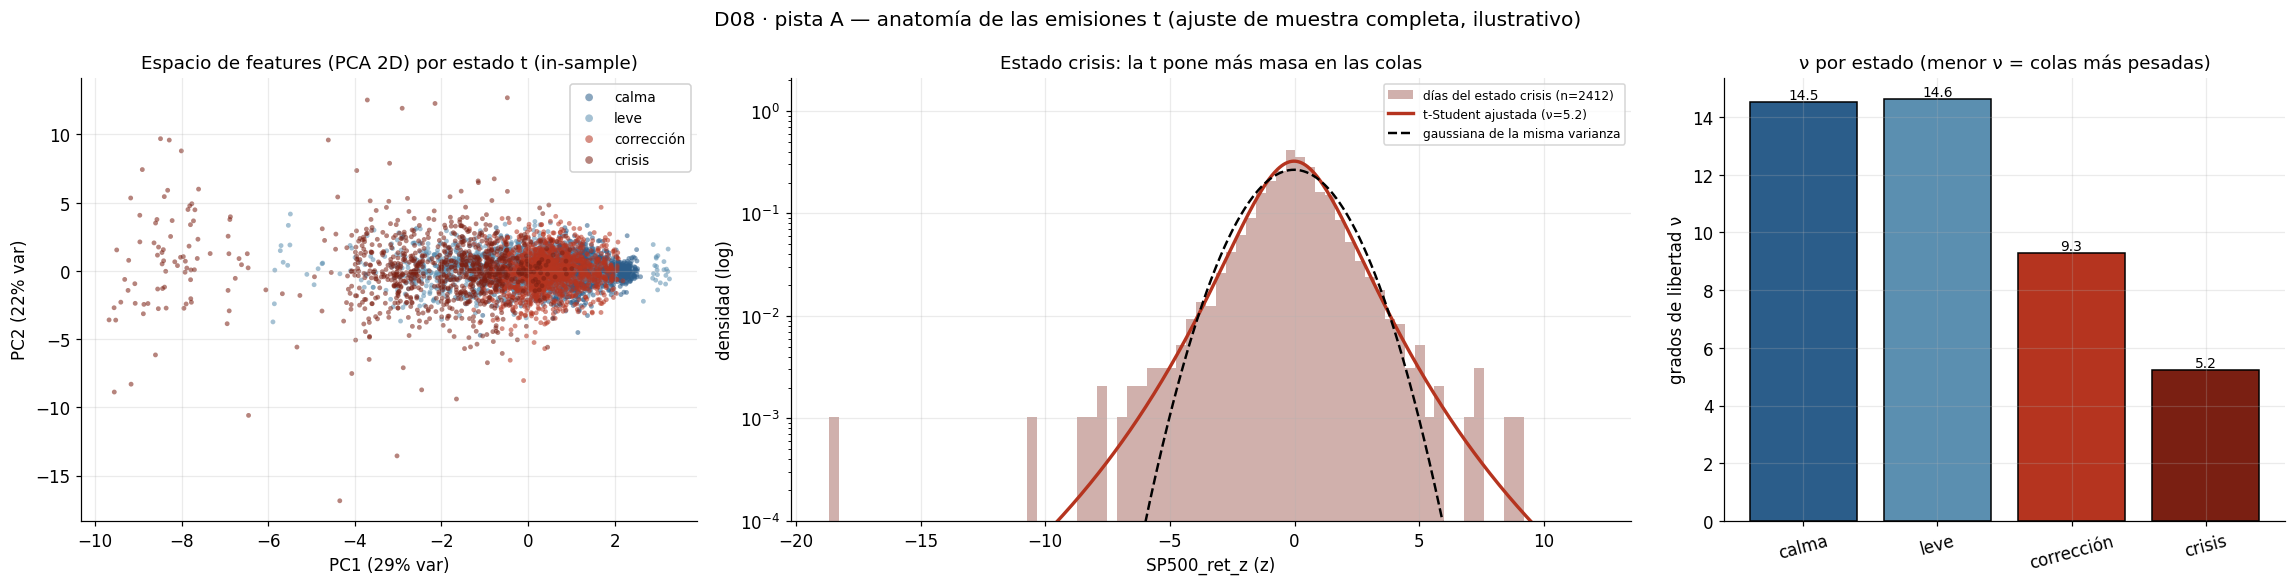

Pista A: feature más leptocúrtica en crisis = SP500_ret_z (curtosis en exceso 12.3); ν decreciente hacia la crisis = False; ν(crisis) mínimo = True


figura -> results/detectores/f3_hmm/D08_B_colas_t_y_pca.png


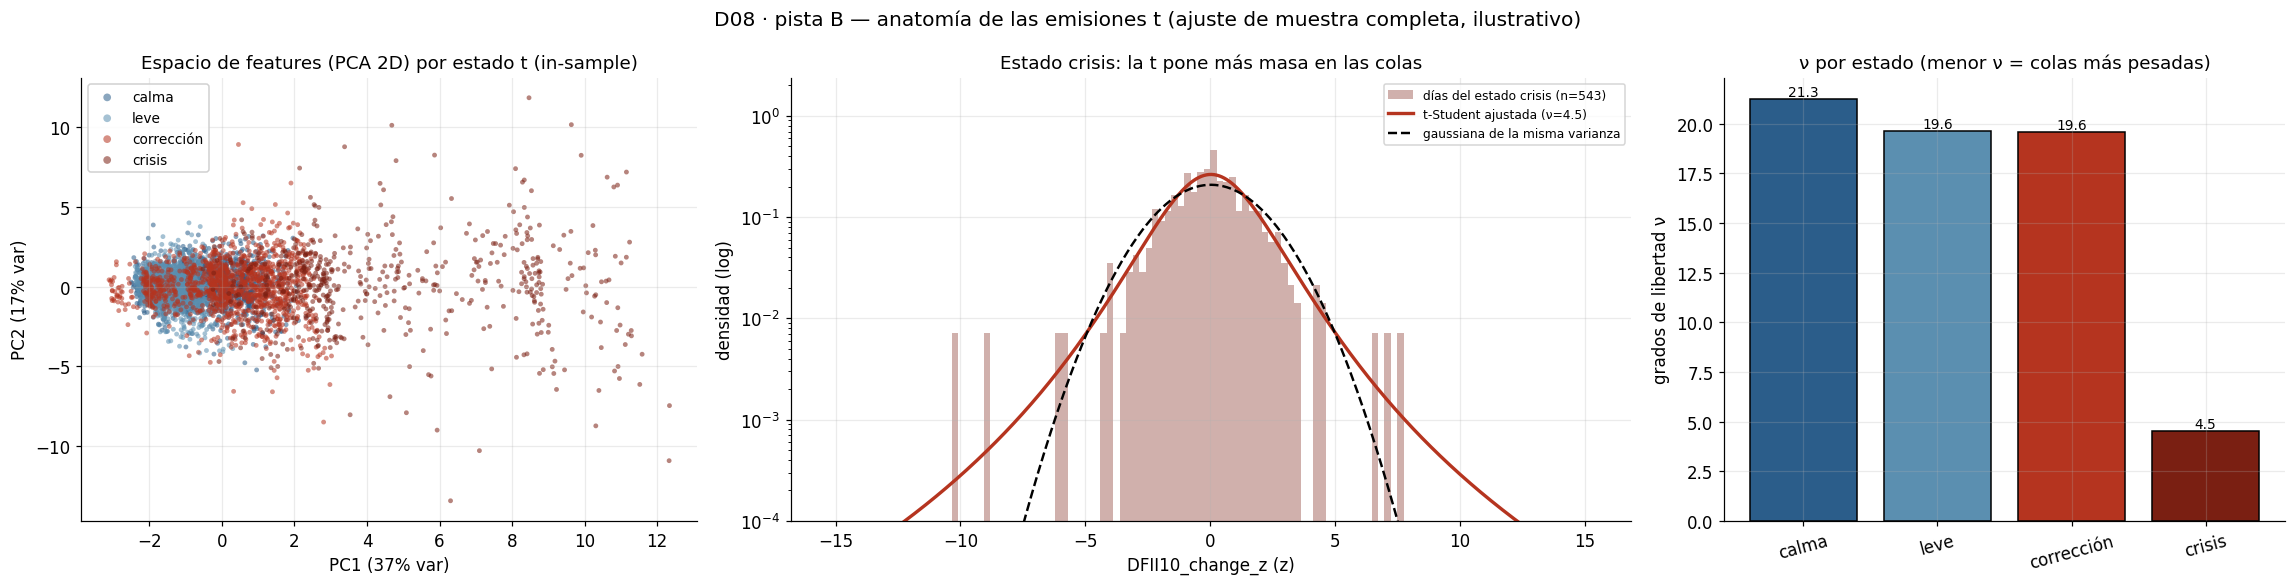

Pista B: feature más leptocúrtica en crisis = DFII10_change_z (curtosis en exceso 5.1); ν decreciente hacia la crisis = True; ν(crisis) mínimo = True


In [16]:
# Espacio de features (PCA 2D) por estado t in-sample y anatomía de las colas t vs gaussiana.
for pista in PISTAS:
    if ('D08', pista) not in DIAG:
        continue
    d = DIAG[('D08', pista)]
    det, X, est_is = d['det'], d['X'], d['est_is']
    K, cs = det.n_states, det.crisis_state
    order = det._canonical_order
    means_c, scales_c, nu_c = det._model.means_[order], det._model.scales_[order], det.dofs_canonical()
    cols = det._used_features
    Xv = X[cols].to_numpy()
    en_crisis = est_is.to_numpy() == cs
    kurt = [stats.kurtosis(Xv[en_crisis, j], fisher=True, nan_policy='omit') for j in range(len(cols))]
    jf = int(np.nanargmax(kurt))
    m_j, s_jj, nu_j = float(means_c[cs, jf]), float(scales_c[cs, jf, jf]), float(nu_c[cs])
    sigma = np.sqrt(s_jj * nu_j / (nu_j - 2.0)) if nu_j > 2.0 else np.sqrt(s_jj)
    xs = np.linspace(m_j - 8 * sigma, m_j + 8 * sigma, 600)
    t_pdf = stats.t.pdf(xs, df=nu_j, loc=m_j, scale=np.sqrt(s_jj))
    g_pdf = stats.norm.pdf(xs, loc=m_j, scale=sigma)

    fig, (axP, axA, axB) = plt.subplots(1, 3, figsize=(21, 5.4), gridspec_kw={'width_ratios': [1.1, 1.5, 1]})
    viz.plot_feature_space_scatter(X[cols], est_is, use_pca=True, crisis_state=cs, labels=ETIQUETAS[K], ax=axP,
                                   title='Espacio de features (PCA 2D) por estado t (in-sample)')
    datos_cri = Xv[en_crisis, jf]
    datos_cri = datos_cri[np.isfinite(datos_cri)]
    axA.hist(datos_cri, bins=70, density=True, color=viz.regime_color(cs, K), alpha=0.35,
             label=f'días del estado crisis (n={len(datos_cri)})')
    axA.plot(xs, t_pdf, color=viz.C_CRISIS, lw=2.2, label=f't-Student ajustada (ν={nu_j:.1f})')
    axA.plot(xs, g_pdf, color='black', ls='--', lw=1.6, label='gaussiana de la misma varianza')
    axA.set_yscale('log')
    axA.set_ylim(max(1e-4, np.nanmin(t_pdf[t_pdf > 0]) * 0.5), None)
    axA.set_xlabel(f'{cols[jf]} (z)')
    axA.set_ylabel('densidad (log)')
    axA.set_title('Estado crisis: la t pone más masa en las colas')
    axA.legend(fontsize=8)
    barras = axB.bar(range(K), nu_c, color=[viz.regime_color(s, K) for s in range(K)], edgecolor='black')
    for b, nu in zip(barras, nu_c):
        axB.text(b.get_x() + b.get_width() / 2, b.get_height(), f'{nu:.1f}', ha='center', va='bottom', fontsize=9)
    axB.set_xticks(range(K))
    axB.set_xticklabels(ETIQUETAS[K], rotation=15)
    axB.set_ylabel('grados de libertad ν')
    axB.set_title('ν por estado (menor ν = colas más pesadas)')
    fig.suptitle(f'D08 · pista {pista} — anatomía de las emisiones t (ajuste de muestra completa, ilustrativo)')
    fig.tight_layout()
    guardar(fig, f'D08_{pista}_colas_t_y_pca')
    plt.show()
    print(f'Pista {pista}: feature más leptocúrtica en crisis = {cols[jf]} (curtosis en exceso {kurt[jf]:.1f}); '
          f'ν decreciente hacia la crisis = {bool(np.all(np.diff(nu_c) < 0))}; '
          f'ν(crisis) mínimo = {bool(np.isclose(nu_c[cs], nu_c.min()))}')

Pista A: persistencia esperada 1/(1−A_ii) por estado = {'calma': 132.0, 'leve': 159.3, 'corrección': 83.8, 'crisis': 86.2} días


figura -> results/detectores/f3_hmm/D08_A_severidad_transicion.png


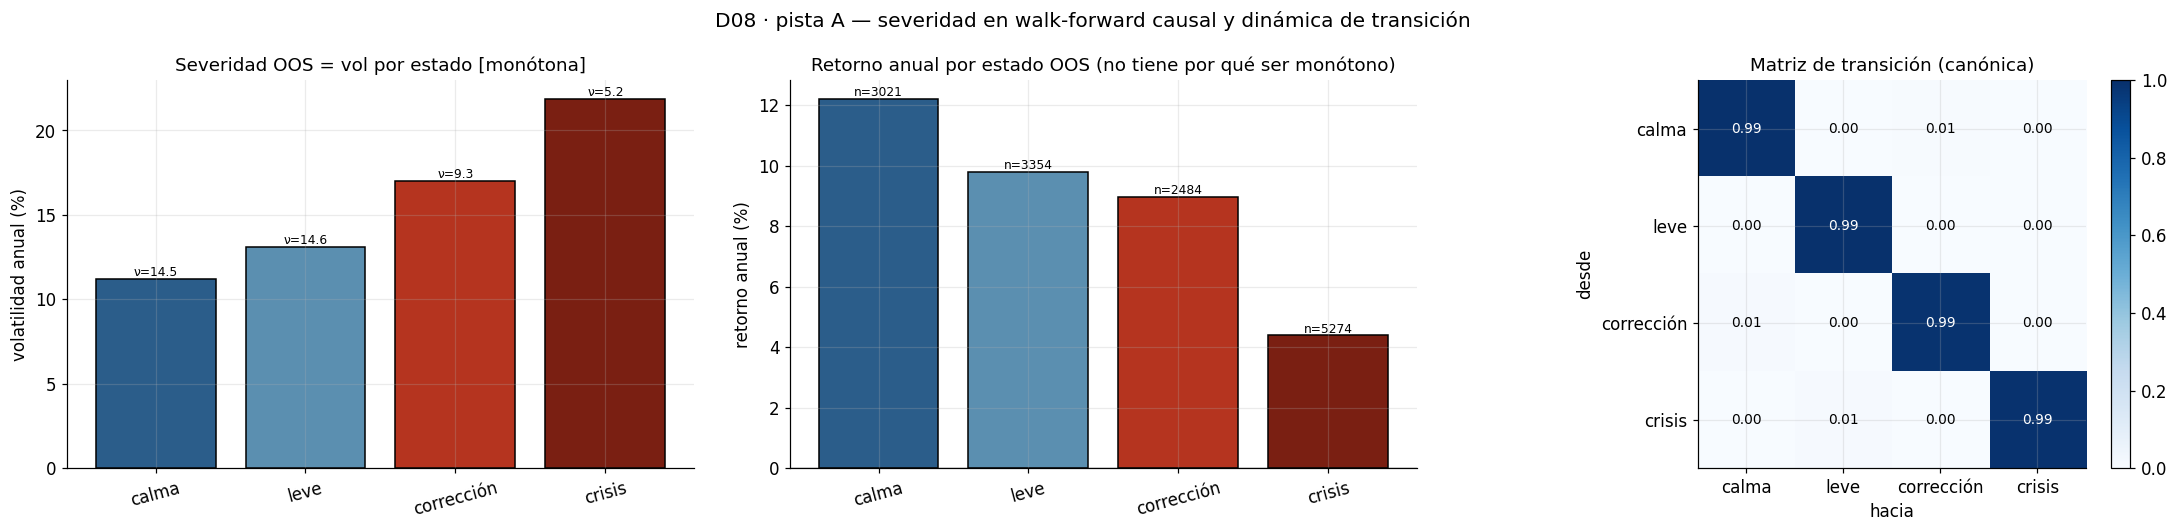

Pista B: persistencia esperada 1/(1−A_ii) por estado = {'calma': 168.6, 'leve': 163.8, 'corrección': 145.1, 'crisis': 181.3} días


figura -> results/detectores/f3_hmm/D08_B_severidad_transicion.png


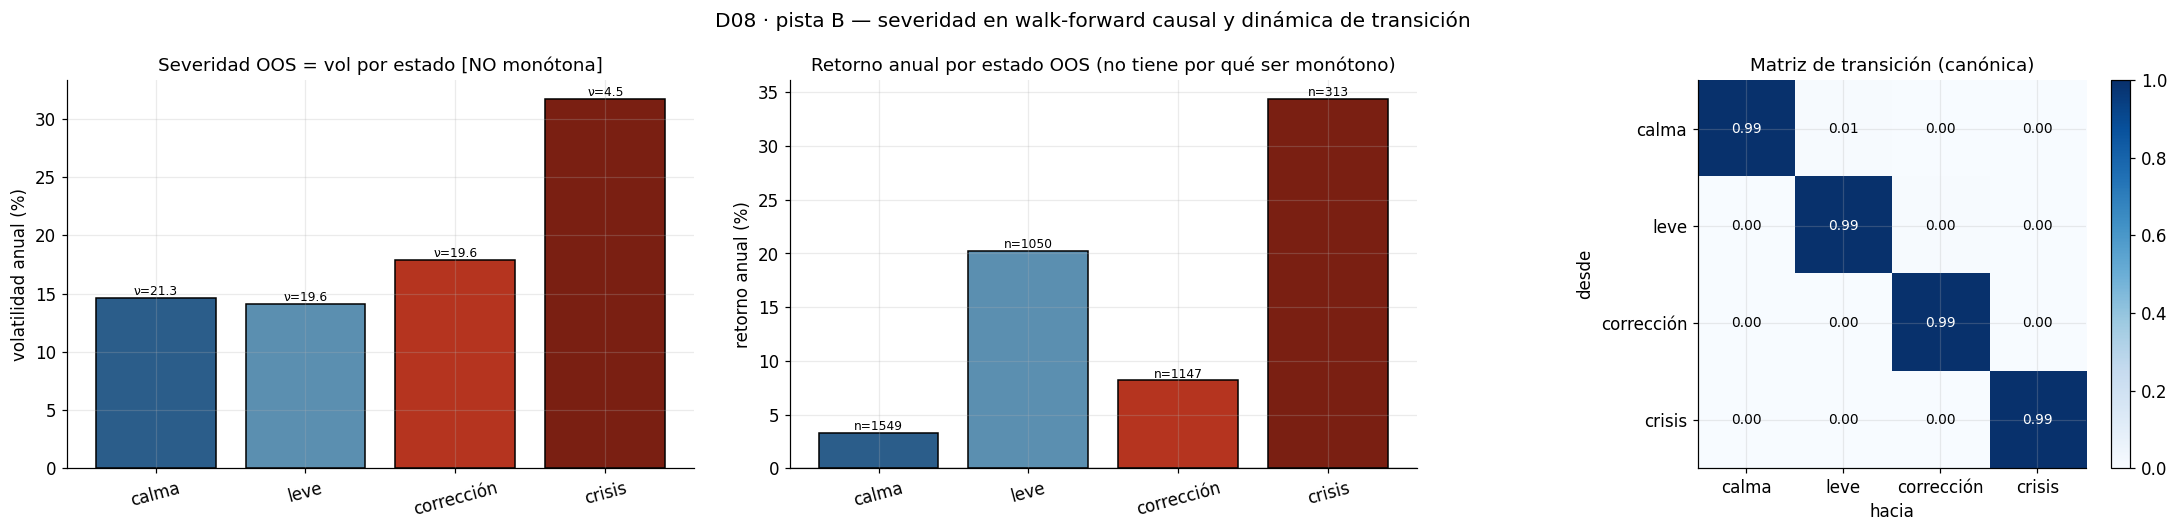

In [17]:
# Severidad OOS (causal) y matriz de transición (ajuste de muestra completa).
for pista in PISTAS:
    oos, mono = SEVERIDAD[('D08', pista)]
    K = len(oos)
    colores = [viz.regime_color(s, K) for s in range(K)]
    fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(20, 4.9))
    bA = axA.bar(range(K), oos['vol_anual'] * 100, color=colores, edgecolor='black')
    if ('D08', pista) in DIAG:
        for b, nu in zip(bA, DIAG[('D08', pista)]['det'].dofs_canonical()):
            axA.text(b.get_x() + b.get_width() / 2, b.get_height(), f'ν={nu:.1f}', ha='center', va='bottom', fontsize=8)
    axA.set_xticks(range(K))
    axA.set_xticklabels(ETIQUETAS[K], rotation=15)
    axA.set_ylabel('volatilidad anual (%)')
    axA.set_title(f'Severidad OOS = vol por estado [{"monótona" if mono else "NO monótona"}]')
    bB = axB.bar(range(K), oos['ret_anual'] * 100, color=colores, edgecolor='black')
    axB.axhline(0, color='black', lw=0.8)
    for b, n in zip(bB, oos['n_dias']):
        axB.text(b.get_x() + b.get_width() / 2, b.get_height(), f'n={n}', ha='center',
                 va='bottom' if b.get_height() >= 0 else 'top', fontsize=8)
    axB.set_xticks(range(K))
    axB.set_xticklabels(ETIQUETAS[K], rotation=15)
    axB.set_ylabel('retorno anual (%)')
    axB.set_title('Retorno anual por estado OOS (no tiene por qué ser monótono)')
    if ('D08', pista) in DIAG:
        A = DIAG[('D08', pista)]['det'].transition_canonical()
        viz.plot_transition_matrix(A, labels=ETIQUETAS[K], ax=axC, title='Matriz de transición (canónica)')
        persist = {ETIQUETAS[K][i]: round(float(1.0 / (1.0 - A[i, i])), 1) for i in range(K)}
        print(f'Pista {pista}: persistencia esperada 1/(1−A_ii) por estado =', persist, 'días')
    else:
        axC.axis('off')
    fig.suptitle(f'D08 · pista {pista} — severidad en walk-forward causal y dinámica de transición')
    fig.tight_layout()
    guardar(fig, f'D08_{pista}_severidad_transicion')
    plt.show()

In [18]:
EXPLORAR_K = False   # True = repite la selección de K por BIC sobre {3, 4} de la v1 (D08 y D13), ilustrativo

if EXPLORAR_K:
    filas = []
    for pista in PISTAS:
        for base in (spec_de(pista, 'D08'), spec_d13(pista)):
            for k in (3, 4):
                spec_k = replace(base, params={**base.params, 'n_states': k})
                det, X, _ = ajuste_muestra_completa(spec_k, pista)
                filas.append({'pista': pista, 'id': base.detector_id, 'K': k, 'logL': det.score(X),
                              'n_params': det.n_parameters(), 'AIC': det.aic(X), 'BIC': det.bic(X)})
    SEL_K = pd.DataFrame(filas)
    display(SEL_K.round(1))
    for (pista, det_id), g in SEL_K.groupby(['pista', 'id']):
        k_bic = int(g.loc[g['BIC'].idxmin(), 'K'])
        k_reg = int(spec_de(pista, 'D08').params['n_states'])
        print(f'{det_id} · pista {pista}: K* por BIC = {k_bic} | K del registro = {k_reg}'
              + (' (coinciden)' if k_bic == k_reg else ' (NO coinciden: el registro no se cambia a posteriori)'))
else:
    print('Exploración de K desactivada (EXPLORAR_K = False). En v2, K está fijado a priori en el registro.')

Exploración de K desactivada (EXPLORAR_K = False). En v2, K está fijado a priori en el registro.


### 4.7 Ablación D08 → D13 (HSMM t-Student)

**Pregunta.** ¿Modelar explícitamente la duración de los regímenes (§1.4) mejora la dinámica
temporal del HMM t-Student? El experimento es **controlado**: mismas features, emisiones t,
número de estados, train inicial y frecuencia de re-ajuste; solo cambia la ley de permanencia.

**Hipótesis previa (v1).** Frente a D08, el HSMM debería reducir el *switching* espurio y alargar
los episodios sin perder demasiada sensibilidad; podría reaccionar peor a shocks breves si la
regularización de la duración es excesiva.

**Criterios declarados antes de mirar resultados (v1, se mantienen en v2).** La hipótesis se
apoya solo si se cumplen los cuatro: (1) `switching_D13 < switching_D08`; (2)
`duración_D13 > duración_D08`; (3) la cobertura media de crisis OOS no cae más de 10 puntos;
(4) la tasa global de falsas alarmas no empeora más de 10 puntos.

#### 4.7.1 Resultado histórico de la Capa 1 (v1)

Tabla de `docs/historia/capa1/resultados/ablation_hsmm/` (copia de `capa1-final:capa1_exploracion/results/ablation_hsmm/`):
D8 re-ejecutado como referencia y D13 sobre la misma ventana OOS de la v1 (features puente,
cuatro crisis del catálogo v1). La celda comprueba que ambas filas comparten ventana.

Misma ventana OOS en D8 y D13 (v1): True | 2012-07-31→2026-08-26 (n=3432)


detector,hmm_tstudent_4s,hsmm_tstudent_4s
n_states,4.000000,4.000000
switching_rate,0.047494,0.049534
mean_regime_duration,20.926829,20.070175
false_alarm_rate,0.411348,0.413669
label_stability,0.895503,0.897560
silhouette,0.022705,0.022798
log_likelihood,-11392.520176,-11458.864333
bic,24129.165010,24295.667781
cov_GFC_2008,NaN,NaN
cov_EuroDebt_2011,NaN,NaN


Δ switching (D13 − D8) = +0.0020  [negativo favorece D13]
Δ duración media      = -0.86 días [positivo favorece D13]
Δ falsas alarmas      = +0.0023
Δ estabilidad         = +0.0021
Δ BIC aproximado      = +167 [negativo favorece D13; interpretar con cautela]
Cobertura media OOS: D8 = 0.651 | D13 = 0.652
  cov_COVID_2020: D8 = 0.660 | D13 = 0.680 | Δ = +0.020
  cov_Inflation_2022: D8 = 0.643 | D13 = 0.623 | Δ = -0.019
  [FALLA] menos switching
  [FALLA] mayor duración media
  [OK] cobertura no cae > 10 pp
  [OK] falsas alarmas no suben > 10 pp
VEREDICTO v1: hipótesis NO apoyada


figura -> results/detectores/f3_hmm/D13_v1_ablacion.png


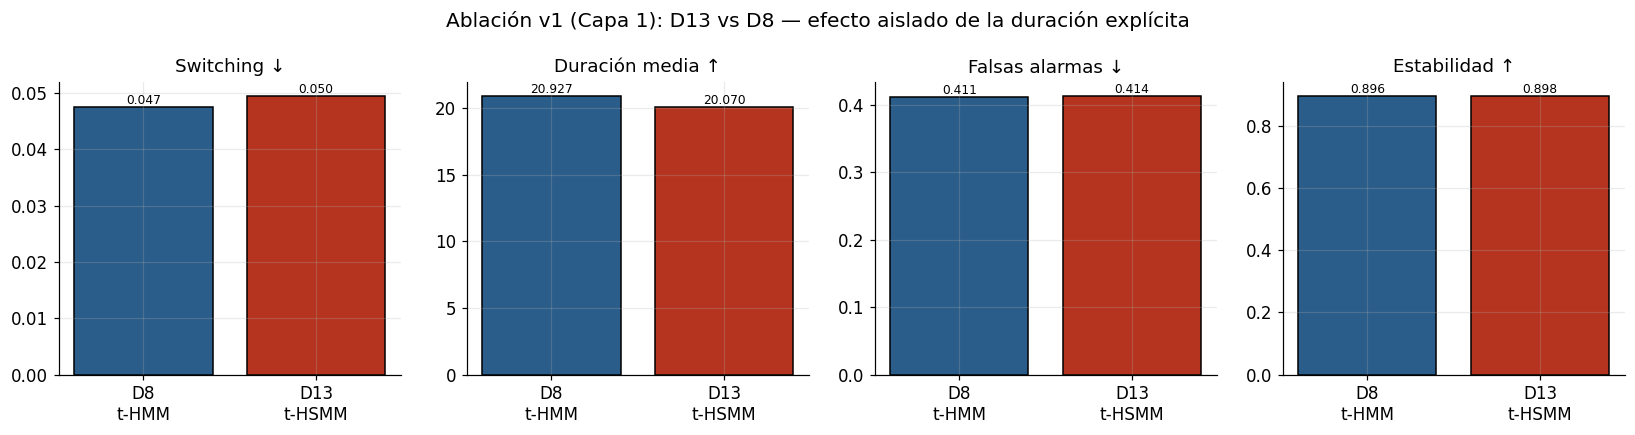

In [19]:
def ruta_historia_v1(*partes):
    """Resultados congelados de la Capa 1 (docs/historia/capa1/resultados; original en el tag capa1-final)."""
    ruta = (rutas.DOCS / 'historia' / 'capa1' / 'resultados').joinpath(*partes)
    if ruta.exists():
        return ruta
    raise FileNotFoundError(f'No se encuentra {"/".join(partes)}; recupéralo del tag git capa1-final.')


def criterios_ablacion(d8, d13, cov_d8, cov_d13):
    return {
        'menos switching': float(d13['switching_rate']) < float(d8['switching_rate']),
        'mayor duración media': float(d13['mean_regime_duration']) > float(d8['mean_regime_duration']),
        'cobertura no cae > 10 pp': cov_d13 >= cov_d8 - 0.10,
        'falsas alarmas no suben > 10 pp': float(d13['false_alarm_rate']) <= float(d8['false_alarm_rate']) + 0.10,
    }


def cobertura_media(fila_m, ventanas=None):
    cols = ([f'cov_{w}' for w in ventanas] if ventanas is not None else
            [c for c in fila_m.index if str(c).startswith('cov_') and not str(c).endswith(('_lo', '_hi'))])
    return float(pd.to_numeric(fila_m.reindex(cols), errors='coerce').mean())


ABL_V1 = pd.concat([pd.read_csv(ruta_historia_v1('ablation_hsmm', 'metrics_d8_reference.csv')),
                    pd.read_csv(ruta_historia_v1('ablation_hsmm', 'metrics_d13_hsmm.csv'))],
                   ignore_index=True).set_index('detector')
misma_ventana = bool(ABL_V1[['oos_start', 'oos_end', 'n_oos']].nunique().eq(1).all())
print('Misma ventana OOS en D8 y D13 (v1):', misma_ventana, '|', ABL_V1['ventana_eval'].iloc[0])
cols_v1 = (['n_states', 'switching_rate', 'mean_regime_duration', 'false_alarm_rate', 'label_stability',
            'silhouette', 'log_likelihood', 'bic']
           + [c for c in ABL_V1 if c.startswith(('cov_', 'fa_', 'leadlag_')) and not c.endswith(('_lo', '_hi'))])
display(ABL_V1[cols_v1].T)

d8_v1, d13_v1 = ABL_V1.iloc[0], ABL_V1.iloc[1]
cov8_v1, cov13_v1 = cobertura_media(d8_v1), cobertura_media(d13_v1)
print(f'Δ switching (D13 − D8) = {d13_v1.switching_rate - d8_v1.switching_rate:+.4f}  [negativo favorece D13]')
print(f'Δ duración media      = {d13_v1.mean_regime_duration - d8_v1.mean_regime_duration:+.2f} días [positivo favorece D13]')
print(f'Δ falsas alarmas      = {d13_v1.false_alarm_rate - d8_v1.false_alarm_rate:+.4f}')
print(f'Δ estabilidad         = {d13_v1.label_stability - d8_v1.label_stability:+.4f}')
print(f'Δ BIC aproximado      = {d13_v1.bic - d8_v1.bic:+,.0f} [negativo favorece D13; interpretar con cautela]')
print(f'Cobertura media OOS: D8 = {cov8_v1:.3f} | D13 = {cov13_v1:.3f}')
for c in [c for c in ABL_V1 if c.startswith('cov_') and not c.endswith(('_lo', '_hi'))]:
    if pd.notna(d8_v1[c]):
        print(f'  {c}: D8 = {d8_v1[c]:.3f} | D13 = {d13_v1[c]:.3f} | Δ = {d13_v1[c] - d8_v1[c]:+.3f}')
CHECKS_V1 = criterios_ablacion(d8_v1, d13_v1, cov8_v1, cov13_v1)
for etiqueta, ok in CHECKS_V1.items():
    print(f'  [{"OK" if ok else "FALLA"}] {etiqueta}')
print('VEREDICTO v1:', 'hipótesis APOYADA' if all(CHECKS_V1.values()) else 'hipótesis NO apoyada')

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (col, titulo) in zip(axes, [('switching_rate', 'Switching ↓'), ('mean_regime_duration', 'Duración media ↑'),
                                    ('false_alarm_rate', 'Falsas alarmas ↓'), ('label_stability', 'Estabilidad ↑')]):
    barras = ax.bar(['D8\nt-HMM', 'D13\nt-HSMM'], [d8_v1[col], d13_v1[col]], color=[viz.C_LONG, viz.C_CRISIS],
                    edgecolor='black')
    for b in barras:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(titulo)
fig.suptitle('Ablación v1 (Capa 1): D13 vs D8 — efecto aislado de la duración explícita')
fig.tight_layout()
guardar(fig, 'D13_v1_ablacion')
plt.show()

**Lectura v1 (conclusión de `A1_hsmm_ablation.ipynb`, reformulada sin cifras escritas a mano).**
Los resultados de la celda anterior no respaldaron la hipótesis: D13 produjo una segmentación
prácticamente idéntica a D8 y no mejoró las dos variables que motivaban su implementación (el
*switching* no bajó y la duración media no subió). Las demás diferencias no fueron materiales
(falsas alarmas y estabilidad casi iguales, ganancias y pérdidas de cobertura que se compensan
entre COVID y la inflación de 2022, lead/lag idéntico) y el BIC aproximado de D13 fue peor, con la
cautela de su estimación en dos etapas. Por parsimonia, **D8 se mantuvo como representante de F3**
y D13 quedó como resultado negativo informativo; no se justificó desarrollar un EM HSMM conjunto
ni ampliar la búsqueda de hiperparámetros salvo que la duración explícita fuera en sí una pregunta
central de investigación.

#### 4.7.2 Re-ejecución v2 opcional (`EJECUTAR_ABLACION = False`)

Con `EJECUTAR_ABLACION = True` se evalúa D13 **con el mismo protocolo del benchmark que D08**
(`run_one`: misma rejilla común, mismo train inicial y `step`, mismo juez de la pista, métricas de
detección por evento) y se guardan métricas y panel en `results/detectores/f3_hmm/ablacion_d13/`
— **nunca** en `results/benchmark`, porque D13 no pertenece a la matriz oficial. Por defecto la
celda solo carga esos resultados si existen y su huella es vigente. Nota: la huella del benchmark
no incluye `hsmm_tstudent.py` (se excluye a propósito de la matriz oficial); si se modifica ese
archivo hay que forzar el recálculo con `FORZAR_ABLACION = True`.

In [20]:
EJECUTAR_ABLACION = False   # True = walk-forward de D13 con el protocolo del benchmark (lento: horas en A)
FORZAR_ABLACION = False
DIR_ABLACION = FIG_DIR / 'ablacion_d13'   # métricas y paneles propios; NUNCA results/benchmark

ABL_V2 = {}
for pista in PISTAS:
    spec = spec_d13(pista)
    ruta_m = bm_cache._metric_path(DIR_ABLACION, pista, 'D13')
    ruta_p = bm_cache._panel_path(DIR_ABLACION, pista, 'D13')
    if EJECUTAR_ABLACION:
        _, estado = run_one(pista, spec, output_dir=DIR_ABLACION, force=FORZAR_ABLACION)
        print(estado)
    huella = bm_cache._cache_fingerprint(pista, spec, DEFAULT_TRAIN_DAYS[pista])
    if bm_cache._cache_matches(ruta_m, ruta_p, huella):
        ABL_V2[pista] = dict(m=pd.read_csv(ruta_m).iloc[0], panel=leer_panel(ruta_p))
        print(f'Pista {pista}: resultados v2 de D13 cargados de {rel(ruta_m)}')
    else:
        print(f'Pista {pista}: no hay resultados v2 vigentes de D13 en {rel(DIR_ABLACION)}; '
              'pon EJECUTAR_ABLACION = True para calcularlos con el mismo protocolo que D08.')

Pista A: no hay resultados v2 vigentes de D13 en results/detectores/f3_hmm/ablacion_d13; pon EJECUTAR_ABLACION = True para calcularlos con el mismo protocolo que D08.
Pista B: no hay resultados v2 vigentes de D13 en results/detectores/f3_hmm/ablacion_d13; pon EJECUTAR_ABLACION = True para calcularlos con el mismo protocolo que D08.


In [21]:
# Ficha de D13 y comparación controlada con D08 en cada pista con resultados v2.
CHECKS_V2 = {}
for pista, res in ABL_V2.items():
    configure_evaluation(pista)
    m13, panel13 = res['m'], res['panel']
    COBERTURAS[(pista, 'D13')] = ficha('D13', pista, m=m13, panel=panel13)
    m08 = fila(pista, 'D08')
    ventanas = list(rk.track_crisis_windows(pista))
    cov08, cov13 = cobertura_media(m08, ventanas), cobertura_media(m13, ventanas)
    s08 = rk.detection_score(float(m08['det_precision']), float(m08['det_event_recall']))
    s13 = rk.detection_score(float(m13['det_precision']), float(m13['det_event_recall']))
    comparacion = pd.DataFrame({
        'D08 t-HMM': {'switching_rate': m08['switching_rate'], 'duración_media': m08['mean_regime_duration'],
                      'false_alarm_rate': m08['false_alarm_rate'], 'label_stability': m08['label_stability'],
                      'cobertura_media': cov08, 'recall_eventos': m08['det_event_recall'],
                      'precisión': m08['det_precision'], 'score_F1': s08, 'BIC': m08['bic']},
        'D13 t-HSMM': {'switching_rate': m13['switching_rate'], 'duración_media': m13['mean_regime_duration'],
                       'false_alarm_rate': m13['false_alarm_rate'], 'label_stability': m13['label_stability'],
                       'cobertura_media': cov13, 'recall_eventos': m13['det_event_recall'],
                       'precisión': m13['det_precision'], 'score_F1': s13, 'BIC (aprox.)': m13['bic']},
    }).T
    display(comparacion.round(4))
    oos13, mono13 = severidad_oos(pista, m13, panel13)
    display(oos13.round(4))
    cambios = int((panel13['state'].to_numpy()[1:] != panel13['state'].to_numpy()[:-1]).sum())
    print(f'Pista {pista}: monotonía de vol OOS D13 = {mono13} | cambios de estado OOS = {cambios}')
    elegibles = RANKING[(RANKING['pista'] == pista) & (RANKING['nivel_etiqueta'] == 'elegible')]
    puesto_hip = 1 + int((elegibles['score_deteccion'] > s13).sum())
    print(f'  puesto hipotético de D13 solo por score entre los elegibles de la pista = {puesto_hip} '
          f'(D08 oficial = {int(fila_ranking(pista, "D08")["puesto_deteccion"])}); no altera el ranking oficial')
    CHECKS_V2[pista] = criterios_ablacion(m08, m13, cov08, cov13)
    for etiqueta, ok in CHECKS_V2[pista].items():
        print(f'  [{"OK" if ok else "FALLA"}] {etiqueta}')
    print(f'  VEREDICTO v2 pista {pista}:', 'hipótesis APOYADA' if all(CHECKS_V2[pista].values())
          else 'hipótesis NO apoyada')
if not ABL_V2:
    print('Sin resultados v2 de D13: la conclusión de la ablación descansa en la tabla v1 (§4.7.1).')

Sin resultados v2 de D13: la conclusión de la ablación descansa en la tabla v1 (§4.7.1).


#### 4.7.3 Diagnóstico ilustrativo del HSMM (NO causal)

Rescata §2–§4 y §11 de `A1_hsmm_ablation.ipynb`: parámetros de duración por estado, **PMF y
hazard** de la duración explícita frente a la permanencia geométrica del HMM t de arranque (la
diferencia mecánica entre D13 y D08), **cadena embebida** (diagonal nula) con la duración esperada
`E[D_s]`, y el espacio de features por estado. Se ajusta una vez sobre la muestra completa de cada
pista; las etiquetas del PCA son el argmax del **filtro** semi-Markov con esos parámetros (se
evita el Viterbi segmental sobre toda la historia de A, que es caro). El último bin (`D_MAX`)
acumula la cola y no debe leerse como un pico literal.

figura -> results/detectores/f3_hmm/D13_A_duraciones_explicitas.png


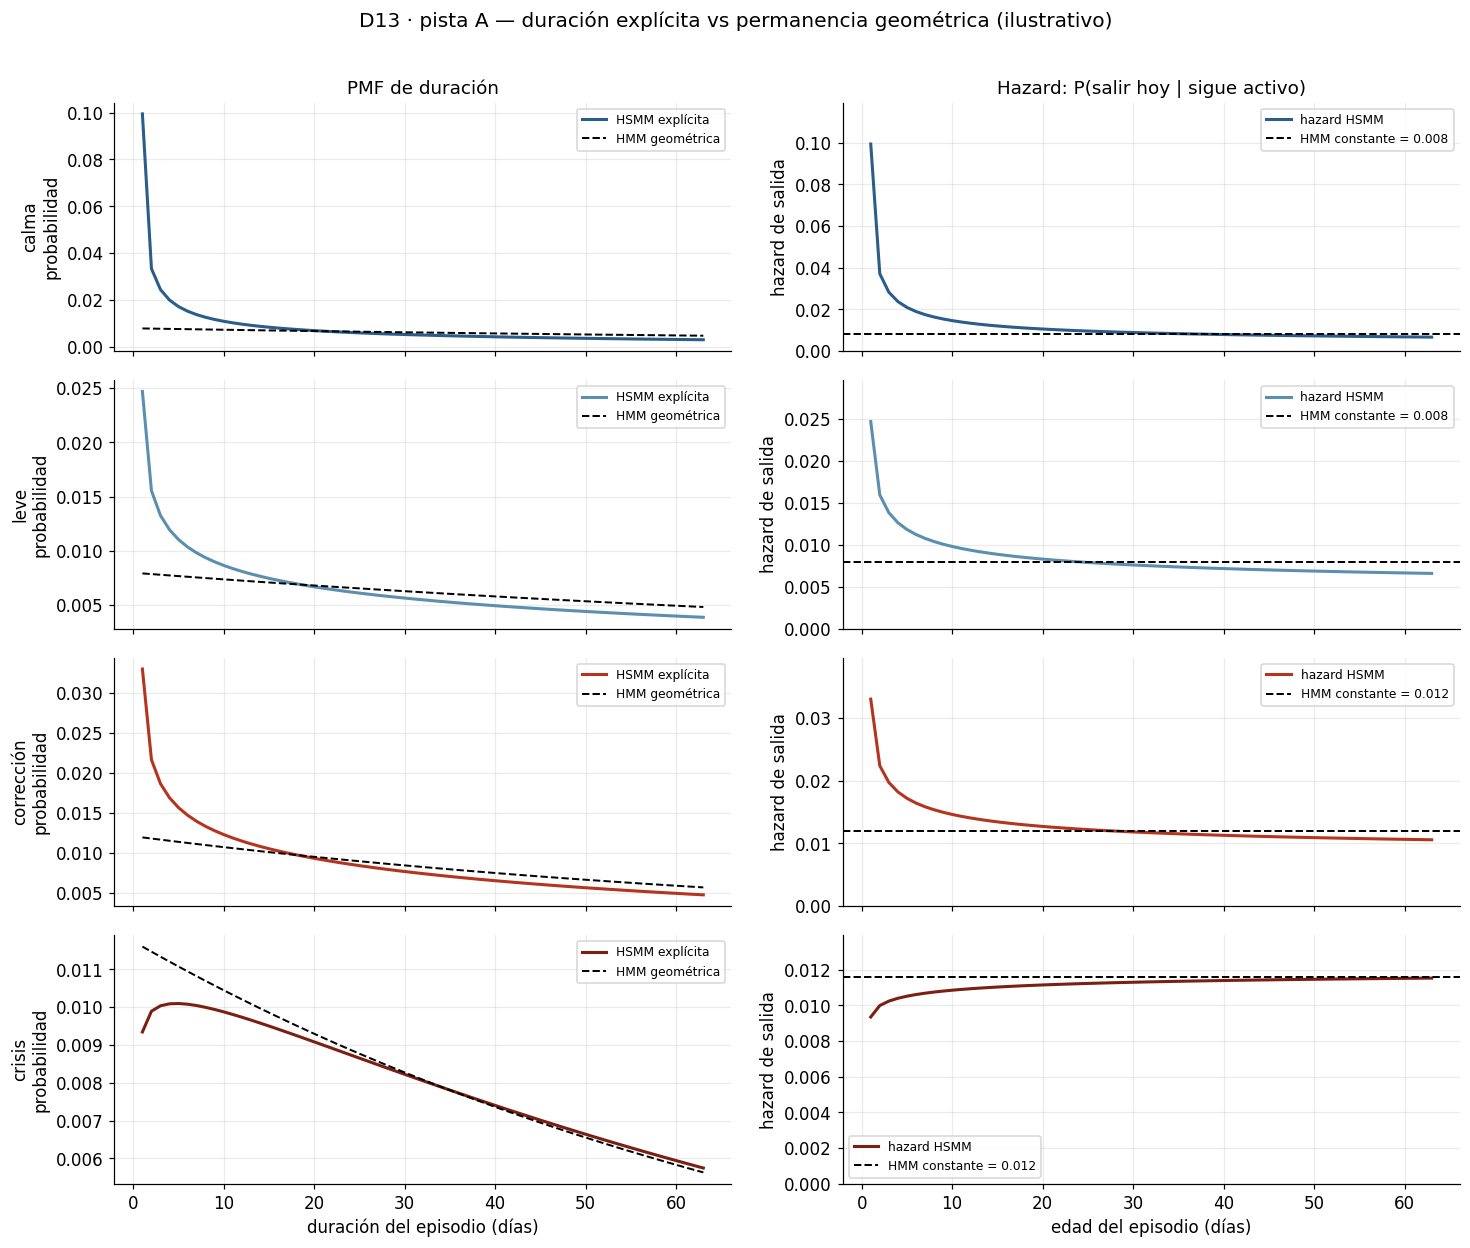

,shape_gamma,scale_gamma,mean_days,median_days,mode_days,media_geometrica_hmm
calma,0.42,326.31,63.35,53.0,126.0,126.00
leve,0.71,213.13,77.98,89.0,126.0,126.00
corrección,0.73,117.85,61.97,52.0,126.0,83.76
crisis,1.05,83.15,67.80,62.0,126.0,86.16


figura -> results/detectores/f3_hmm/D13_A_cadena_embebida.png


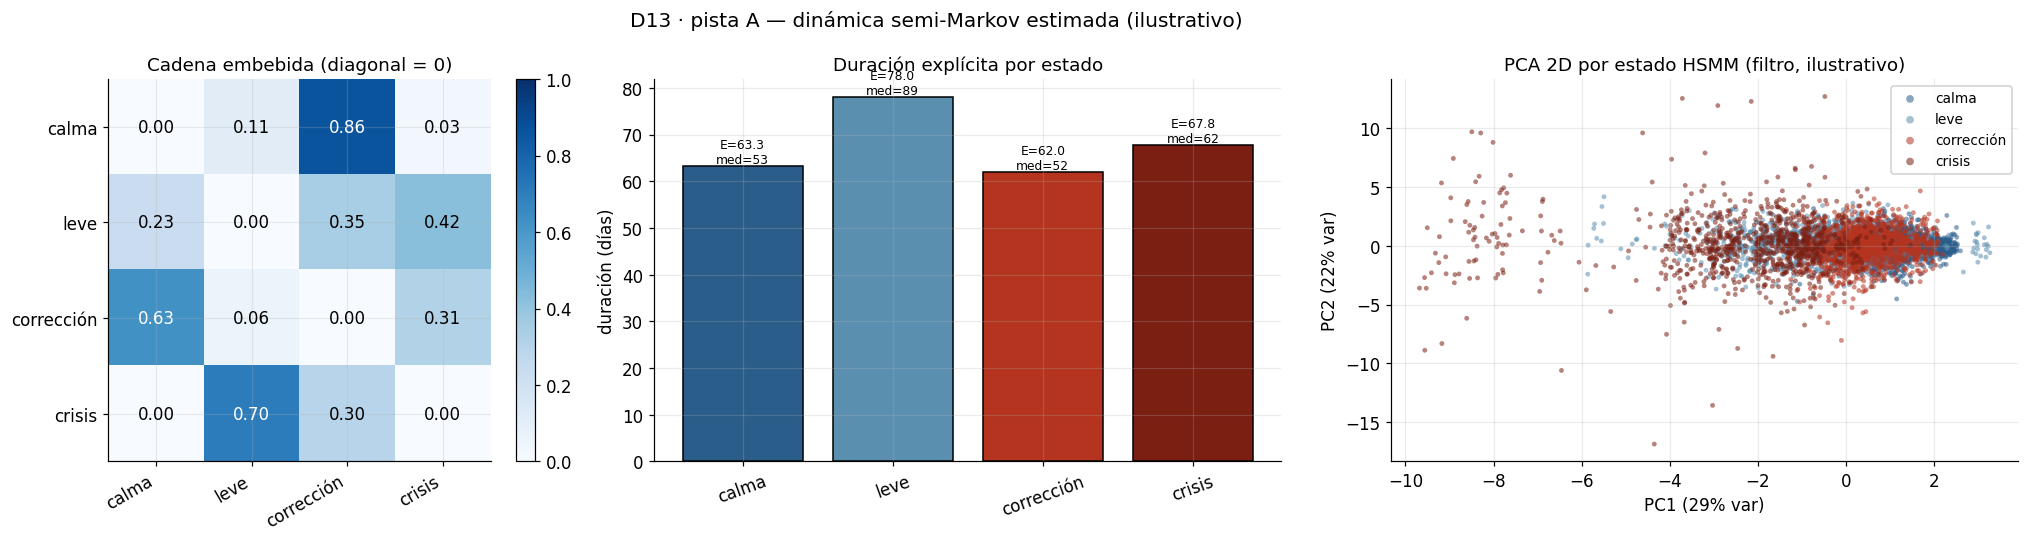

Pista A: BIC muestra completa D08 = 43,500 | D13 (aprox.) = 44,782 | Δ (D13 − D08) = +1,282


figura -> results/detectores/f3_hmm/D13_B_duraciones_explicitas.png


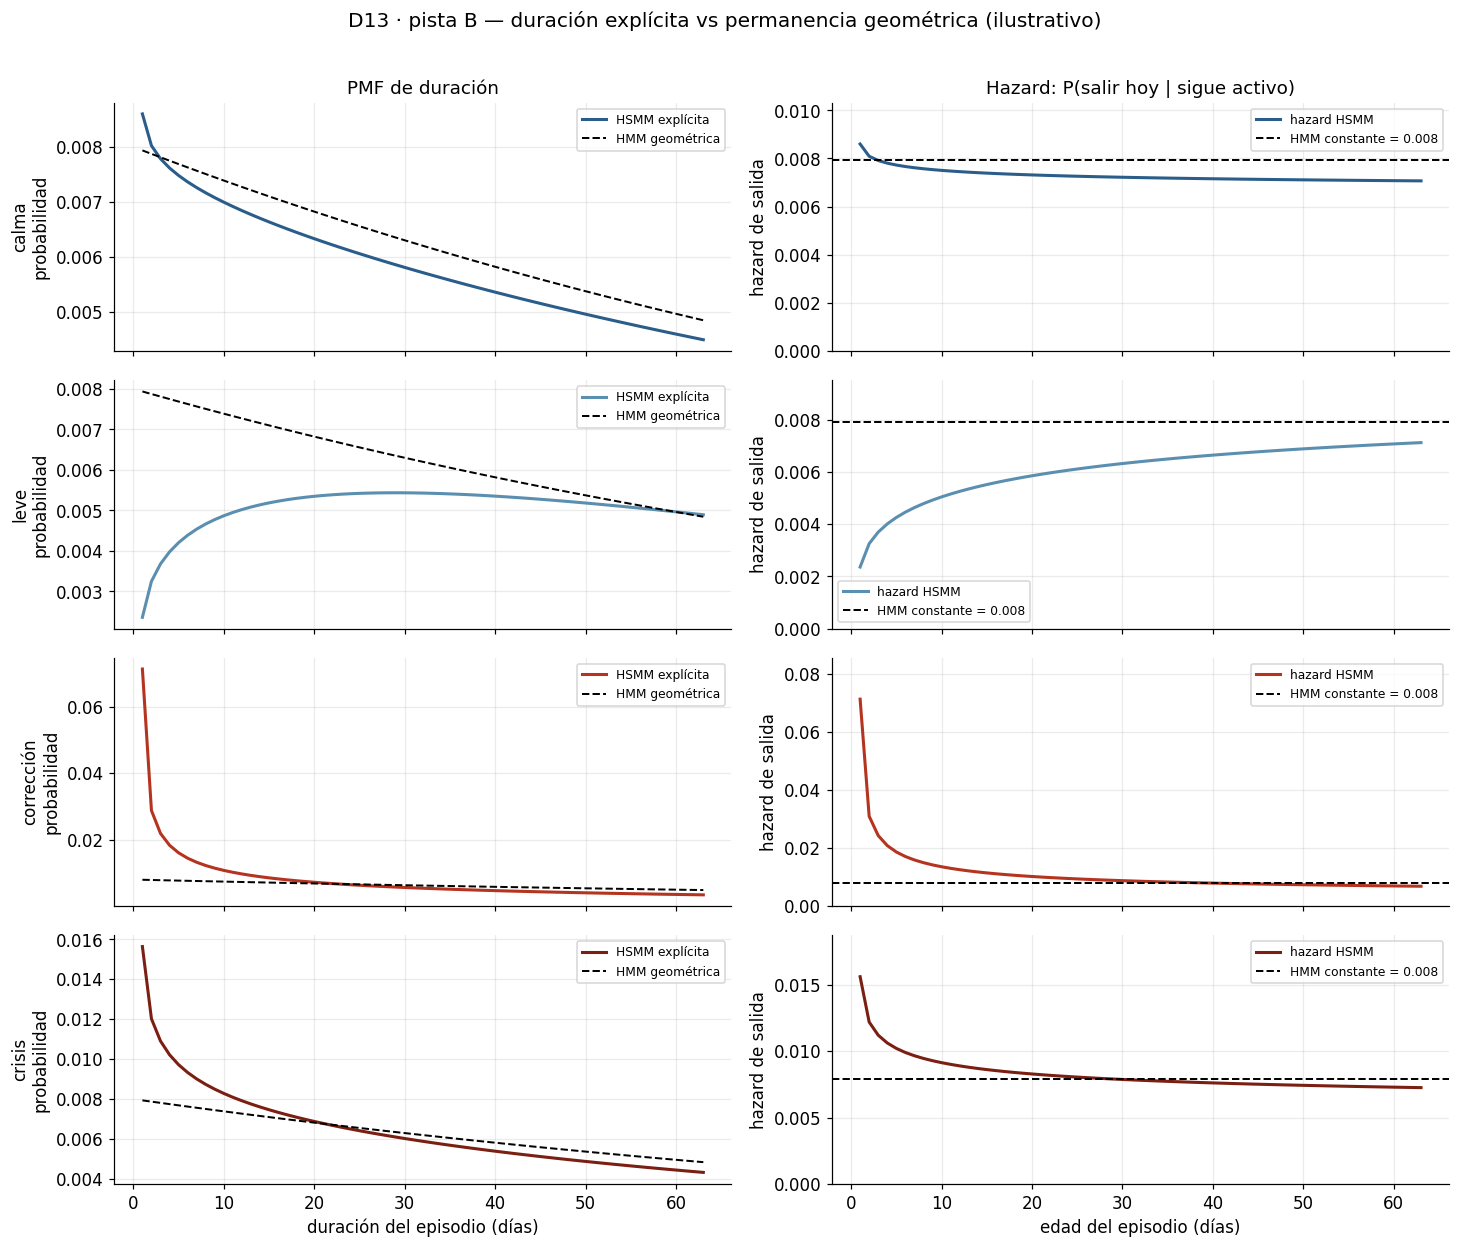

,shape_gamma,scale_gamma,mean_days,median_days,mode_days,media_geometrica_hmm
calma,0.96,147.41,82.62,96.0,126.0,126.0
leve,1.26,111.00,87.81,105.0,126.0,126.0
corrección,0.49,277.83,66.88,61.0,126.0,126.0
crisis,0.83,164.51,78.48,87.0,126.0,126.0


figura -> results/detectores/f3_hmm/D13_B_cadena_embebida.png


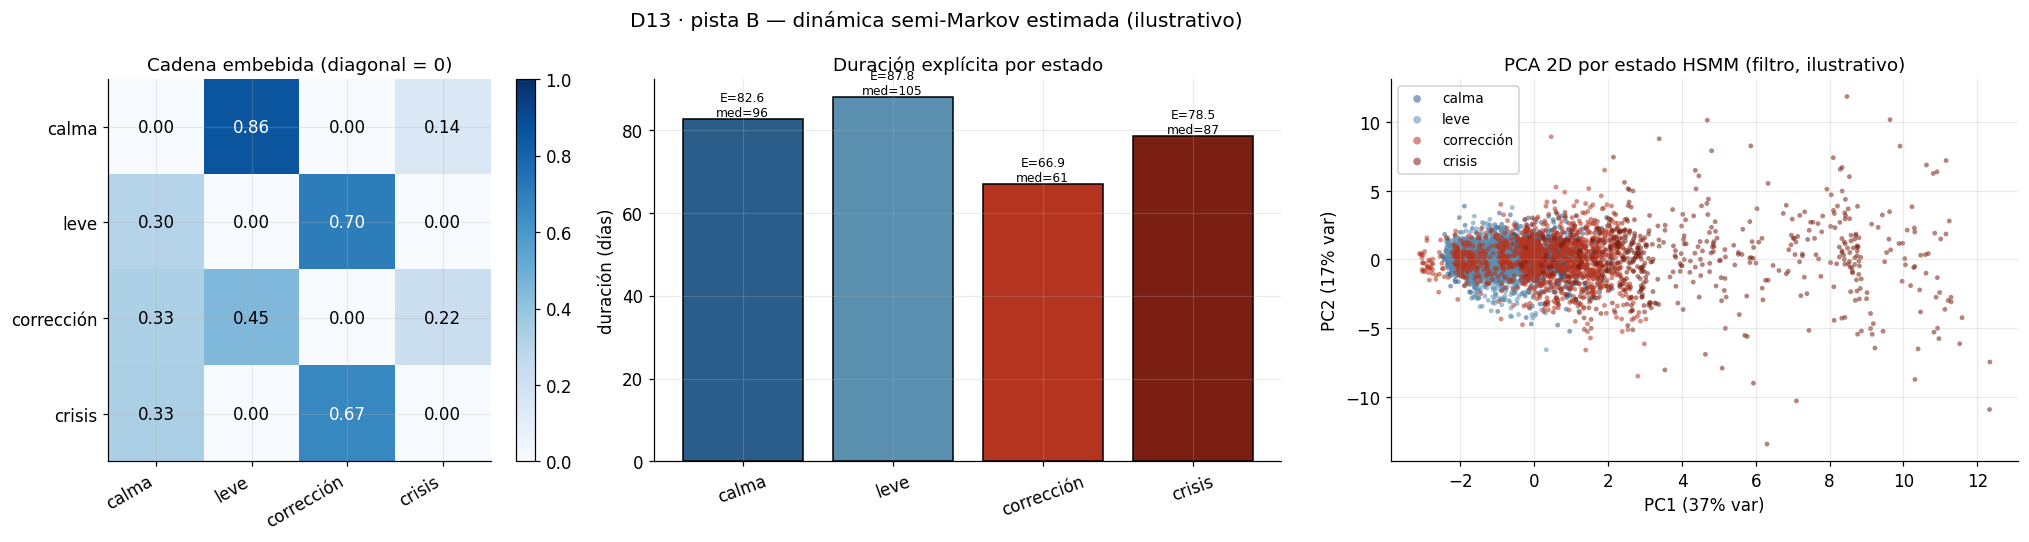

Pista B: BIC muestra completa D08 = 16,063 | D13 (aprox.) = 16,910 | Δ (D13 − D08) = +847


In [22]:
if DIAGNOSTICO_ILUSTRATIVO:
    for pista in PISTAS:
        det, X, ret = ajuste_muestra_completa(spec_d13(pista), pista)
        K = det.n_states
        dur = det.duration_parameters_canonical()
        q, h = det.duration_pmf_canonical(), det.duration_hazard_canonical()
        A_hmm, B = det.hmm_transition_canonical(), det.embedded_transition_canonical()
        dias = np.arange(1, det.max_duration + 1)
        ver = min(63, det.max_duration)
        fig, axes = plt.subplots(K, 2, figsize=(13.5, 2.8 * K), sharex='col')
        for s in range(K):
            color = viz.regime_color(s, K)
            p_salida = float(np.clip(1 - A_hmm[s, s], 1 / det.max_duration, 0.999))
            geom = p_salida * (1 - p_salida) ** (dias - 1)
            geom[-1] += max(0.0, 1.0 - geom.sum())
            axes[s, 0].plot(dias[:ver], q[s, :ver], color=color, lw=2.0, label='HSMM explícita')
            axes[s, 0].plot(dias[:ver], geom[:ver], color='black', ls='--', lw=1.3, label='HMM geométrica')
            axes[s, 0].set_ylabel(f'{ETIQUETAS[K][s]}\nprobabilidad')
            axes[s, 0].legend(fontsize=8)
            axes[s, 1].plot(dias[:ver], h[s, :ver], color=color, lw=2.0, label='hazard HSMM')
            axes[s, 1].axhline(p_salida, color='black', ls='--', lw=1.3, label=f'HMM constante = {p_salida:.3f}')
            axes[s, 1].set_ylabel('hazard de salida')
            axes[s, 1].set_ylim(0, min(1.0, 1.2 * max(float(np.nanmax(h[s, :ver])), p_salida)))
            axes[s, 1].legend(fontsize=8)
        axes[0, 0].set_title('PMF de duración')
        axes[0, 1].set_title('Hazard: P(salir hoy | sigue activo)')
        axes[-1, 0].set_xlabel('duración del episodio (días)')
        axes[-1, 1].set_xlabel('edad del episodio (días)')
        fig.suptitle(f'D13 · pista {pista} — duración explícita vs permanencia geométrica (ilustrativo)', y=1.01)
        fig.tight_layout()
        guardar(fig, f'D13_{pista}_duraciones_explicitas')
        plt.show()

        tabla_dur = dur[['shape_gamma', 'scale_gamma', 'mean_days', 'median_days', 'mode_days']].copy()
        tabla_dur['media_geometrica_hmm'] = [1 / max(1 - A_hmm[s, s], 1 / det.max_duration) for s in range(K)]
        tabla_dur.index = ETIQUETAS[K]
        display(tabla_dur.round(2))

        est_filt = pd.Series(det.predict_proba(X).argmax(axis=1), index=X.index)
        fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(20, 5))
        im = axA.imshow(B, cmap='Blues', vmin=0, vmax=1)
        axA.set_xticks(range(K))
        axA.set_xticklabels(ETIQUETAS[K], rotation=30, ha='right')
        axA.set_yticks(range(K))
        axA.set_yticklabels(ETIQUETAS[K])
        for i in range(K):
            for j in range(K):
                axA.text(j, i, f'{B[i, j]:.2f}', ha='center', va='center', color='white' if B[i, j] > 0.5 else 'black')
        axA.set_title('Cadena embebida (diagonal = 0)')
        fig.colorbar(im, ax=axA, fraction=0.046, pad=0.04)
        barras = axB.bar(range(K), dur['mean_days'], color=[viz.regime_color(s, K) for s in range(K)], edgecolor='black')
        for b, med in zip(barras, dur['median_days']):
            axB.text(b.get_x() + b.get_width() / 2, b.get_height(), f'E={b.get_height():.1f}\nmed={med:.0f}',
                     ha='center', va='bottom', fontsize=8)
        axB.set_xticks(range(K))
        axB.set_xticklabels(ETIQUETAS[K], rotation=20)
        axB.set_ylabel('duración (días)')
        axB.set_title('Duración explícita por estado')
        viz.plot_feature_space_scatter(X[det._used_features], est_filt, use_pca=True, crisis_state=det.crisis_state,
                                       labels=ETIQUETAS[K], ax=axC, title='PCA 2D por estado HSMM (filtro, ilustrativo)')
        fig.suptitle(f'D13 · pista {pista} — dinámica semi-Markov estimada (ilustrativo)')
        fig.tight_layout()
        guardar(fig, f'D13_{pista}_cadena_embebida')
        plt.show()
        if ('D08', pista) in DIAG:
            bic08 = DIAG[('D08', pista)]['det'].bic(X)
            print(f'Pista {pista}: BIC muestra completa D08 = {bic08:,.0f} | D13 (aprox.) = {det.bic(X):,.0f} '
                  f'| Δ (D13 − D08) = {det.bic(X) - bic08:+,.0f}')
else:
    print('Diagnóstico ilustrativo desactivado (DIAGNOSTICO_ILUSTRATIVO = False).')

<a id="s5"></a>
## 5. Comparación intra-familia

D04 y D08 comparten motor (cadena de Markov latente con filtrado forward), features de entrada
(`CORE_A`/`CORE_B`), rejilla OOS y juez; difieren en la **emisión** (gaussiana frente a t), en el
**número de estados** y en la **frecuencia de re-ajuste**. La comparación se hace en cuatro
planos: (1) ranking de detección ADR-003 y métricas de comportamiento; (2) detección evento a
evento; (3) acuerdo día a día entre sus señales de crisis; (4) bondad de ajuste estadístico
(BIC sobre los mismos datos, ajuste final del benchmark), que en la v1 fue el gran argumento a
favor de D08 y que **no tiene por qué** coincidir con la utilidad para detectar crisis.

pista                               A                                 B                 
id                                D08              D04              D04              D08
detector              hmm_tstudent_4s  hmm_gaussian_2s  hmm_gaussian_2s  hmm_tstudent_4s
puesto_deteccion                    9               10                5                9
nivel_etiqueta               elegible         elegible         elegible         elegible
score_deteccion              0.467033           0.4549         0.497309         0.274436
det_event_recall             0.823529              1.0         0.777778         0.333333
det_n_detectados                   14               17                7                3
det_n_eventos                      17               17                9                9
det_precision                0.325939         0.294414         0.365506         0.233227
det_lift_precision           1.680587         1.518044         2.116391         1.350453
det_marked_rate              0.373169         0.561169         0.155703         0.077113
mean_crisis_coverage          0.55369          0.78827         0.370214         0.080638
false_alarm_rate             0.674061         0.705586         0.634494         0.766773
mean_trap_activation              0.0         0.036842              0.0              0.0
switching_rate               0.015708         0.016203         0.012318         0.017738
mean_regime_duration        63.376682        61.447826        79.588235         55.60274
label_stability              0.773455         0.978529         0.966198         0.663814
elapsed_seconds           1776.028744      6562.037653       781.432129       176.686864
n_states                            4                2                2                4
log_likelihood           -20611.34018    -46023.095942    -19107.506283     -5932.700799
aic                       41692.68036     92268.191883     38697.012567     12855.401598
bic                       43499.73951     93121.738972     40258.569976     16062.749804

figura -> results/detectores/f3_hmm/F3_comparativa_intra_familia.png


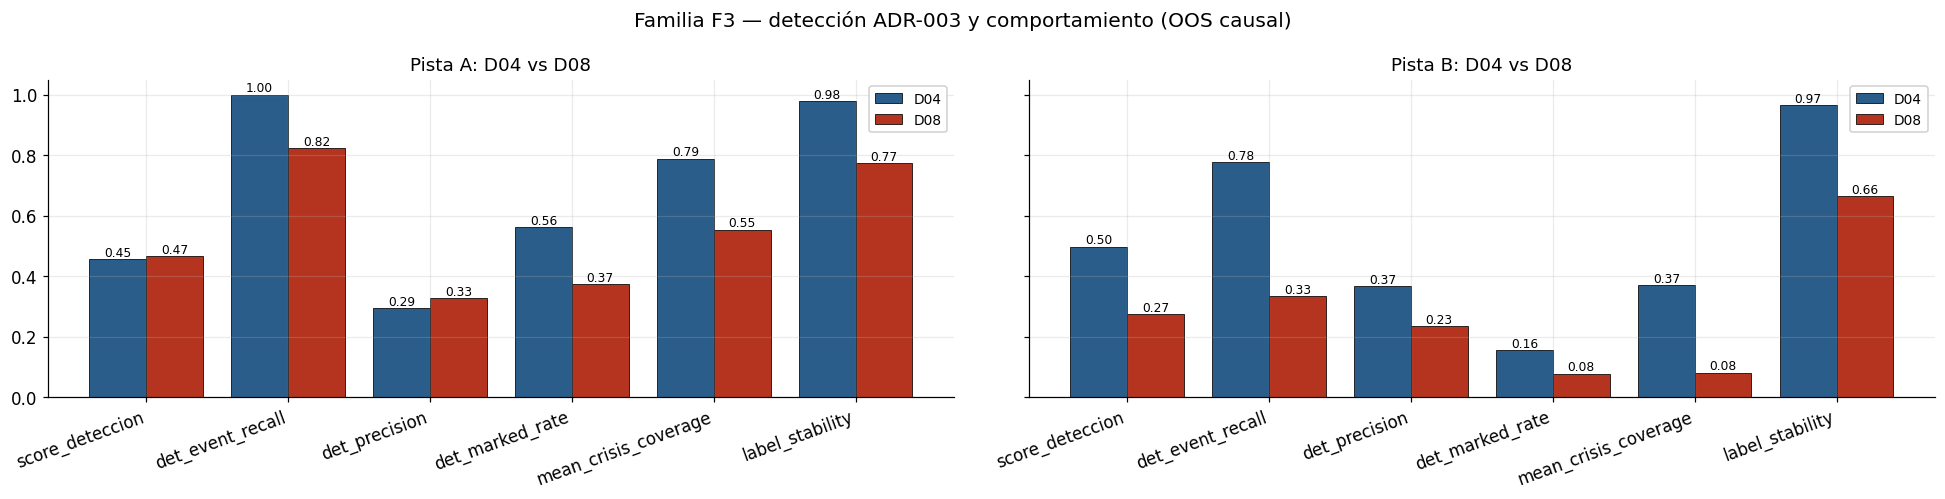

Pista A: D04 puesto 10/12 (score 0.455) | D08 puesto 9/12 (score 0.467) | líder de la pista: D10 turbulence_mahalanobis (score 0.614)
Pista B: D04 puesto 5/12 (score 0.497) | D08 puesto 9/12 (score 0.274) | líder de la pista: D05 markov_switching_var_2s (score 0.647)


In [23]:
COLS = ['pista', 'id', 'detector', 'puesto_deteccion', 'nivel_etiqueta', 'score_deteccion', 'det_event_recall',
        'det_n_detectados', 'det_n_eventos', 'det_precision', 'det_lift_precision', 'det_marked_rate',
        'mean_crisis_coverage', 'false_alarm_rate', 'mean_trap_activation', 'switching_rate',
        'mean_regime_duration', 'label_stability', 'elapsed_seconds']
INTRA = (RANKING[RANKING['id'].isin(DETECTORES)][COLS]
         .merge(METRICAS.reset_index()[['pista', 'id', 'n_states', 'log_likelihood', 'aic', 'bic']],
                on=['pista', 'id'])
         .set_index(['pista', 'id']))
display(INTRA.T)

metricas_graf = ['score_deteccion', 'det_event_recall', 'det_precision', 'det_marked_rate',
                 'mean_crisis_coverage', 'label_stability']
fig, axes = plt.subplots(1, 2, figsize=(18, 4.6), sharey=True)
for ax, pista in zip(axes, PISTAS):
    series = {det: [float(INTRA.loc[(pista, det), c]) for c in metricas_graf] for det in DETECTORES}
    viz.plot_grouped_bars(metricas_graf, series, ax=ax, rotation=20, value_labels=True,
                          colors=[viz.C_LONG, viz.C_CRISIS], title=f'Pista {pista}: D04 vs D08')
fig.suptitle('Familia F3 — detección ADR-003 y comportamiento (OOS causal)')
fig.tight_layout()
guardar(fig, 'F3_comparativa_intra_familia')
plt.show()
for pista in PISTAS:
    n_pista = int((RANKING['pista'] == pista).sum())
    lider = RANKING[RANKING['pista'] == pista].sort_values('puesto_deteccion').iloc[0]
    print(f'Pista {pista}: D04 puesto {int(INTRA.loc[(pista, "D04"), "puesto_deteccion"])}/{n_pista} '
          f'(score {INTRA.loc[(pista, "D04"), "score_deteccion"]:.3f}) | D08 puesto '
          f'{int(INTRA.loc[(pista, "D08"), "puesto_deteccion"])}/{n_pista} '
          f'(score {INTRA.loc[(pista, "D08"), "score_deteccion"]:.3f}) | líder de la pista: {lider["id"]} '
          f'{lider["detector"]} (score {lider["score_deteccion"]:.3f})')

,D04_detectada,D08_detectada,D04_cobertura,D08_cobertura,D08_corr+crisis
crisis,,,,,
bear_1969_70,1.0,0.0,1.000,0.000,0.000
oil_stagflation_1973,1.0,1.0,0.815,0.499,0.545
volcker_1980_82,1.0,1.0,0.898,0.893,0.998
black_monday_1987,1.0,1.0,1.000,0.431,0.472
gulf_war_sl_1990,1.0,1.0,0.746,0.651,0.651
ltcm_russia_1998,1.0,1.0,0.719,1.000,1.000
dotcom_2000_02,1.0,1.0,0.961,0.665,0.868
gfc_2007_09,1.0,1.0,0.955,0.615,0.983
flash_crash_euro1_2010,1.0,1.0,1.000,0.780,0.780


Pista A: eventos que solo detecta D04 = ['bear_1969_70', 'volmageddon_2018q1', 'fed_tightening_2018q4'] | solo D08 = []
  días en crisis: D04 = 56.1% | D08 crisis = 37.3% | D08 corr+crisis = 54.9%
  Jaccard crisis D04 vs D08 = 0.455 | vs D08 corr+crisis = 0.540 | acuerdo diario = 66.8%


figura -> results/detectores/f3_hmm/F3_comparativa_A_p_crisis_D04_vs_D08.png


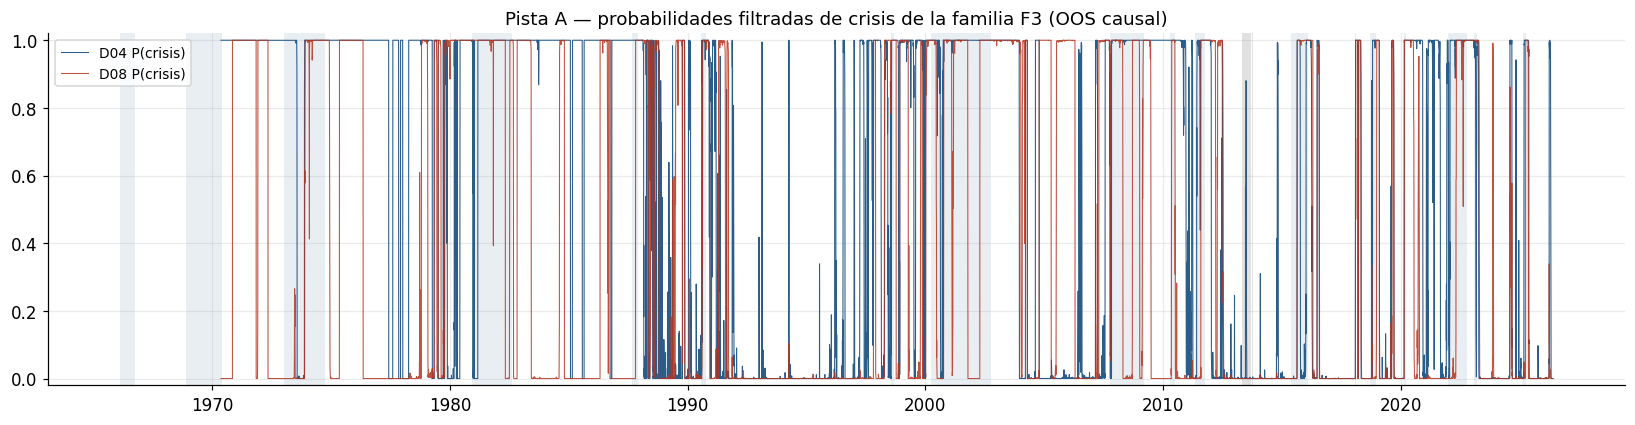

,D04_detectada,D08_detectada,D04_cobertura,D08_cobertura,D08_corr+crisis
crisis,,,,,
flash_crash_euro1_2010,0.0,0.0,0.000,0.020,0.020
us_downgrade_euro2_2011,1.0,0.0,0.165,0.000,0.000
china_oil_2015_16,1.0,1.0,0.049,0.152,0.179
volmageddon_2018q1,1.0,0.0,0.400,0.000,0.000
fed_tightening_2018q4,0.0,0.0,0.015,0.000,0.273
covid_2020,1.0,1.0,0.833,0.375,0.833
inflation_bear_2022,1.0,1.0,0.755,0.179,0.765
svb_banking_2023,1.0,0.0,1.000,0.000,0.000
tariff_selloff_2025,1.0,0.0,0.114,0.000,1.000


Pista B: eventos que solo detecta D04 = ['us_downgrade_euro2_2011', 'volmageddon_2018q1', 'svb_banking_2023', 'tariff_selloff_2025'] | solo D08 = []
  días en crisis: D04 = 15.6% | D08 crisis = 7.7% | D08 corr+crisis = 36.0%
  Jaccard crisis D04 vs D08 = 0.140 | vs D08 corr+crisis = 0.234 | acuerdo diario = 68.0%


figura -> results/detectores/f3_hmm/F3_comparativa_B_p_crisis_D04_vs_D08.png


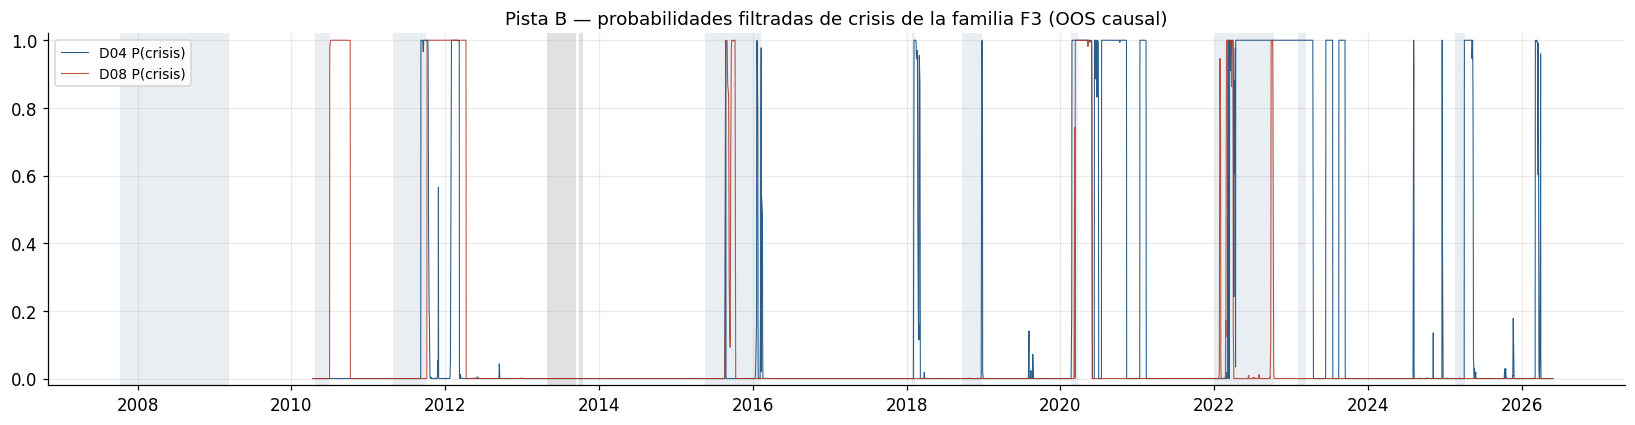

In [24]:
# Detección evento a evento, cobertura y acuerdo día a día entre las señales de crisis.
for pista in PISTAS:
    c4, c8 = COBERTURAS[(pista, 'D04')], COBERTURAS[(pista, 'D08')]
    eventos = pd.DataFrame({
        'D04_detectada': c4['detectada'], 'D08_detectada': c8['detectada'],
        'D04_cobertura': c4['cobertura'], 'D08_cobertura': c8['cobertura'], 'D08_corr+crisis': c8['corr+crisis'],
    })
    display(eventos.round(3))
    solo4 = eventos.index[(eventos['D04_detectada'] == 1) & (eventos['D08_detectada'] == 0)].tolist()
    solo8 = eventos.index[(eventos['D08_detectada'] == 1) & (eventos['D04_detectada'] == 0)].tolist()
    print(f'Pista {pista}: eventos que solo detecta D04 = {solo4} | solo D08 = {solo8}')

    k4, k8 = int(fila(pista, 'D04')['n_states']), int(fila(pista, 'D08')['n_states'])
    e4 = PANELES[(pista, 'D04')]['state'].astype(int).eq(k4 - 1)
    e8 = PANELES[(pista, 'D08')]['state'].astype(int).eq(k8 - 1)
    e8a = PANELES[(pista, 'D08')]['state'].astype(int).ge(k8 - 2)
    idx = e4.index.intersection(e8.index)
    e4, e8, e8a = e4.loc[idx], e8.loc[idx], e8a.loc[idx]
    jac = lambda a, b: float((a & b).sum() / max(int((a | b).sum()), 1))
    print(f'  días en crisis: D04 = {e4.mean():.1%} | D08 crisis = {e8.mean():.1%} | D08 corr+crisis = {e8a.mean():.1%}')
    print(f'  Jaccard crisis D04 vs D08 = {jac(e4, e8):.3f} | vs D08 corr+crisis = {jac(e4, e8a):.3f} | '
          f'acuerdo diario = {(e4 == e8a).mean():.1%}')

    configure_evaluation(pista)
    fig, ax = plt.subplots(figsize=(15, 4))
    ax.plot(PANELES[(pista, 'D04')]['p_crisis'], color=viz.C_LONG, lw=0.7, label='D04 P(crisis)')
    ax.plot(PANELES[(pista, 'D08')]['p_crisis'], color=viz.C_CRISIS, lw=0.7, alpha=0.85, label='D08 P(crisis)')
    franjas_eventos(ax, pista)
    ax.set_ylim(-0.02, 1.02)
    ax.legend(loc='upper left', fontsize=9)
    ax.set_title(f'Pista {pista} — probabilidades filtradas de crisis de la familia F3 (OOS causal)')
    fig.tight_layout()
    guardar(fig, f'F3_comparativa_{pista}_p_crisis_D04_vs_D08')
    plt.show()

In [25]:
# Bondad de ajuste: mismo X por pista (núcleo común), ajuste final del benchmark.
# OJO: D04 y D08 difieren en la emisión (gaussiana vs t) Y en el número de estados K, así que el
# ΔBIC compara modelos completos; no aísla el efecto de la t (haría falta un HMM gaussiano con el
# mismo K que D08, o un HMM-t con el K de D04).
for pista in PISTAS:
    b4, b8 = float(INTRA.loc[(pista, 'D04'), 'bic']), float(INTRA.loc[(pista, 'D08'), 'bic'])
    l4, l8 = float(INTRA.loc[(pista, 'D04'), 'log_likelihood']), float(INTRA.loc[(pista, 'D08'), 'log_likelihood'])
    k4, k8 = int(INTRA.loc[(pista, 'D04'), 'n_states']), int(INTRA.loc[(pista, 'D08'), 'n_states'])
    print(f'Pista {pista}: logL D04 (gaussiano, K={k4}) = {l4:,.0f} | D08 (t, K={k8}) = {l8:,.0f} | '
          f'BIC D04 = {b4:,.0f} | D08 = {b8:,.0f} | ΔBIC (D04 − D08) = {b4 - b8:+,.0f} -> '
          + ('el modelo D08 completo (t + K distinto) ajusta mejor' if b4 > b8
             else 'el modelo D08 completo no mejora el ajuste')
          + ' (efecto conjunto de emisión y K)')

Pista A: logL D04 (gaussiano, K=2) = -46,023 | D08 (t, K=4) = -20,611 | BIC D04 = 93,122 | D08 = 43,500 | ΔBIC (D04 − D08) = +49,622 -> el modelo D08 completo (t + K distinto) ajusta mejor (efecto conjunto de emisión y K)
Pista B: logL D04 (gaussiano, K=2) = -19,108 | D08 (t, K=4) = -5,933 | BIC D04 = 40,259 | D08 = 16,063 | ΔBIC (D04 − D08) = +24,196 -> el modelo D08 completo (t + K distinto) ajusta mejor (efecto conjunto de emisión y K)


<a id="s6"></a>
## 6. Hallazgos de la Capa 1 (v1) y qué se mantiene / cambia en v2

La Capa 1 evaluó la familia con las **features puente** de la tarea previa, una única ventana
limitada por la serie más corta del panel puente (HYG), un train inicial fijo y un catálogo
reducido de crisis y trampas (la configuración exacta se tabula más abajo). Las cifras v1 se leen de los CSV congelados en
`docs/historia/capa1/resultados/` (tag `capa1-final`).

**Hipótesis del CHECKPOINT 2 y veredictos v1.**

- **D4.** *«Captará 2008 y 2020; fallará 2013 y 2018; la versión in-sample es NO causal.»* Se
  cumplió con un matiz: 2008 y 2011 caían en el train y no eran evaluables OOS. Hallazgo clave: en
  las crisis OOS grandes y persistentes la cobertura **no cayó** al pasar de in-sample a causal —
  el acierto no era un artefacto del *look-ahead*; lo que el suavizado aportaba era la *suavidad*
  del recorrido—. Además, el filtrado forward resultó más estable que el Viterbi por bloques.
- **D8.** *«Emisiones t + más estados atacan las colas y potencialmente captan 2013/2018; riesgo de
  sobreajuste.»* Se cumplió a medias: el problema **distribucional** quedó resuelto (BIC mucho
  mejor que D4 pese a más parámetros, `ν` decreciente hacia la crisis, severidad monótona también
  en walk-forward), pero 2013 siguió invisible porque fue un shock de tipos con renta variable casi
  plana: un límite de **cobertura de features**, no del modelo de emisión. 2018 se captaba como
  *corrección*. Con el `K` elegido el estado de crisis es la cola extrema; hay que leer corrección + crisis.
  *(Lectura v1. En v2 el taper de 2013 es una **trampa**: no activarse en él es el comportamiento
  correcto, no un punto ciego; y que la crisis sea la cola extrema y estrecha depende de la pista
  (§1.3, §4.6). Veredicto v2 en §6.1.)*
- **D13.** La duración explícita no mejoró la dinámica (§4.7.1); D8 se mantuvo por parsimonia.
  Es la **única evidencia** disponible sobre D13: la re-ejecución v2 (§4.7.2) es opcional y no se
  ha hecho.

In [26]:
V1 = pd.DataFrame({
    'D4 causal (v1)': pd.read_csv(ruta_historia_v1('metrics_04_hmm_gaussian_2s.csv')).iloc[0],
    'D4 in-sample NO causal (v1)': pd.read_csv(ruta_historia_v1('metrics_04_hmm_gaussian_2s_insample.csv')).iloc[0],
    'D8 causal (v1)': pd.read_csv(ruta_historia_v1('metrics_08_hmm_tstudent.csv')).iloc[0],
})
filas_v1 = (['detector', 'n_states', 'ventana_eval', 'false_alarm_rate', 'switching_rate', 'mean_regime_duration',
             'label_stability', 'log_likelihood', 'bic']
            + [i for i in V1.index if str(i).startswith(('cov_', 'fa_', 'leadlag_')) and not str(i).endswith(('_lo', '_hi'))])
display(V1.loc[[f for f in filas_v1 if f in V1.index]])

d4c, d4i, d8c = V1['D4 causal (v1)'], V1['D4 in-sample NO causal (v1)'], V1['D8 causal (v1)']
print(f'v1 · ΔBIC (D4 − D8) = {float(d4c["bic"]) - float(d8c["bic"]):+,.0f} '
      f'(D4 K={int(float(d4c["n_states"]))}, D8 K={int(float(d8c["n_states"]))})')
print(f'v1 · switching D4 in-sample = {float(d4i["switching_rate"]):.4f} vs causal = {float(d4c["switching_rate"]):.4f}; '
      f'duración media {float(d4i["mean_regime_duration"]):.1f} vs {float(d4c["mean_regime_duration"]):.1f} días')
for c in [i for i in V1.index if str(i).startswith(('cov_', 'fa_')) and not str(i).endswith(('_lo', '_hi'))]:
    ins, cau = pd.to_numeric(d4i[c], errors='coerce'), pd.to_numeric(d4c[c], errors='coerce')
    print(f'  D4 {c}: in-sample = {ins:.3f} | causal = ' + ('NaN (en train)' if pd.isna(cau) else f'{cau:.3f} | Δ = {cau - ins:+.3f}'))

,D4 causal (v1),D4 in-sample NO causal (v1),D8 causal (v1)
detector,hmm_gaussian_2s,hmm_gaussian_2s_INSAMPLE_noncausal,hmm_tstudent_4s
n_states,2,2,4
ventana_eval,2012-07-20→2026-06-12 (n=3405),2007-07-06→2026-06-12 (n=4665),2012-07-20→2026-06-12 (n=3405)
false_alarm_rate,0.731361,0.70763,0.518868
switching_rate,0.100441,0.046945,0.051982
mean_regime_duration,9.927114,21.204545,19.129213
label_stability,0.993827,NaN,0.876837
log_likelihood,-17381.357597,-17381.357597,-11536.339896
bic,35379.407741,35379.407741,24415.886847
cov_GFC_2008,NaN,1.0,NaN


v1 · ΔBIC (D4 − D8) = +10,964 (D4 K=2, D8 K=4)
v1 · switching D4 in-sample = 0.0469 vs causal = 0.1004; duración media 21.2 vs 9.9 días
  D4 cov_GFC_2008: in-sample = 1.000 | causal = NaN (en train)
  D4 cov_EuroDebt_2011: in-sample = 0.810 | causal = NaN (en train)
  D4 cov_COVID_2020: in-sample = 0.960 | causal = 0.960 | Δ = +0.000
  D4 cov_Inflation_2022: in-sample = 0.827 | causal = 0.861 | Δ = +0.034
  D4 fa_TaperTantrum_2013: in-sample = 0.120 | causal = 0.250 | Δ = +0.130
  D4 fa_Selloff_Q4_2018: in-sample = 0.305 | causal = 0.458 | Δ = +0.153


**Qué se mantiene en v2.** El motor y las implementaciones (los mismos módulos de la Capa 1,
hoy en `regimenes.detectores.f3_hmm`, con la misma lógica), el **filtrado forward causal** con *burn-in*,
el etiquetado económico por volatilidad, las semillas, la elección t-Student frente a GMM-HMM, el
`K` de D08 que eligió el BIC en la v1 y su re-ajuste semestral, y el estatus de D13 como ablación
fuera de la matriz oficial.

**Qué cambia en v2** (tabla generada en la celda siguiente):

- **Features:** de las features puente de la tarea previa al núcleo `CORE_A` / `CORE_B` del
  diseño de preprocesado v2, común a todos los detectores multivariantes de la pista.
- **Ventanas y catálogo:** dos pistas congeladas en `configs/benchmark_spec.yaml`; la pista A
  arranca décadas antes y convierte en OOS crisis que la v1 no podía evaluar (GFC incluida); la B
  replica la era moderna con VIX/MOVE/crédito.
- **Juez:** de la cobertura media sobre cuatro crisis a la **detección por evento ADR-003**
  (recall de eventos, precisión con lift sobre la tasa base, niveles de elegibilidad), con
  trampas y *switching* como filtros.
- **Train inicial:** fijado por pista (no por detector) para que los doce detectores compartan
  exactamente las mismas fechas OOS.

In [27]:
# Configuración v1 declarada en los notebooks v1 04 y 08 (tag git capa1-final) frente a v2 (registro).
from regimenes.detectores.f3_hmm.hmm_gaussian_2s import BRIDGE_FEATURES

V1_CONFIG = {'D04': {'train_inicial_dias': 252 * 5, 'step': 21, 'K': '2'},
             'D08': {'train_inicial_dias': 252 * 5, 'step': 126, 'K': '3 o 4 por BIC -> 4'}}
filas = []
for det in DETECTORES:
    filas.append({'id': det, 'versión': 'v1', 'features': ', '.join(BRIDGE_FEATURES), 'n_features': len(BRIDGE_FEATURES),
                  'K': V1_CONFIG[det]['K'], 'step': V1_CONFIG[det]['step'],
                  'train_inicial_dias': V1_CONFIG[det]['train_inicial_dias'],
                  'ventana_oos': V1[f'{"D4" if det == "D04" else "D8"} causal (v1)']['ventana_eval']})
    for pista in PISTAS:
        s = spec_de(pista, det)
        filas.append({'id': det, 'versión': f'v2 pista {pista}', 'features': ', '.join(s.features),
                      'n_features': len(s.features), 'K': str(s.params['n_states']), 'step': s.step,
                      'train_inicial_dias': DEFAULT_TRAIN_DAYS[pista], 'ventana_oos': fila(pista, det)['ventana_eval']})
display(pd.DataFrame(filas).set_index(['id', 'versión']))
for pista in PISTAS:
    print(f'Pista {pista}: {int(fila(pista, "D04")["det_n_eventos"])} crisis evaluables OOS en v2 '
          f'frente a las {sum(1 for c in V1.index if str(c).startswith("cov_") and not str(c).endswith(("_lo", "_hi")))} '
          f'ventanas de crisis del catálogo v1.')

features  n_features                   K  step  train_inicial_dias                      ventana_oos
id  versión                                                                                                                                                 
D04 v1          SP500_ret_z, TLT_ret_z, IEF_ret_z, HYG_ret_z, ...           7                   2    21                1260   2012-07-20→2026-06-12 (n=3405)
    v2 pista A  SP500_ret_z, SP500_vol_z, SP500_momentum, SP50...           9                   2    21                2016  1970-05-12→2026-05-29 (n=14133)
    v2 pista B  SP500_ret_z, SP500_vol_z, SP500_momentum, SP50...          14                   2    21                 756   2010-04-12→2026-05-29 (n=4059)
D08 v1          SP500_ret_z, TLT_ret_z, IEF_ret_z, HYG_ret_z, ...           7  3 o 4 por BIC -> 4   126                1260   2012-07-20→2026-06-12 (n=3405)
    v2 pista A  SP500_ret_z, SP500_vol_z, SP500_momentum, SP50...           9                   4   126                2016  1970-05-12→2026-05-29 (n=14133)
    v2 pista B  SP500_ret_z, SP500_vol_z, SP500_momentum, SP50...          14                   4   126                 756   2010-04-12→2026-05-29 (n=4059)

Pista A: 17 crisis evaluables OOS en v2 frente a las 4 ventanas de crisis del catálogo v1.
Pista B: 9 crisis evaluables OOS en v2 frente a las 4 ventanas de crisis del catálogo v1.


<a id="s6-cp2"></a>
### 6.1 Hipótesis del CHECKPOINT 2 y veredicto (v1 → v2)

Las hipótesis y los veredictos v1 están arriba (§6). La celda siguiente da el **veredicto v2**
de cada parte con las cifras vigentes (caché verificada, ranking ADR-003 y diagnósticos de §4):

- **D04** — *«captará 2008 y 2020; fallará 2013 y 2018; la versión in-sample es NO causal»*:
  detección por evento de la GFC y del COVID; activación en el *taper* de 2013, que en v2 es una
  **trampa** (no activarse es el comportamiento correcto, no un fallo); detección de Q4-2018, que
  en v2 es **crisis** (detectarla contradice el «fallará 2018» de v1, pero es un acierto); y el
  experimento puente de §4.3 (cobertura causal frente a in-sample), que contrasta el hallazgo v1
  «el protocolo causal no destruye la detección de las crisis grandes y persistentes, solo la
  suavidad del recorrido».
- **D08** — *«emisiones t + más estados atacan las colas y potencialmente captan 2013/2018;
  riesgo de sobreajuste»*: ΔBIC frente a D04 (que mezcla la t con el cambio de $K$), monotonía
  de la severidad fuera de muestra (§4.6), trampa del *taper*, Q4-2018 y dos síntomas de
  sobreajuste o inestabilidad: estabilidad de etiquetas entre refits y score de detección frente a
  D04. Se contrasta además el hallazgo v1 «con `K > 2` la crisis es la cola más extrema y
  estrecha» con el tamaño, la volatilidad y el retorno OOS del estado de crisis (§4.6).
- **D13** (ablación): solo hay evidencia **v1** (§4.7.1); sin re-ejecución v2 (§4.7.2) no hay
  veredicto v2.

In [28]:
# Veredicto v2 por hipótesis del CHECKPOINT 2. Cifras: METRICAS (caché verificada), RANKING (ADR-003),
# PUENTE_D04 (§4.3), SEVERIDAD (§4.6) e INTRA (§5).
pct = lambda x: 'fuera del OOS' if pd.isna(x) else f'{100 * float(x):.0f} %'
evento = lambda x: 'fuera del OOS' if pd.isna(x) else ('detectada' if float(x) == 1 else 'no detectada')
det_ev = lambda pista, d, c: pd.to_numeric(fila(pista, d).get(f'det_ev_{c}', np.nan), errors='coerce')
UMBRAL_TRAMPA = 0.10     # activación < 10 % en una trampa = no se dispara de forma sostenida
UMBRAL_PERDIDA = -0.10   # delta causal − in-sample por debajo = pérdida de cobertura notable
lineas = []
for pista in PISTAS:
    m4, m8 = fila(pista, 'D04'), fila(pista, 'D08')
    # D04 — «captará 2008 y 2020; fallará 2013 y 2018; in-sample NO causal».
    gfc, covid, q4 = (det_ev(pista, 'D04', c) for c in ('gfc_2007_09', 'covid_2020', 'fed_tightening_2018q4'))
    evaluables = [x for x in (gfc, covid) if pd.notna(x)]
    tap4 = pd.to_numeric(m4.get('fa_taper_2013', np.nan), errors='coerce')
    texto = (f"- **D04, pista {pista}.** 2008: {evento(gfc)}; 2020: {evento(covid)} → "
             + ('«captará 2008 y 2020» se cumple en lo evaluable' if evaluables and all(x == 1 for x in evaluables)
                else '«captará 2008 y 2020» no se cumple')
             + f"; taper 2013 (trampa) {pct(tap4)} → "
             + ('no se dispara: correcto para el juez v2' if pd.notna(tap4) and tap4 < UMBRAL_TRAMPA
                else 'activación en la trampa: falsa alarma')
             + f"; Q4-2018 (crisis en v2): {evento(q4)} → "
             + ('el «fallará 2018» de v1 no se cumple (es un acierto en v2)' if q4 == 1 else 'no la detecta'))
    if pista in PUENTE_D04:
        p = PUENTE_D04[pista]
        c = p['crisis']
        n_perd = int((c['delta'] < UMBRAL_PERDIDA).sum())
        sostiene = c['delta'].mean() >= 0 and n_perd == 0
        texto += (f"; puente in-sample → causal: delta medio {c['delta'].mean():+.3f}, mínimo {c['delta'].min():+.3f} "
                  f"({c['delta'].idxmin()}), {n_perd} de {len(c)} crisis pierden más de {-UMBRAL_PERDIDA:.0%} de cobertura; "
                  f"switching in-sample {p['sw_is']:.4f} vs causal {p['sw_causal']:.4f} → "
                  + ('el hallazgo v1 (lo causal solo cuesta suavidad) se sostiene' if sostiene
                     else 'el hallazgo v1 (lo causal solo cuesta suavidad) NO se sostiene en esta pista: '
                          'el protocolo causal también cuesta cobertura en algunas crisis'))
    lineas.append(texto + '.')
    # D08 — «emisiones t + más estados atacan las colas y potencialmente captan 2013/2018; riesgo de sobreajuste».
    b4, b8 = float(INTRA.loc[(pista, 'D04'), 'bic']), float(INTRA.loc[(pista, 'D08'), 'bic'])
    k4, k8 = int(INTRA.loc[(pista, 'D04'), 'n_states']), int(INTRA.loc[(pista, 'D08'), 'n_states'])
    mono = SEVERIDAD.get(('D08', pista), (None, None))[1]
    tap8 = pd.to_numeric(m8.get('fa_taper_2013', np.nan), errors='coerce')
    q48 = det_ev(pista, 'D08', 'fed_tightening_2018q4')
    ls4, ls8 = float(m4['label_stability']), float(m8['label_stability'])
    s4, s8 = float(fila_ranking(pista, 'D04')['score_deteccion']), float(fila_ranking(pista, 'D08')['score_deteccion'])
    if mono is None:
        txt_mono = 'no calculada'
    elif mono:
        txt_mono = 'monótona'
    else:
        txt_mono = 'NO monótona (el orden económico del train no se traslada fuera de muestra)'
    if ls8 < ls4 and s8 < s4:
        txt_sobre = 'síntomas de sobreajuste/inestabilidad: etiquetas menos estables y peor detección que D04'
    elif ls8 < ls4:
        txt_sobre = 'etiquetas menos estables que D04, aunque detecta mejor'
    else:
        txt_sobre = 'sin síntomas claros de sobreajuste'
    lineas.append(
        f"- **D08, pista {pista}.** colas: ΔBIC (D04 − D08) {b4 - b8:+,.0f} → "
        + (f'el modelo D08 (t, K={k8}) ajusta mejor que D04 (gaussiano, K={k4}), pero el contraste no aísla la t'
           if b4 > b8 else 'D08 no mejora el ajuste')
        + f'; severidad OOS por estado {txt_mono}'
        + f"; taper 2013 (trampa) {pct(tap8)} → "
        + ('no se dispara: correcto para el juez v2' if pd.notna(tap8) and tap8 < UMBRAL_TRAMPA else 'falsa alarma en la trampa')
        + f"; Q4-2018 (crisis): {evento(q48)}; estabilidad de etiquetas D08 {ls8:.3f} vs D04 {ls4:.3f}, "
          f"score {s8:.3f} vs {s4:.3f} → {txt_sobre}"
        + (f"; estado de crisis OOS = {COLA_V1[pista]['frac']:.0%} de las sesiones "
           f"({COLA_V1[pista]['puesto_tamano']}º de {COLA_V1[pista]['n_estados']} por tamaño), retorno anual "
           f"{COLA_V1[pista]['ret']:+.1%} → hallazgo v1 «crisis = cola más extrema y estrecha»: "
           f"{COLA_V1[pista]['lectura']}" if pista in COLA_V1 else '') + '.')
# D13 — ablación HSMM: solo evidencia v1 salvo que se haya re-ejecutado (§4.7.2).
if ABL_V2:
    for pista, checks in CHECKS_V2.items():
        lineas.append(f'- **D13, pista {pista}** (re-ejecución v2): {sum(checks.values())}/4 criterios previos → '
                      + ('hipótesis apoyada.' if all(checks.values()) else 'hipótesis no apoyada.'))
else:
    lineas.append(f'- **D13 (ablación HSMM).** Sin re-ejecución v2: la única evidencia es la de la Capa 1 (§4.7.1), '
                  f'con {sum(CHECKS_V1.values())}/4 criterios previos cumplidos; no hay veredicto v2.')
display(Markdown('\n'.join(lineas)))

- **D04, pista A.** 2008: detectada; 2020: detectada → «captará 2008 y 2020» se cumple en lo evaluable; taper 2013 (trampa) 7 % → no se dispara: correcto para el juez v2; Q4-2018 (crisis en v2): detectada → el «fallará 2018» de v1 no se cumple (es un acierto en v2); puente in-sample → causal: delta medio +0.088, mínimo -0.211 (us_downgrade_euro2_2011), 1 de 17 crisis pierden más de 10% de cobertura; switching in-sample 0.0078 vs causal 0.0162 → el hallazgo v1 (lo causal solo cuesta suavidad) NO se sostiene en esta pista: el protocolo causal también cuesta cobertura en algunas crisis.
- **D08, pista A.** colas: ΔBIC (D04 − D08) +49,622 → el modelo D08 (t, K=4) ajusta mejor que D04 (gaussiano, K=2), pero el contraste no aísla la t; severidad OOS por estado monótona; taper 2013 (trampa) 0 % → no se dispara: correcto para el juez v2; Q4-2018 (crisis): no detectada; estabilidad de etiquetas D08 0.773 vs D04 0.979, score 0.467 vs 0.455 → etiquetas menos estables que D04, aunque detecta mejor; estado de crisis OOS = 37% de las sesiones (1º de 4 por tamaño), retorno anual +4.4% → hallazgo v1 «crisis = cola más extrema y estrecha»: NO se reproduce: es la cola de mayor volatilidad, pero no un estado estrecho.
- **D04, pista B.** 2008: fuera del OOS; 2020: detectada → «captará 2008 y 2020» se cumple en lo evaluable; taper 2013 (trampa) 0 % → no se dispara: correcto para el juez v2; Q4-2018 (crisis en v2): no detectada → no la detecta; puente in-sample → causal: delta medio -0.094, mínimo -0.364 (china_oil_2015_16), 3 de 9 crisis pierden más de 10% de cobertura; switching in-sample 0.0058 vs causal 0.0123 → el hallazgo v1 (lo causal solo cuesta suavidad) NO se sostiene en esta pista: el protocolo causal también cuesta cobertura en algunas crisis.
- **D08, pista B.** colas: ΔBIC (D04 − D08) +24,196 → el modelo D08 (t, K=4) ajusta mejor que D04 (gaussiano, K=2), pero el contraste no aísla la t; severidad OOS por estado NO monótona (el orden económico del train no se traslada fuera de muestra); taper 2013 (trampa) 0 % → no se dispara: correcto para el juez v2; Q4-2018 (crisis): no detectada; estabilidad de etiquetas D08 0.664 vs D04 0.966, score 0.274 vs 0.497 → síntomas de sobreajuste/inestabilidad: etiquetas menos estables y peor detección que D04; estado de crisis OOS = 8% de las sesiones (4º de 4 por tamaño), retorno anual +34.4% → hallazgo v1 «crisis = cola más extrema y estrecha»: se reproduce, aunque su retorno medio OOS no es el peor.
- **D13 (ablación HSMM).** Sin re-ejecución v2: la única evidencia es la de la Capa 1 (§4.7.1), con 2/4 criterios previos cumplidos; no hay veredicto v2.

<a id="s7"></a>
## 7. Fortalezas, limitaciones y conclusión

**Fortalezas de la familia.**

- **Persistencia explícita** vía la matriz de transición: regímenes con inercia sin reglas *ad hoc*.
- **Probabilidad de régimen continua** (filtrada, causal) además de la etiqueta dura: permite
  umbrales calibrados y lecturas graduadas; con `K > 2`, estados intermedios interpretables
  (corrección frente a crisis).
- **Interpretabilidad económica**: medias, covarianzas y `ν` por estado describen cada régimen.
- **Ajuste estadístico**: la t-Student absorbe las colas pesadas con un coste mínimo en parámetros.

**Limitaciones.**

- **Coste**: el EM (sobre todo el EM-t) domina el tiempo del benchmark y obliga a re-ajustes
  espaciados.
- **Sensibilidad a la inicialización** (EM no convexo) y dependencia del etiquetado económico
  *post hoc*, que puede no ser monótono fuera de muestra.
- **Permanencia geométrica** y **estacionariedad** dentro de cada ventana; la ablación HSMM de la
  Capa 1 (v1) no encontró beneficio en relajar la primera; en v2 no se ha re-ejecutado (§4.7.2).
- **Lo que las features no ven, la emisión no lo arregla**: el mejor ajuste estadístico (BIC) no
  garantiza mejor detección por evento. Con muchos estados, lo que abarca el estado de crisis
  depende del orden económico del train: puede quedar como una cola estrecha que el juez ADR-003
  (que puntúa solo ese estado) infra-detecta, como en la pista B, o absorber buena parte del OOS,
  como en la pista A (§4.6).

**Conclusión.** La celda siguiente genera el veredicto a partir de las cifras vigentes (ranking
ADR-003, BIC y ablación), de modo que el texto no puede desincronizarse de los resultados.

In [29]:
lineas = []
for pista in PISTAS:
    r4, r8 = fila_ranking(pista, 'D04'), fila_ranking(pista, 'D08')
    n_pista = int((RANKING['pista'] == pista).sum())
    mejor, peor = (r4, r8) if r4['puesto_deteccion'] < r8['puesto_deteccion'] else (r8, r4)
    lider = RANKING[RANKING['pista'] == pista].sort_values('puesto_deteccion').iloc[0]
    b4, b8 = float(INTRA.loc[(pista, 'D04'), 'bic']), float(INTRA.loc[(pista, 'D08'), 'bic'])
    lineas.append(
        f'- **Pista {pista}.** Representante F3 en detección: **{mejor["id"]}** (puesto '
        f'{int(mejor["puesto_deteccion"])}/{n_pista}, score {mejor["score_deteccion"]:.3f}, recall de eventos '
        f'{mejor["det_event_recall"]:.2f}, precisión {mejor["det_precision"]:.3f}); {peor["id"]} queda en el puesto '
        f'{int(peor["puesto_deteccion"])} (score {peor["score_deteccion"]:.3f}). El líder de la pista es '
        f'{lider["id"]} ({lider["detector"]}, score {lider["score_deteccion"]:.3f}): la familia queda a '
        f'{lider["score_deteccion"] - mejor["score_deteccion"]:.3f} de score. En ajuste estadístico, '
        f'ΔBIC (D04 − D08) = {b4 - b8:+,.0f}: '
        + (f"el modelo D08 (t, K={int(INTRA.loc[(pista, 'D08'), 'n_states'])}) ajusta mejor que D04 "
           f"(gaussiano, K={int(INTRA.loc[(pista, 'D04'), 'n_states'])}), efecto conjunto de la t y de K"
           if b4 > b8 else 'D08 no mejora el ajuste de D04')
        + ('; el orden por ajuste (BIC) y el orden por detección **coinciden**.'
           if (b4 > b8) == (mejor['id'] == 'D08')
           else '; el orden por ajuste (BIC) y el orden por detección **no coinciden**: ajustar mejor la '
                'distribución no implica detectar mejor los eventos.')
    )
if ABL_V2:
    for pista, checks in CHECKS_V2.items():
        lineas.append(f'- **Ablación HSMM v2 (pista {pista}).** {sum(checks.values())}/4 criterios previos cumplidos: '
                      + ('la duración explícita aporta.' if all(checks.values())
                         else 'la duración explícita no aporta lo suficiente; D08 se mantiene por parsimonia.'))
else:
    lineas.append(f'- **Ablación HSMM.** Sin re-ejecución v2; en la v1 se cumplieron {sum(CHECKS_V1.values())}/4 '
                  'criterios previos ' + ('(hipótesis apoyada).' if all(CHECKS_V1.values())
                                          else '(hipótesis no apoyada): D13 sigue fuera de la matriz oficial.'))
display(Markdown('\n'.join(lineas)))

- **Pista A.** Representante F3 en detección: **D08** (puesto 9/12, score 0.467, recall de eventos 0.82, precisión 0.326); D04 queda en el puesto 10 (score 0.455). El líder de la pista es D10 (turbulence_mahalanobis, score 0.614): la familia queda a 0.147 de score. En ajuste estadístico, ΔBIC (D04 − D08) = +49,622: el modelo D08 (t, K=4) ajusta mejor que D04 (gaussiano, K=2), efecto conjunto de la t y de K; el orden por ajuste (BIC) y el orden por detección **coinciden**.
- **Pista B.** Representante F3 en detección: **D04** (puesto 5/12, score 0.497, recall de eventos 0.78, precisión 0.366); D08 queda en el puesto 9 (score 0.274). El líder de la pista es D05 (markov_switching_var_2s, score 0.647): la familia queda a 0.149 de score. En ajuste estadístico, ΔBIC (D04 − D08) = +24,196: el modelo D08 (t, K=4) ajusta mejor que D04 (gaussiano, K=2), efecto conjunto de la t y de K; el orden por ajuste (BIC) y el orden por detección **no coinciden**: ajustar mejor la distribución no implica detectar mejor los eventos.
- **Ablación HSMM.** Sin re-ejecución v2; en la v1 se cumplieron 2/4 criterios previos (hipótesis no apoyada): D13 sigue fuera de la matriz oficial.

**Lectura final.** F3 aporta al TFM la pieza de *estado latente con persistencia y probabilidad
filtrada*, y es la familia donde mejor se ve la diferencia entre **ver el futuro** (suavizado,
Viterbi) y **no verlo** (filtrado). El experimento puente de D04 (§4.3) mide cuánto del acierto
dependía de ver el futuro. El hallazgo v1 («el protocolo causal no destruye la detección de las
crisis grandes y persistentes, solo la suavidad del recorrido») **no se sostiene de forma
uniforme en v2**: el recorrido causal es siempre menos suave, pero además algunas crisis pierden
cobertura, y en la pista B la diferencia media es negativa (cifras y veredicto por pista en §6.1).
La comparación D04/D08 separa dos preguntas que la literatura suele confundir —ajustar bien la
distribución y detectar bien los eventos—, con una cautela: D04 y D08 cambian a la vez la emisión
y el número de estados, así que el ΔBIC no aísla el efecto de la t. En la pista B la severidad de
D08 tampoco es monótona fuera de muestra (§4.6), y la lectura v1 «con `K > 2` la crisis es la cola
más extrema y estrecha» solo se sostiene, en parte, en esa pista. La ablación D13 no apoyó la
duración explícita en la Capa 1; en v2 no se ha re-ejecutado, así que esa conclusión descansa
solo en la evidencia v1 (§4.7). El papel de la familia en la decisión final (fusión, sintéticos y pseudo-live) se
discute en `12_comparativa.ipynb` y `19_decision_final.ipynb`.

In [30]:
print(f'Figuras de este notebook en {rel(FIG_DIR)}:')
for ruta in sorted(FIG_DIR.glob('*.png')):
    print('  -', ruta.name)

Figuras de este notebook en results/detectores/f3_hmm:
  - D04_A_cobertura_crisis.png
  - D04_A_emisiones_transicion.png
  - D04_A_estados_oos.png
  - D04_A_filtrado_vs_suavizado.png
  - D04_A_insample_vs_causal_tabla.png
  - D04_B_cobertura_crisis.png
  - D04_B_emisiones_transicion.png
  - D04_B_estados_oos.png
  - D04_B_filtrado_vs_suavizado.png
  - D04_B_insample_vs_causal_tabla.png
  - D08_A_cobertura_crisis.png
  - D08_A_colas_t_y_pca.png
  - D08_A_estados_oos.png
  - D08_A_severidad_transicion.png
  - D08_B_cobertura_crisis.png
  - D08_B_colas_t_y_pca.png
  - D08_B_estados_oos.png
  - D08_B_severidad_transicion.png
  - D13_A_cadena_embebida.png
  - D13_A_duraciones_explicitas.png
  - D13_B_cadena_embebida.png
  - D13_B_duraciones_explicitas.png
  - D13_v1_ablacion.png
  - F3_comparativa_A_p_crisis_D04_vs_D08.png
  - F3_comparativa_B_p_crisis_D04_vs_D08.png
  - F3_comparativa_intra_familia.png
